# Génération des jeux de features pour les modèles de Machine Learning

Ce notebook extrait un ensemble de caractéristiques numériques à partir des images issues du pipeline de prétraitement complet.

Les données utilisées correspondent aux trois jeux créés après le split du dataset prétraité :

- `COVID-19_Radiography_Dataset_split/train`
- `COVID-19_Radiography_Dataset_split/validation`
- `COVID-19_Radiography_Dataset_split/test`

Remarque : D'après la littérature, La Data augmentation est réservée aux modèles de Deep Learning. le jeu `train` utilisé ici correspond donc aux images d'entraînement non augmentées. 

Les images utilisées ont préalablement subi les étapes suivantes : suppression des doublons et des outliers, redimensionnement, application du masque pulmonaire, égalisation d'histogramme (`equalizeHist`) puis normalisation locale par CLAHE.

Les masques binaires d'origine sont chargés depuis `COVID-19_Radiography_Dataset` (`<classe>/masks/<image>.png`). Lorsque leurs dimensions diffèrent de celles des images prétraitées, ils sont automatiquement redimensionnés afin de permettre le calcul des caractéristiques au sein de la région pulmonaire.

Les variables extraites pour chaque image sont :
- `lum_interieur_masque` : intensité moyenne des pixels situés à l'intérieur du masque pulmonaire ;
- `lum_exterieur_masque` : intensité moyenne des pixels situés à l'extérieur du masque ;
- `surface_masque` : proportion de l'image occupée par les poumons ;
- `variance_laplacien` : mesure de la netteté de l'image basée sur la variance du Laplacien.

Les sorties attendues sont trois fichiers de features :

- `train_features.csv`
- `validation_features.csv`
- `test_features.csv`

Ces fichiers serviront à entraîner et évaluer les modèles de Machine Learning classiques (Linear SVM, régression logistique, et KNN) ainsi qu'un modèle Random Forest.

In [1]:
# Chargement des bibliothèques
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops, blob_doh
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from scipy.signal import lfilter



In [3]:
# Chemins d'accès

split_path = Path(r"../../../COVID-19_Radiography_Dataset_split")

masks_path = Path(r"../../../COVID-19_Radiography_Dataset")

output_dir = Path(r"../../../enhanced40_plusOpacity_features_3_classes")
output_dir.mkdir(parents=True, exist_ok=True)

output_csv = {
    "train": output_dir / "train_features.csv",
    "validation": output_dir / "validation_features.csv",
    "test": output_dir / "test_features.csv"
}

classes = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]

print("Dossier split   :", split_path, "->", split_path.exists())
print("Dossier masques :", masks_path, "->", masks_path.exists())
print("Dossier sortie  :", output_dir, "->", output_dir.exists())

for split_name in ["train", "validation", "test"]:
    print(f"{split_name:<10} :", (split_path / split_name).exists())

Dossier split   : ../../../COVID-19_Radiography_Dataset_split -> True
Dossier masques : ../../../COVID-19_Radiography_Dataset -> True
Dossier sortie  : ../../../enhanced40_plusOpacity_features_3_classes -> True
train      : True
validation : True
test       : True


## Fonction d'extraction des features

Pour chaque image des jeux **train**, **validation** et **test**, le notebook charge l'image prétraitée (redimensionnement, application du masque, égalisation d'histogramme, CLAHE et data augmentation pour les données train) ainsi que le masque binaire d'origine associé. Si nécessaire, le masque est redimensionné afin de correspondre aux dimensions de l'image, puis binarisé (`> 0`) avant le calcul des différentes caractéristiques descriptives.

En plus des features déjà présentes, deux nouveaux blocs de features sont calculés :

1. **Laplacien masqué** :
   - `somme_laplacien_masque` : somme des valeurs du Laplacien de l'image, restreinte aux pixels situés à l'intérieur du masque pulmonaire (corrélée à la taille du masque).
   - `moyenne_laplacien_masque` : moyenne des mêmes valeurs (normalisée par le nombre de pixels du masque, donc indépendante de la taille du masque).
2. **Découpage en 4 quadrants** : l'image est divisée en 4 sous-images (haut gauche, haut droit, bas gauche, bas droit) en prenant comme centre le centroïde des pixels actifs du masque (et non le centre géométrique de l'image). Pour chacune des 4 sous-images, on calcule :
   - `variance_laplacien_<quadrant>` : variance du Laplacien (netteté) ;
   - `somme_laplacien_grand_noyau_<quadrant>` : somme (signée) du Laplacien calculé avec un noyau plus grand (`ksize=5`) ;
   - `somme_abs_laplacien_grand_noyau_<quadrant>` : somme des valeurs absolues du même Laplacien (ne s'annule pas sur les contours symétriques) ;
   - `somme_sobel_vertical_<quadrant>` / `somme_sobel_horizontal_<quadrant>` : sommes signées des filtres de Sobel (dx=1,dy=0 et dx=0,dy=1) ;
   - `somme_abs_sobel_vertical_<quadrant>` / `somme_abs_sobel_horizontal_<quadrant>` : sommes des valeurs absolues des mêmes filtres de Sobel.

Les versions signées (`somme_laplacien_grand_noyau_*`, `somme_sobel_vertical_*`, `somme_sobel_horizontal_*`) sont conservées à titre de comparaison, mais tendent à s'annuler sur des contours symétriques et à capturer surtout une asymétrie globale de luminosité entre les bords opposés de la sous-image plutôt que la texture locale. Les versions en valeur absolue visent à corriger cet effet.

Ces features sont calculées sur l'image prétraitée (pas de masquage appliqué à l'intérieur des quadrants), de la même façon que `variance_laplacien` est calculée sur l'image entière.

4. **Cohérence du tenseur de structure** : `coherence_structure_tensor_{quadrant}` (pour les 4 quadrants) mesure, à partir des valeurs propres λ₁ ≥ λ₂ de la matrice de gradients `[[Σ Ix², Σ IxIy], [Σ IxIy, Σ Iy²]]`, si la texture locale est orientée (`(λ₁−λ₂)/(λ₁+λ₂)` proche de 1 — trame vasculaire, structure en tube) ou isotrope (proche de 0 — opacité diffuse en verre dépoli). Réutilise les gradients Sobel déjà calculés dans `compute_quadrant_features`, aucun filtre supplémentaire.

3. **Asymétrie gauche/droite du flou** : `asymetrie_flou_gauche_droite` mesure la dissymétrie de netteté/texture (et non de forme) entre le poumon gauche et le poumon droit, à l'intérieur du masque pulmonaire. On calcule la variance du Laplacien séparément sur les pixels du masque situés à gauche et à droite du centroïde (colonne `cx`), puis on prend l'écart relatif `|var_gauche - var_droite| / (var_gauche + var_droite)`. Une variance faible traduit une zone floue/diffuse (ex. verre dépoli évocateur du COVID) ; l'indice est donc élevé lorsqu'un seul poumon présente ce type d'aspect diffus.

**Mise à jour** : `lum_interieur_masque`, `variance_laplacien` (globale) et `surface_masque` ont été retirées. À la place, on calcule désormais la luminosité moyenne à l'intérieur du masque séparément par moitié (gauche/droite via la colonne `cx`, haut/bas via la ligne `cy` du centroïde) :
- `lum_gauche` : luminosité moyenne du poumon gauche (moitié gauche du masque).
- `lum_droite` : luminosité moyenne du poumon droit (moitié droite du masque).

**Nouvelles features (texture, luminosité, contours)** calculées à l'intérieur du masque pulmonaire (ou de sa boîte englobante pour le GLCM) :
- `asymetrie_luminosite_gauche_droite` : `|lum_gauche - lum_droite| / (lum_gauche + lum_droite)`, indice d'asymétrie relatif (0 = symétrique, borné, robuste quand une des deux valeurs est proche de 0).
- `contraste_masque_exterieur` : `|lum_exterieur_masque - lum_interieur_masque|`, contraste global entre le poumon et le fond de l'image (opacification globale).
- `std_interieur_masque`, `std_gauche`, `std_droite` : écart-type des niveaux de gris à l'intérieur du masque (global, puis par moitié gauche/droite), reflète l'homogénéité du tissu pulmonaire.
- `entropie_masque` : entropie de Shannon de l'histogramme des niveaux de gris à l'intérieur du masque ; une entropie plus élevée traduit une texture plus hétérogène (compatible avec des opacités diffuses).
- `densite_bords_masque` : proportion de pixels détectés par un filtre de Canny à l'intérieur du masque, rapportée à la surface du masque.
- `glcm_contraste`, `glcm_homogeneite`, `glcm_energie` : indicateurs de texture de la matrice de co-occurrence des niveaux de gris (GLCM, distance 1, angle 0°), calculés sur la boîte englobante du masque pulmonaire (approche standard en imagerie médicale pour la caractérisation du verre dépoli).
- `fft_ratio_hautes_frequences` : analyse fréquentielle 2D (FFT) de la boîte englobante du masque. On calcule la part de l'énergie du spectre située au-delà de 15 % du rayon maximal (hautes fréquences) par rapport à l'énergie totale. Une opacité diffuse (verre dépoli) lisse localement l'image et concentre l'énergie vers les basses fréquences (ratio faible) ; une trame vasculaire nette répartit davantage d'énergie vers les hautes fréquences (ratio élevé).
- **Déclinaison gauche/droite/haut/bas** : les mêmes ratios (`fft_ratio_hautes_frequences_*` et `fft_ratio_basses_frequences_*`, avec `*` = `gauche`/`droite`/`haut`/`bas`) sont calculés sur la boîte englobante de chaque moitié du masque, pour détecter une atteinte localisée à un seul poumon ou à une seule zone. On en déduit 4 rapports en valeur absolue : `rapport_fft_hautes_frequences_gauche_droite`, `rapport_fft_hautes_frequences_haut_bas`, `rapport_fft_basses_frequences_gauche_droite` et `rapport_fft_basses_frequences_haut_bas` (toujours au format `abs(valeur_1 / valeur_2)`).

**Détection de blobs (déterminant du Hessien)** : `nombre_blobs_masque` et `densite_blobs_masque` s'appuient sur `skimage.feature.blob_doh`, appliqué sur la boîte englobante du masque pulmonaire. Les blobs correspondent à des taches localement plus sombres ou plus claires que leur voisinage (utile pour repérer des opacités focales/nodulaires plutôt que diffuses) ; seuls les blobs dont le centre tombe réellement dans le masque sont comptés, pour ignorer le fond de l'image. `densite_blobs_masque` rapporte ce nombre à la surface du masque, pour ne pas favoriser les masques les plus grands.

**Densité, contour et forme des blobs** (réutilise les blobs déjà détectés, aucune nouvelle détection) :
- `intensite_moyenne_blobs_masque` : intensité (niveau de gris) moyenne à l'intérieur des blobs — plus une opacité est claire/blanche, plus elle est radiologiquement dense.
- `contraste_contour_blobs_masque` : contraste moyen entre l'intérieur de chaque blob et une couronne juste à l'extérieur — contour net (fort contraste) type nodule, vs contour flou (faible contraste) qui se fond dans le tissu environnant, type opacité diffuse.
- `nombre_opacites_rondes_denses_masque`, `densite_opacites_rondes_denses_masque` : nombre (et densité spatiale, rapportée à la surface du masque) des blobs à la fois **denses** (intensité au-dessus d'un seuil adaptatif = moyenne + écart-type de luminosité du masque entier) et **peu allongés** (rapport des valeurs propres de la covariance spatiale des pixels denses du blob ≥ 0.5, donc rond ou légèrement ovale plutôt qu'en traînée) — cible spécifiquement les opacités nodulaires rondes/ovales et blanches.
- `taille_moyenne_opacites_rondes_denses_masque` : rayon moyen (`sigma * √2`) des seules opacités rondes/ovales et denses repérées ci-dessus — à distinguer de `taille_moyenne_blobs_masque` qui porte sur *tous* les blobs détectés, diffus compris.

**Rapport de cohérence du tenseur de structure gauche/droite** : `rapport_coherence_structure_tensor_gauche_droite` = `|coherence_gauche / coherence_droite|`, calculé en appliquant `coherence_structure_tensor` (déjà utilisée par quadrant) directement aux moitiés gauche/droite du masque. Un poumon avec une atteinte diffuse asymétrique aura une cohérence de texture différente d'un côté par rapport à l'autre (le côté atteint devient plus isotrope) ; ce rapport capte cette asymétrie d'orientation, complémentaire à `rapport_luminosite_gauche_droite` (intensité) et `asymetrie_flou_gauche_droite` (netteté).

**Complément suite au classement ANOVA/MI/RF sur COVID** : la cohérence par quadrant (`coherence_structure_tensor_haut_gauche`/`_haut_droit`) s'est révélée être la feature la plus discriminante — contrairement à l'hypothèse initiale, la partie haute des poumons apporte donc de l'information. `densite_bords_masque` et `std_droite`/`std_interieur_masque` sont également bien classées. On décline ces critères performants sur les zones où ils manquaient :
- `coherence_structure_tensor_masque` : cohérence du tenseur de structure sur tout le masque (globale, manquante jusqu'ici).
- `rapport_coherence_structure_tensor_haut_bas` : même principe que le rapport gauche/droite, appliqué au découpage haut/bas.
- `entropie_gauche`, `entropie_droite` : entropie de Shannon restreinte à chaque moitié du masque (existait déjà en global et pour la partie basse).
- `densite_bords_gauche`, `densite_bords_droite`, `densite_bords_haut`, `densite_bords_bas` : densité de bords (Canny) déclinée par zone, `densite_bords_masque` étant l'une des features globales les plus discriminantes.

**Tenseur de structure lissé (smoothed structure tensor)** : contrairement à `coherence_structure_tensor_*` (un seul tenseur global calculé sur toute une région), cette version calcule le tenseur **pixel par pixel** puis lisse ses composantes (`Ix²`, `Iy²`, `Ix·Iy`) avec un filtre gaussien avant d'en extraire la cohérence locale — plus robuste au bruit, plus fidèle à l'orientation dominante réelle de la texture. La carte de cohérence est calculée une seule fois sur l'image entière puis moyennée par zone (aucun recalcul de gradients/lissage à chaque zone) :
- `coherence_tensor_lisse_bas_masque` : cohérence locale moyenne, partie basse du masque.
- `rapport_coherence_tensor_lisse_haut_bas`, `rapport_coherence_tensor_lisse_gauche_droite` : rapports de cette cohérence locale entre zones, même principe que les rapports `coherence_structure_tensor_*` déjà présents.

**Taux de lignes horizontales (transformée de Hough)** : `taux_lignes_horizontales_gauche` et `_droite` détectent les segments de droite (Hough probabiliste) sur les contours de chaque moitié du masque, puis calculent la proportion de segments quasi-horizontaux (angle à ±15° de 0°/180°) parmi tous les segments détectés. Contrairement aux gradients Sobel (qui mesurent une intensité de bord sans notion de ligne continue), cette feature cible spécifiquement des structures linéaires horizontales (bandes sous-pleurales, atélectasies en bandes...).

**Extension de la cohérence lissée + filtre de Deriche** (suite au classement ANOVA/MI/RF, où `coherence_tensor_lisse_bas_masque` dominait très largement) :
- `coherence_tensor_lisse_masque`, `_haut_masque`, `_gauche_masque`, `_droite_masque` : la cohérence locale lissée était déjà calculée pour la partie basse, on l'expose maintenant pour les autres zones et le masque global.
- `coherence_tensor_lisse_bas_gauche`, `coherence_tensor_lisse_bas_droit`, `asymetrie_coherence_tensor_lisse_bas_gauche_droite` : cohérence lissée poussée au niveau des quadrants bas (là où le signal est le plus fort), et leur asymétrie.
- `coherence_tensor_lisse_bas_masque_sigma1`, `_sigma4` : la même cohérence lissée sur la partie basse, à deux autres échelles de lissage (`sigma=1` plus fin, `sigma=4` plus large) que la valeur par défaut (`sigma=2`), pour identifier l'échelle spatiale la plus discriminante.
- `densite_bords_deriche_masque` : densité de bords détectés via un **filtre de Deriche** (lissage récursif exponentiel implémenté à la main, vectorisé avec `scipy.signal.lfilter`), une alternative au lissage gaussien de `cv2.Canny` utilisé pour `densite_bords_masque` — noyau de lissage différent, seuillage automatique (Otsu) du gradient plutôt que les seuils fixes de Canny.

Toutes ces features sont protégées contre les `NaN` : elles valent `0.0` (pas de signal mesurable) dans tous les cas dégénérés, jamais `NaN`.
- `asymetrie_blobs_gauche_droite` : `|nombre_blobs_gauche − nombre_blobs_droite| / (nombre_blobs_gauche + nombre_blobs_droite)`, même formulation d'indice d'asymétrie que pour le flou et la luminosité — repère une atteinte focale localisée à un seul poumon.
- `ratio_blobs_bas` : `nombre_blobs_bas / nombre_blobs_masque`, part des blobs détectés qui se trouvent dans la moitié basse du masque (les bases pulmonaires sont une localisation fréquente des atteintes COVID).

**Focus sur les bases pulmonaires** (les opacités COVID prédominent typiquement aux bases, l'atteinte peut être asymétrique) :
- `entropie_bas_masque`, `glcm_contraste_bas`, `glcm_homogeneite_bas`, `glcm_energie_bas` : mêmes calculs que les versions globales (`entropie_masque`, `glcm_*`), mais restreints à la moitié basse du masque, pour ne pas diluer le signal diffus des bases dans la texture de tout le poumon.
- `nombre_blobs_bas_gauche`, `nombre_blobs_bas_droit` : nombre de blobs détectés séparément dans les quadrants bas-gauche et bas-droit.
- `asymetrie_blobs_bas_gauche_droite` : asymétrie entre ces deux valeurs — affine `asymetrie_blobs_gauche_droite` (calculée sur tout le poumon) à la seule partie basse.
- `asymetrie_laplacien_bas_gauche_droit` : asymétrie de texture/netteté entre les quadrants bas-gauche et bas-droit, calculée à partir des `variance_laplacien_bas_gauche`/`bas_droit` déjà présentes (aucun nouveau traitement d'image).
- `taille_moyenne_blobs_masque` : rayon moyen des blobs détectés dans le masque (`sigma * √2`, caractéristique de `blob_doh`). C'est le critère de « diffusion » des blobs : une valeur élevée signifie des taches larges et étalées (plus proches d'une opacité diffuse) plutôt que de petites taches focales/nodulaires bien délimitées.

**Gestion des valeurs manquantes** : plusieurs de ces features peuvent être `NaN` dans des cas limites (ratio à dénominateur nul, absence de blob détecté...). Elles sont remplacées à l'extraction par une valeur neutre adaptée à chaque cas : `0` pour une asymétrie ou une taille de blob absente (pas de signal des deux côtés = pas d'asymétrie), `1` pour un rapport non calculable (valeur neutre d'un ratio). Les rares cas résiduels sans valeur par défaut évidente (masque quasi vide) sont comblés plus loin par la médiane de la colonne.
- `rapport_luminosite_gauche_droite` : `|lum_gauche / lum_droite|`.
- `rapport_luminosite_haut_bas` : `|lum_haut / lum_bas|`.


In [4]:
def get_mask_centroid(mask_bin):
    """
    Calcule le centroïde (ligne, colonne) des pixels actifs d'un masque binaire.
    Retourne None si le masque ne contient aucun pixel actif.
    """
    ys, xs = np.where(mask_bin)
    if ys.size == 0:
        return None
    return int(round(ys.mean())), int(round(xs.mean()))


def split_into_quadrants(img, cy, cx):
    """
    Découpe une image en 4 sous-images (haut_gauche, haut_droit, bas_gauche, bas_droit)
    en prenant (cy, cx) comme point central.
    """
    h, w = img.shape
    cy = int(min(max(cy, 0), h))
    cx = int(min(max(cx, 0), w))

    return {
        "haut_gauche": img[0:cy, 0:cx],
        "haut_droit": img[0:cy, cx:w],
        "bas_gauche": img[cy:h, 0:cx],
        "bas_droit": img[cy:h, cx:w],
    }


def compute_coherence_structure_tensor_from_gradients(sobel_vertical, sobel_horizontal):
    """
    Coherence du tenseur de structure (valeurs propres de la matrice de gradients) a
    partir de gradients Sobel deja calcules. Proche de 1 = texture orientee (trame
    vasculaire) ; proche de 0 = texture isotrope/diffuse (verre depoli).
    """
    jxx = float((sobel_vertical ** 2).sum())
    jyy = float((sobel_horizontal ** 2).sum())
    jxy = float((sobel_vertical * sobel_horizontal).sum())

    valeurs_propres = np.linalg.eigvalsh(np.array([[jxx, jxy], [jxy, jyy]]))
    lambda_min, lambda_max = float(valeurs_propres[0]), float(valeurs_propres[1])

    if (lambda_max + lambda_min) > 0:
        return (lambda_max - lambda_min) / (lambda_max + lambda_min)
    return 0.0  # pas de gradient mesurable -> pas d'orientation privilegiee


def compute_coherence_structure_tensor(sub_img, sobel_ksize=3):
    """Coherence du tenseur de structure calculee directement sur une sous-image."""
    if sub_img is None or sub_img.size == 0:
        return float("nan")

    sobel_vertical = cv2.Sobel(sub_img, cv2.CV_64F, 1, 0, ksize=sobel_ksize)
    sobel_horizontal = cv2.Sobel(sub_img, cv2.CV_64F, 0, 1, ksize=sobel_ksize)
    return compute_coherence_structure_tensor_from_gradients(sobel_vertical, sobel_horizontal)


def compute_coherence_map_tensor_lisse(img, sigma=2.0):
    """
    Carte de coherence locale du tenseur de structure, avec lissage gaussien des
    composantes du tenseur (Jxx=Ix^2, Jyy=Iy^2, Jxy=Ix*Iy) avant calcul des valeurs
    propres (formule fermee pour matrice symetrique 2x2, appliquee pixel par pixel).

    Contrairement a compute_coherence_structure_tensor (un seul tenseur global calcule
    sur toute une region), cette version calcule une coherence locale en chaque pixel,
    plus robuste au bruit et plus fidele a l'orientation dominante reelle de la texture.
    Calculee une seule fois sur l'image entiere, puis moyennee sur differents masques
    (voir coherence_moyenne_sur_masque) pour obtenir les features par zone, sans refaire
    les calculs de gradients/lissage a chaque zone.
    """
    ix = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    iy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    jxx = cv2.GaussianBlur(ix * ix, (0, 0), sigmaX=sigma)
    jyy = cv2.GaussianBlur(iy * iy, (0, 0), sigmaX=sigma)
    jxy = cv2.GaussianBlur(ix * iy, (0, 0), sigmaX=sigma)

    trace = jxx + jyy
    diff = np.sqrt((jxx - jyy) ** 2 + 4 * jxy ** 2)

    coherence_map = np.zeros_like(trace)
    valides = trace > 0
    coherence_map[valides] = diff[valides] / trace[valides]
    return coherence_map


def coherence_moyenne_sur_masque(coherence_map, mask):
    """Moyenne d'une carte de coherence sur les pixels actifs d'un masque booleen."""
    if mask is None or not mask.any():
        return float("nan")
    return float(coherence_map[mask].mean())


def compute_taux_lignes_horizontales(crop_img, crop_mask=None, angle_tolerance_deg=15.0):
    """
    Detecte les segments de droite (transformee de Hough probabiliste) sur les contours
    (Canny) d'une sous-image, puis calcule la proportion de segments quasi-horizontaux
    (angle proche de 0 degre/180 degres, tolerance +/- angle_tolerance_deg) parmi tous
    les segments detectes. Utile pour reperer des structures lineaires horizontales
    (bandes sous-pleurales, atelectasies en bandes...), distinct d'une simple mesure de
    gradient qui ne capture pas la notion de segment/ligne continue.
    """
    if crop_img is None or crop_img.size == 0 or min(crop_img.shape) < 10:
        return float("nan")

    edges = cv2.Canny(crop_img, 50, 150)
    if crop_mask is not None:
        edges = np.where(crop_mask, edges, 0).astype(np.uint8)

    lignes = cv2.HoughLinesP(
        edges, rho=1, theta=np.pi / 180, threshold=15, minLineLength=10, maxLineGap=3
    )

    if lignes is None or len(lignes) == 0:
        return float("nan")

    # cv2.HoughLinesP renvoie (N, 1, 4) ou (N, 4) selon la version d'OpenCV : on
    # normalise la forme pour itérer de façon robuste sur (x1, y1, x2, y2).
    lignes = np.asarray(lignes).reshape(-1, 4)

    nb_horizontales = 0
    for x1, y1, x2, y2 in lignes:
        angle = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1))) % 180
        if angle <= angle_tolerance_deg or angle >= (180 - angle_tolerance_deg):
            nb_horizontales += 1

    return float(nb_horizontales) / float(len(lignes))


def _deriche_coeffs(alpha):
    """Coefficients du filtre recursif de Deriche (lissage, ordre 0) pour un alpha donne."""
    e_a = np.exp(-alpha)
    e_2a = np.exp(-2 * alpha)
    k = (1 - e_a) ** 2 / (1 + 2 * alpha * e_a - e_2a)
    a0 = k
    a1 = k * e_a * (alpha - 1)
    a2 = k * e_a * (alpha + 1)
    a3 = -k * e_2a
    b1 = 2 * e_a
    b2 = -e_2a
    return a0, a1, a2, a3, b1, b2


def _deriche_smooth_1d_axis(x, alpha, axis):
    """
    Lissage recursif de Deriche le long d'un axe, vectorise via scipy.signal.lfilter
    (equivalent numerique a une implementation en boucle Python, mais ~70x plus rapide).
    Combine une passe causale (avant) et une passe anti-causale (arriere).
    """
    a0, a1, a2, a3, b1, b2 = _deriche_coeffs(alpha)
    a_recursif = [1.0, -b1, -b2]

    y_plus = lfilter([a0, a1], a_recursif, x, axis=axis)

    x_rev = np.flip(x, axis=axis)
    z = lfilter([0.0, a2, a3], a_recursif, x_rev, axis=axis)
    y_minus = np.flip(z, axis=axis)

    return y_plus + y_minus


def deriche_smooth_2d(img, alpha=1.0):
    """Lissage 2D par filtre recursif de Deriche (separable : lignes puis colonnes)."""
    out = _deriche_smooth_1d_axis(img.astype(np.float64), alpha, axis=1)
    out = _deriche_smooth_1d_axis(out, alpha, axis=0)
    return out


def compute_densite_bords_deriche(img, mask, alpha=1.0):
    """
    Densite de bords detectes via un filtre de Deriche : lissage recursif exponentiel
    de l'image (alternative au lissage gaussien de cv2.Canny, plus rapide et basee sur
    un noyau different), gradient (Sobel) sur l'image lissee, seuillage automatique
    (Otsu) du gradient pour obtenir une carte de bords, puis densite de cette carte a
    l'interieur du masque fourni. Protegee contre les NaN : renvoie 0.0 (pas de bord
    mesurable) dans tous les cas degeneres plutot que NaN.
    """
    if mask is None or not mask.any():
        return 0.0

    lisse = deriche_smooth_2d(img, alpha=alpha)

    gx = cv2.Sobel(lisse, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(lisse, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(gx ** 2 + gy ** 2)

    max_mag = magnitude.max()
    if max_mag <= 0:
        return 0.0

    magnitude_uint8 = (magnitude / max_mag * 255).astype(np.uint8)
    _, edges_deriche = cv2.threshold(magnitude_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    return float((edges_deriche[mask] > 0).sum()) / float(mask.sum())


def compute_quadrant_features(sub_img, laplacian_ksize=5, sobel_ksize=3):
    """
    Calcule les features de netteté/contours pour une sous-image :
    - variance du Laplacien
    - somme (signée) et somme des valeurs absolues du Laplacien avec un noyau plus grand
    - somme (signée) et somme des valeurs absolues du filtre de Sobel vertical (dx=1, dy=0)
    - somme (signée) et somme des valeurs absolues du filtre de Sobel horizontal (dx=0, dy=1)

    Les versions signées peuvent s'annuler sur des contours symétriques ; les versions
    en valeur absolue ("_abs_") évitent ce problème et reflètent mieux l'intensité des
    contours/texture.
    """
    keys = [
        "variance_laplacien",
        "somme_laplacien_grand_noyau",
        "somme_abs_laplacien_grand_noyau",
        "somme_sobel_vertical",
        "somme_abs_sobel_vertical",
        "somme_sobel_horizontal",
        "somme_abs_sobel_horizontal",
        "coherence_structure_tensor",
    ]

    if sub_img is None or sub_img.size == 0:
        return {key: float("nan") for key in keys}

    laplacien = cv2.Laplacian(sub_img, cv2.CV_64F)
    laplacien_grand_noyau = cv2.Laplacian(sub_img, cv2.CV_64F, ksize=laplacian_ksize)
    sobel_vertical = cv2.Sobel(sub_img, cv2.CV_64F, 1, 0, ksize=sobel_ksize)
    sobel_horizontal = cv2.Sobel(sub_img, cv2.CV_64F, 0, 1, ksize=sobel_ksize)

    # --- Cohérence du tenseur de structure (valeurs propres de la matrice de gradients) ---
    # Une texture orientée (trame vasculaire, structure en "tube") a une cohérence élevée ;
    # une texture isotrope/diffuse (verre dépoli) a une cohérence faible. On réutilise les
    # gradients Sobel déjà calculés ci-dessus, aucun filtre supplémentaire n'est nécessaire.
    coherence_structure_tensor = compute_coherence_structure_tensor_from_gradients(sobel_vertical, sobel_horizontal)

    return {
        "variance_laplacien": float(laplacien.var()),
        "somme_laplacien_grand_noyau": float(laplacien_grand_noyau.sum()),
        "somme_abs_laplacien_grand_noyau": float(np.abs(laplacien_grand_noyau).sum()),
        "somme_sobel_vertical": float(sobel_vertical.sum()),
        "somme_abs_sobel_vertical": float(np.abs(sobel_vertical).sum()),
        "somme_sobel_horizontal": float(sobel_horizontal.sum()),
        "somme_abs_sobel_horizontal": float(np.abs(sobel_horizontal).sum()),
        "coherence_structure_tensor": coherence_structure_tensor,
    }


def crop_to_mask_bbox(img, mask):
    """
    Découpe l'image sur la boîte englobante des pixels actifs d'un masque booléen.
    Retourne None si le masque contient moins de 2 pixels sur une dimension (crop dégénéré).
    """
    ys, xs = np.where(mask)
    if ys.size < 2 or xs.size < 2:
        return None
    y0, y1 = ys.min(), ys.max() + 1
    x0, x1 = xs.min(), xs.max() + 1
    return img[y0:y1, x0:x1]


def crop_pair_to_mask_bbox(img, mask):
    """
    Comme crop_to_mask_bbox, mais retourne aussi le masque booleen recadre sur la meme
    boite englobante (utile quand on doit a la fois recadrer l'image et filtrer des
    detections, ex. blob_doh, par rapport au masque).
    """
    ys, xs = np.where(mask)
    if ys.size < 2 or xs.size < 2:
        return None, None
    y0, y1 = ys.min(), ys.max() + 1
    x0, x1 = xs.min(), xs.max() + 1
    return img[y0:y1, x0:x1], mask[y0:y1, x0:x1]


def compute_fft_ratios(sub_img, seuil_bf=0.15):
    """
    Analyse fréquentielle 2D (FFT) d'une sous-image : calcule la part de l'énergie du
    spectre de Fourier située respectivement au-delà (hautes fréquences) et en-deçà
    (basses fréquences) d'un rayon seuil (proportion du rayon maximal du spectre).

    Une zone floue/diffuse (type verre dépoli) concentre l'énergie vers le centre du
    spectre (basses fréquences) ; une zone texturée/nette (trame vasculaire) en répartit
    davantage vers les hautes fréquences.
    """
    if sub_img is None or sub_img.size == 0 or min(sub_img.shape) < 2:
        return {"ratio_hautes_frequences": float("nan"), "ratio_basses_frequences": float("nan")}

    fft_2d = np.fft.fftshift(np.fft.fft2(sub_img.astype(np.float64)))
    magnitude_fft = np.abs(fft_2d)
    h_fft, w_fft = magnitude_fft.shape
    cy_fft, cx_fft = h_fft // 2, w_fft // 2
    yy_fft, xx_fft = np.mgrid[0:h_fft, 0:w_fft]
    rayon_fft = np.sqrt((yy_fft - cy_fft) ** 2 + (xx_fft - cx_fft) ** 2)
    rayon_max_fft = rayon_fft.max()

    if rayon_max_fft == 0:
        return {"ratio_hautes_frequences": float("nan"), "ratio_basses_frequences": float("nan")}

    rayon_norm_fft = rayon_fft / rayon_max_fft
    energie_totale_fft = float((magnitude_fft ** 2).sum())
    if energie_totale_fft == 0:
        return {"ratio_hautes_frequences": float("nan"), "ratio_basses_frequences": float("nan")}

    energie_hf_fft = float((magnitude_fft[rayon_norm_fft > seuil_bf] ** 2).sum())
    energie_bf_fft = float((magnitude_fft[rayon_norm_fft <= seuil_bf] ** 2).sum())

    return {
        "ratio_hautes_frequences": energie_hf_fft / energie_totale_fft,
        "ratio_basses_frequences": energie_bf_fft / energie_totale_fft,
    }


def compute_blob_features(crop_img, crop_mask=None, min_sigma=1, max_sigma=8, threshold=0.02):
    """
    Detection de blobs par determinant du Hessien (Determinant of Hessian, blob_doh) sur
    une sous-image. Les blobs correspondent a des taches localement plus sombres ou plus
    claires que leur voisinage (utile pour reperer des opacites focales/nodulaires).
    Si crop_mask est fourni, seuls les blobs dont le centre tombe dans le masque sont
    comptes (evite de detecter des blobs sur le fond de l'image, hors des poumons).
    Retourne le nombre de blobs, leur densite (nombre / surface de reference), leur
    taille moyenne (rayon estime = sigma * sqrt(2), caracteristique de blob_doh), et le
    tableau brut des blobs retenus (colonne "blobs", array Nx3 de (y, x, sigma)) pour
    reutilisation par d'autres analyses (densite radiographique, contour, forme).
    """
    if crop_img is None or crop_img.size == 0 or min(crop_img.shape) < 4:
        return {
            "nombre_blobs": float("nan"),
            "densite_blobs": float("nan"),
            "taille_moyenne_blobs": float("nan"),
            "blobs": np.empty((0, 3)),
        }

    image_norm = crop_img.astype(np.float64) / 255.0
    blobs = blob_doh(image_norm, min_sigma=min_sigma, max_sigma=max_sigma, threshold=threshold)

    if crop_mask is not None and blobs.shape[0] > 0:
        ys_blobs = blobs[:, 0].astype(int).clip(0, crop_mask.shape[0] - 1)
        xs_blobs = blobs[:, 1].astype(int).clip(0, crop_mask.shape[1] - 1)
        blobs = blobs[crop_mask[ys_blobs, xs_blobs]]

    nombre_blobs = float(blobs.shape[0])
    surface_ref = float(crop_mask.sum()) if crop_mask is not None else float(crop_img.size)
    densite_blobs = nombre_blobs / surface_ref if surface_ref > 0 else float("nan")

    if blobs.shape[0] > 0:
        taille_moyenne_blobs = float((blobs[:, 2] * np.sqrt(2)).mean())
    else:
        taille_moyenne_blobs = float("nan")

    return {
        "nombre_blobs": nombre_blobs,
        "densite_blobs": densite_blobs,
        "taille_moyenne_blobs": taille_moyenne_blobs,
        "blobs": blobs,
    }


def compute_blob_shape_density_features(img, blobs, mask=None, seuil_densite=200.0, ratio_forme_min=0.5):
    """
    Caracterise les blobs deja detectes (array Nx3 de (y, x, sigma), issu de blob_doh)
    selon 3 criteres complementaires au nombre/taille deja calcules ailleurs :

    - densite radiographique : intensite moyenne des pixels a l'interieur de chaque blob
      (plus la tache est claire/blanche, plus elle est "dense" radiologiquement) ;
    - nettete du contour : contraste entre l'interieur du blob et une couronne juste a
      l'exterieur (fort contraste = contour bien defini, type nodule ; faible contraste =
      bord flou qui se fond dans le tissu environnant, type opacite diffuse) ;
    - forme : rapport des valeurs propres de la matrice de covariance spatiale des pixels
      denses du blob (proche de 1 = rond/legerement ovale, proche de 0 = tres allonge).

    Une opacite est comptee comme "ronde/ovale et dense" si son intensite moyenne depasse
    seuil_densite ET son rapport de forme depasse ratio_forme_min (peu allongee).

    Retourne un dict avec l'intensite moyenne et le contraste de contour moyennes sur tous
    les blobs, ainsi que le nombre et la densite (/ surface du masque) des opacites
    rondes/ovales et denses repérées.
    """
    resultat = {
        "intensite_moyenne_blobs": float("nan"),
        "contraste_contour_blobs": float("nan"),
        "nombre_opacites_rondes_denses": 0.0,
        "densite_opacites_rondes_denses": 0.0,
        "taille_moyenne_opacites_rondes_denses": float("nan"),
    }

    if blobs is None or blobs.shape[0] == 0:
        return resultat

    h, w = img.shape
    intensites = []
    contrastes = []
    tailles_rondes_denses = []
    nb_rondes_denses = 0

    for y_blob, x_blob, sigma in blobs:
        y_c, x_c = int(round(y_blob)), int(round(x_blob))
        rayon = max(1, int(round(sigma * np.sqrt(2))))

        y_min, y_max = max(0, y_c - rayon), min(h, y_c + rayon + 1)
        x_min, x_max = max(0, x_c - rayon), min(w, x_c + rayon + 1)
        if y_max <= y_min or x_max <= x_min:
            continue

        yy, xx = np.mgrid[y_min:y_max, x_min:x_max]
        distances = np.sqrt((yy - y_c) ** 2 + (xx - x_c) ** 2)
        interieur = distances <= rayon
        couronne = (distances > rayon) & (distances <= rayon * 1.5)

        patch = img[y_min:y_max, x_min:x_max]

        if not interieur.any():
            continue

        intensite_blob = float(patch[interieur].mean())
        intensites.append(intensite_blob)

        if couronne.any():
            contrastes.append(float(abs(intensite_blob - patch[couronne].mean())))

        zone_dense = interieur & (patch >= seuil_densite)
        if zone_dense.sum() >= 3:
            ys_d = yy[zone_dense].astype(np.float64)
            xs_d = xx[zone_dense].astype(np.float64)
            coords = np.stack([ys_d - ys_d.mean(), xs_d - xs_d.mean()], axis=1)
            valeurs_propres_forme = np.linalg.eigvalsh(np.cov(coords.T))
            ratio_forme = (
                valeurs_propres_forme[0] / valeurs_propres_forme[1] if valeurs_propres_forme[1] > 0 else 0.0
            )
        else:
            ratio_forme = 0.0

        if intensite_blob >= seuil_densite and ratio_forme >= ratio_forme_min:
            nb_rondes_denses += 1
            tailles_rondes_denses.append(float(sigma * np.sqrt(2)))

    if intensites:
        resultat["intensite_moyenne_blobs"] = float(np.mean(intensites))
    if contrastes:
        resultat["contraste_contour_blobs"] = float(np.mean(contrastes))

    resultat["nombre_opacites_rondes_denses"] = float(nb_rondes_denses)
    if mask is not None and mask.sum() > 0:
        resultat["densite_opacites_rondes_denses"] = float(nb_rondes_denses) / float(mask.sum())
    if tailles_rondes_denses:
        resultat["taille_moyenne_opacites_rondes_denses"] = float(np.mean(tailles_rondes_denses))

    return resultat


def rapport_abs(a, b):
    """Rapport en valeur absolue a/b, ou NaN si l'une des deux valeurs est NaN ou b == 0."""
    if not np.isnan(a) and not np.isnan(b) and b != 0:
        return abs(a / b)
    return float("nan")


def extract_features_for_class(split_name, classe, split_path, masks_path, print_every=500, counter_start=0):
    """
    Extrait les features de chaque image d'une classe pour un split donné.

    - Image prétraitée : <split_path>/<split_name>/<classe>/<image>.png
    - Masque d'origine : <masks_path>/<classe>/masks/<image>.png

    Retourne (liste de dict, compteur global mis à jour).
    """

    images_dir = split_path / split_name / classe

    rows = []
    count = counter_start

    for img_path in sorted(images_dir.glob("*.png")):

        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

        mask_path = masks_path / classe / "masks" / img_path.name
        mask_img = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            print(f"  [SKIP] image illisible : {img_path.name}")
            continue

        if mask_img is None:
            print(f"  [SKIP] masque manquant : {img_path.name}")
            continue

        # Alignement du masque si nécessaire
        if mask_img.shape != img.shape:
            mask_img = cv2.resize(
                mask_img,
                (img.shape[1], img.shape[0]),
                interpolation=cv2.INTER_NEAREST
            )

        # Masque binaire
        mask_bin = mask_img > 0

        # Calcul des features
        pixel_mean = float(img.mean())
        pixel_std = float(img.std())

        lum_exterieur_masque = float(img[~mask_bin].mean()) if (~mask_bin).any() else float("nan")

        # --- Laplacien à l'intérieur du masque : somme (taille-dépendante) et moyenne ---
        laplacien_img = cv2.Laplacian(img, cv2.CV_64F)
        if mask_bin.any():
            somme_laplacien_masque = float(laplacien_img[mask_bin].sum())
            moyenne_laplacien_masque = float(laplacien_img[mask_bin].mean())
        else:
            somme_laplacien_masque = float("nan")
            moyenne_laplacien_masque = float("nan")

        # --- Découpage en 4 quadrants centrés sur le centroïde du masque ---
        centroid = get_mask_centroid(mask_bin)
        if centroid is None:
            # Pas de pixel actif dans le masque : on retombe sur le centre géométrique
            cy, cx = img.shape[0] // 2, img.shape[1] // 2
        else:
            cy, cx = centroid

        # --- Dissymétrie gauche/droite du flou (texture diffuse) à l'intérieur du masque ---
        # On compare la variance du Laplacien (netteté/texture) entre la moitié gauche et la
        # moitié droite du masque pulmonaire (coupure verticale au niveau du centroïde, colonne cx).
        # Une variance faible = zone floue/diffuse (type verre dépoli) ; l'indice ci-dessous mesure
        # l'écart relatif entre les deux côtés, indépendamment de la forme du masque.
        mask_gauche_lr = mask_bin.copy()
        mask_gauche_lr[:, cx:] = False
        mask_droite_lr = mask_bin.copy()
        mask_droite_lr[:, :cx] = False

        var_laplacien_gauche = float(laplacien_img[mask_gauche_lr].var()) if mask_gauche_lr.any() else float("nan")
        var_laplacien_droite = float(laplacien_img[mask_droite_lr].var()) if mask_droite_lr.any() else float("nan")

        if (
            not np.isnan(var_laplacien_gauche)
            and not np.isnan(var_laplacien_droite)
            and (var_laplacien_gauche + var_laplacien_droite) > 0
        ):
            asymetrie_flou_gauche_droite = abs(var_laplacien_gauche - var_laplacien_droite) / (
                var_laplacien_gauche + var_laplacien_droite
            )
        else:
            asymetrie_flou_gauche_droite = float("nan")

        # --- Luminosité gauche/droite et haut/bas à l'intérieur du masque ---
        mask_haut_bin = mask_bin.copy()
        mask_haut_bin[cy:, :] = False
        mask_bas_bin = mask_bin.copy()
        mask_bas_bin[:cy, :] = False
        mask_bas_gauche_bin = mask_bas_bin & mask_gauche_lr
        mask_bas_droit_bin = mask_bas_bin & mask_droite_lr

        lum_gauche = float(img[mask_gauche_lr].mean()) if mask_gauche_lr.any() else float("nan")
        lum_droite = float(img[mask_droite_lr].mean()) if mask_droite_lr.any() else float("nan")
        lum_haut = float(img[mask_haut_bin].mean()) if mask_haut_bin.any() else float("nan")
        lum_bas = float(img[mask_bas_bin].mean()) if mask_bas_bin.any() else float("nan")

        if not np.isnan(lum_gauche) and not np.isnan(lum_droite) and lum_droite != 0:
            rapport_luminosite_gauche_droite = abs(lum_gauche / lum_droite)
        else:
            rapport_luminosite_gauche_droite = float("nan")

        if not np.isnan(lum_haut) and not np.isnan(lum_bas) and lum_bas != 0:
            rapport_luminosite_haut_bas = abs(lum_haut / lum_bas)
        else:
            rapport_luminosite_haut_bas = float("nan")

        # --- Luminosité intérieure au masque (utile pour le contraste global et l'écart-type) ---
        lum_interieur_masque = float(img[mask_bin].mean()) if mask_bin.any() else float("nan")

        # --- Asymétrie relative de luminosité gauche/droite ---
        if not np.isnan(lum_gauche) and not np.isnan(lum_droite) and (lum_gauche + lum_droite) != 0:
            asymetrie_luminosite_gauche_droite = abs(lum_gauche - lum_droite) / (lum_gauche + lum_droite)
        else:
            asymetrie_luminosite_gauche_droite = float("nan")

        # --- Contraste global masque vs extérieur ---
        if not np.isnan(lum_interieur_masque) and not np.isnan(lum_exterieur_masque):
            contraste_masque_exterieur = abs(lum_exterieur_masque - lum_interieur_masque)
        else:
            contraste_masque_exterieur = float("nan")

        # --- Écart-type de la luminosité à l'intérieur du masque (global, gauche, droite) ---
        std_interieur_masque = float(img[mask_bin].std()) if mask_bin.any() else float("nan")
        std_gauche = float(img[mask_gauche_lr].std()) if mask_gauche_lr.any() else float("nan")
        std_droite = float(img[mask_droite_lr].std()) if mask_droite_lr.any() else float("nan")

        # --- Entropie de Shannon de la luminosité à l'intérieur du masque ---
        if mask_bin.any():
            hist_masque, _ = np.histogram(img[mask_bin], bins=256, range=(0, 256))
            probs_masque = hist_masque / hist_masque.sum()
            probs_masque = probs_masque[probs_masque > 0]
            entropie_masque = float(-np.sum(probs_masque * np.log2(probs_masque)))
        else:
            entropie_masque = float("nan")

        def _entropie_shannon(pixels):
            if pixels.size == 0:
                return float("nan")
            hist, _ = np.histogram(pixels, bins=256, range=(0, 256))
            probs = hist / hist.sum()
            probs = probs[probs > 0]
            return float(-np.sum(probs * np.log2(probs)))

        entropie_gauche = _entropie_shannon(img[mask_gauche_lr]) if mask_gauche_lr.any() else float("nan")
        entropie_droite = _entropie_shannon(img[mask_droite_lr]) if mask_droite_lr.any() else float("nan")

        # --- Densité de bords (Canny) à l'intérieur du masque, et par zone ---
        edges_canny = cv2.Canny(img, 100, 200)
        if mask_bin.any():
            densite_bords_masque = float((edges_canny[mask_bin] > 0).sum()) / float(mask_bin.sum())
        else:
            densite_bords_masque = float("nan")

        def _densite_bords(sous_masque):
            if not sous_masque.any():
                return float("nan")
            return float((edges_canny[sous_masque] > 0).sum()) / float(sous_masque.sum())

        densite_bords_gauche = _densite_bords(mask_gauche_lr)
        densite_bords_droite = _densite_bords(mask_droite_lr)
        densite_bords_haut = _densite_bords(mask_haut_bin)
        densite_bords_bas = _densite_bords(mask_bas_bin)

        # --- Score de texture GLCM (Gray-Level Co-occurrence Matrix) sur la boîte englobante du masque ---
        ys_mask, xs_mask = np.where(mask_bin)
        if ys_mask.size > 1 and xs_mask.size > 1:
            y0, y1 = ys_mask.min(), ys_mask.max() + 1
            x0, x1 = xs_mask.min(), xs_mask.max() + 1
            crop_masque = img[y0:y1, x0:x1]
            glcm = graycomatrix(
                crop_masque,
                distances=[1],
                angles=[0],
                levels=256,
                symmetric=True,
                normed=True,
            )
            glcm_contraste = float(graycoprops(glcm, "contrast")[0, 0])
            glcm_homogeneite = float(graycoprops(glcm, "homogeneity")[0, 0])
            glcm_energie = float(graycoprops(glcm, "energy")[0, 0])
        else:
            glcm_contraste = float("nan")
            glcm_homogeneite = float("nan")
            glcm_energie = float("nan")

        # --- Détection de blobs (déterminant du Hessien) sur la boîte englobante du masque ---
        if ys_mask.size > 1 and xs_mask.size > 1:
            mask_crop_bbox = mask_bin[y0:y1, x0:x1]
            blob_features = compute_blob_features(crop_masque, crop_mask=mask_crop_bbox)
        else:
            blob_features = compute_blob_features(None)

        nombre_blobs_masque = blob_features["nombre_blobs"]
        densite_blobs_masque = blob_features["densite_blobs"]
        taille_moyenne_blobs_masque = blob_features["taille_moyenne_blobs"]

        # --- Densité radiographique, contour et forme des blobs détectés ---
        # Réutilise les blobs déjà détectés ci-dessus (aucune nouvelle détection) pour
        # caractériser : la densité (intensité) à l'intérieur des blobs, la netteté de
        # leur contour, et repérer spécifiquement les opacités rondes/légèrement ovales
        # et denses (blanches) — typiques de nodules plutôt que d'opacités diffuses.
        # Seuil de densité adaptatif : moyenne + 1 écart-type de luminosité du masque
        # entier, pour ne pas dépendre d'une valeur de gris fixe (préprocessing variable).
        if not np.isnan(lum_interieur_masque) and not np.isnan(std_interieur_masque):
            seuil_densite_local = lum_interieur_masque + std_interieur_masque
        else:
            seuil_densite_local = 200.0

        blob_shape_density = compute_blob_shape_density_features(
            crop_masque if (ys_mask.size > 1 and xs_mask.size > 1) else None,
            blob_features["blobs"],
            mask=mask_crop_bbox if (ys_mask.size > 1 and xs_mask.size > 1) else None,
            seuil_densite=seuil_densite_local,
        )

        intensite_moyenne_blobs_masque = blob_shape_density["intensite_moyenne_blobs"]
        contraste_contour_blobs_masque = blob_shape_density["contraste_contour_blobs"]
        nombre_opacites_rondes_denses_masque = blob_shape_density["nombre_opacites_rondes_denses"]
        densite_opacites_rondes_denses_masque = blob_shape_density["densite_opacites_rondes_denses"]
        taille_moyenne_opacites_rondes_denses_masque = blob_shape_density["taille_moyenne_opacites_rondes_denses"]

        # --- Blobs par sous-région : asymétrie gauche/droite et part dans la partie basse ---
        crop_gauche_img, crop_gauche_mask = crop_pair_to_mask_bbox(img, mask_gauche_lr)
        crop_droite_img, crop_droite_mask = crop_pair_to_mask_bbox(img, mask_droite_lr)
        crop_haut_img, crop_haut_mask = crop_pair_to_mask_bbox(img, mask_haut_bin)
        crop_bas_img, crop_bas_mask = crop_pair_to_mask_bbox(img, mask_bas_bin)

        # --- Rapport de cohérence du tenseur de structure entre gauche et droite ---
        # Réutilise les crops gauche/droite déjà découpés ci-dessus, aucun nouveau
        # découpage. Une atteinte asymétrique modifie différemment l'orientation de la
        # texture (vasculaire vs diffuse) d'un côté par rapport à l'autre.
        coherence_structure_tensor_gauche = compute_coherence_structure_tensor(crop_gauche_img)
        coherence_structure_tensor_droite = compute_coherence_structure_tensor(crop_droite_img)
        coherence_structure_tensor_haut = compute_coherence_structure_tensor(crop_haut_img)
        coherence_structure_tensor_bas = compute_coherence_structure_tensor(crop_bas_img)
        coherence_structure_tensor_masque = compute_coherence_structure_tensor(
            crop_masque if (ys_mask.size > 1 and xs_mask.size > 1) else None
        )

        if (
            not np.isnan(coherence_structure_tensor_gauche)
            and not np.isnan(coherence_structure_tensor_droite)
            and coherence_structure_tensor_droite != 0
        ):
            rapport_coherence_structure_tensor_gauche_droite = abs(
                coherence_structure_tensor_gauche / coherence_structure_tensor_droite
            )
        else:
            rapport_coherence_structure_tensor_gauche_droite = 1.0  # ratio non calculable -> rapport neutre

        if (
            not np.isnan(coherence_structure_tensor_haut)
            and not np.isnan(coherence_structure_tensor_bas)
            and coherence_structure_tensor_bas != 0
        ):
            rapport_coherence_structure_tensor_haut_bas = abs(
                coherence_structure_tensor_haut / coherence_structure_tensor_bas
            )
        else:
            rapport_coherence_structure_tensor_haut_bas = 1.0  # ratio non calculable -> rapport neutre

        # --- Tenseur de structure lissé : cohérence locale (toutes zones) + rapports ---
        # Calcul de la carte de cohérence une seule fois sur l'image entière, puis
        # moyennée sur chaque zone (aucun recalcul de gradients/lissage par zone).
        # Toutes les valeurs sont protégées contre les NaN (défaut 0.0 = pas d'orientation
        # mesurable) via coherence_moyenne_sur_masque et les conditions ci-dessous.
        coherence_map_lisse = compute_coherence_map_tensor_lisse(img)

        coherence_tensor_lisse_masque = coherence_moyenne_sur_masque(coherence_map_lisse, mask_bin)
        coherence_tensor_lisse_bas_masque = coherence_moyenne_sur_masque(coherence_map_lisse, mask_bas_bin)
        coherence_tensor_lisse_haut_masque = coherence_moyenne_sur_masque(coherence_map_lisse, mask_haut_bin)
        coherence_tensor_lisse_gauche_masque = coherence_moyenne_sur_masque(coherence_map_lisse, mask_gauche_lr)
        coherence_tensor_lisse_droite_masque = coherence_moyenne_sur_masque(coherence_map_lisse, mask_droite_lr)
        coherence_tensor_lisse_bas_gauche = coherence_moyenne_sur_masque(coherence_map_lisse, mask_bas_gauche_bin)
        coherence_tensor_lisse_bas_droit = coherence_moyenne_sur_masque(coherence_map_lisse, mask_bas_droit_bin)

        if (
            not np.isnan(coherence_tensor_lisse_haut_masque)
            and not np.isnan(coherence_tensor_lisse_bas_masque)
            and coherence_tensor_lisse_bas_masque != 0
        ):
            rapport_coherence_tensor_lisse_haut_bas = abs(
                coherence_tensor_lisse_haut_masque / coherence_tensor_lisse_bas_masque
            )
        else:
            rapport_coherence_tensor_lisse_haut_bas = 1.0  # ratio non calculable -> rapport neutre

        if (
            not np.isnan(coherence_tensor_lisse_gauche_masque)
            and not np.isnan(coherence_tensor_lisse_droite_masque)
            and coherence_tensor_lisse_droite_masque != 0
        ):
            rapport_coherence_tensor_lisse_gauche_droite = abs(
                coherence_tensor_lisse_gauche_masque / coherence_tensor_lisse_droite_masque
            )
        else:
            rapport_coherence_tensor_lisse_gauche_droite = 1.0  # ratio non calculable -> rapport neutre

        if (
            not np.isnan(coherence_tensor_lisse_bas_gauche)
            and not np.isnan(coherence_tensor_lisse_bas_droit)
            and (coherence_tensor_lisse_bas_gauche + coherence_tensor_lisse_bas_droit) > 0
        ):
            asymetrie_coherence_tensor_lisse_bas_gauche_droite = abs(
                coherence_tensor_lisse_bas_gauche - coherence_tensor_lisse_bas_droit
            ) / (coherence_tensor_lisse_bas_gauche + coherence_tensor_lisse_bas_droit)
        else:
            asymetrie_coherence_tensor_lisse_bas_gauche_droite = 0.0  # pas de texture mesurable -> pas d'asymetrie

        # --- Variantes d'échelle de lissage (sigma) sur la partie basse ---
        # La cohérence lissée de la partie basse domine largement le classement ANOVA/RF ;
        # on teste ici si une échelle de lissage plus fine (sigma=1) ou plus large (sigma=4)
        # capte le signal COVID encore mieux que la valeur par défaut (sigma=2).
        coherence_map_lisse_sigma1 = compute_coherence_map_tensor_lisse(img, sigma=1.0)
        coherence_map_lisse_sigma4 = compute_coherence_map_tensor_lisse(img, sigma=4.0)

        coherence_tensor_lisse_bas_masque_sigma1 = coherence_moyenne_sur_masque(coherence_map_lisse_sigma1, mask_bas_bin)
        coherence_tensor_lisse_bas_masque_sigma4 = coherence_moyenne_sur_masque(coherence_map_lisse_sigma4, mask_bas_bin)

        # --- Densité de bords par filtre de Deriche (lissage récursif, alternative à Canny) ---
        densite_bords_deriche_masque = compute_densite_bords_deriche(img, mask_bin, alpha=1.0)

        # --- Taux de lignes horizontales (transformée de Hough) gauche/droite ---
        # Réutilise les crops gauche/droite déjà découpés, aucun nouveau découpage.
        taux_lignes_horizontales_gauche = compute_taux_lignes_horizontales(crop_gauche_img, crop_mask=crop_gauche_mask)
        taux_lignes_horizontales_droite = compute_taux_lignes_horizontales(crop_droite_img, crop_mask=crop_droite_mask)

        blob_gauche = compute_blob_features(crop_gauche_img, crop_mask=crop_gauche_mask)
        blob_droite = compute_blob_features(crop_droite_img, crop_mask=crop_droite_mask)
        blob_bas = compute_blob_features(crop_bas_img, crop_mask=crop_bas_mask)

        nombre_blobs_gauche = blob_gauche["nombre_blobs"]
        nombre_blobs_droite = blob_droite["nombre_blobs"]
        nombre_blobs_bas = blob_bas["nombre_blobs"]

        if (
            not np.isnan(nombre_blobs_gauche)
            and not np.isnan(nombre_blobs_droite)
            and (nombre_blobs_gauche + nombre_blobs_droite) > 0
        ):
            asymetrie_blobs_gauche_droite = abs(nombre_blobs_gauche - nombre_blobs_droite) / (
                nombre_blobs_gauche + nombre_blobs_droite
            )
        else:
            asymetrie_blobs_gauche_droite = float("nan")

        if not np.isnan(nombre_blobs_bas) and not np.isnan(nombre_blobs_masque) and nombre_blobs_masque > 0:
            ratio_blobs_bas = nombre_blobs_bas / nombre_blobs_masque
        else:
            ratio_blobs_bas = float("nan")

        # --- Texture diffuse restreinte à la partie basse du masque (entropie + GLCM) ---
        # Le COVID se traduit typiquement par des opacités diffuses prédominant aux bases
        # pulmonaires : ces versions "bas uniquement" des features de texture globale
        # permettent de capter ce signal localement plutôt que dilué sur tout le poumon.
        if mask_bas_bin.any():
            hist_bas, _ = np.histogram(img[mask_bas_bin], bins=256, range=(0, 256))
            probs_bas = hist_bas / hist_bas.sum()
            probs_bas = probs_bas[probs_bas > 0]
            entropie_bas_masque = float(-np.sum(probs_bas * np.log2(probs_bas)))
        else:
            entropie_bas_masque = float("nan")

        if crop_bas_img is not None and min(crop_bas_img.shape) >= 2:
            glcm_bas = graycomatrix(
                crop_bas_img,
                distances=[1],
                angles=[0],
                levels=256,
                symmetric=True,
                normed=True,
            )
            glcm_contraste_bas = float(graycoprops(glcm_bas, "contrast")[0, 0])
            glcm_homogeneite_bas = float(graycoprops(glcm_bas, "homogeneity")[0, 0])
            glcm_energie_bas = float(graycoprops(glcm_bas, "energy")[0, 0])
        else:
            glcm_contraste_bas = float("nan")
            glcm_homogeneite_bas = float("nan")
            glcm_energie_bas = float("nan")

        # --- Blobs restreints aux quadrants bas-gauche / bas-droit, et leur asymétrie ---
        # Affine l'asymétrie gauche/droite globale des blobs à la seule partie basse du
        # masque, là où l'atteinte COVID est la plus fréquente.
        # (mask_bas_gauche_bin / mask_bas_droit_bin déjà définis plus haut)
        crop_bas_gauche_img, crop_bas_gauche_mask = crop_pair_to_mask_bbox(img, mask_bas_gauche_bin)
        crop_bas_droit_img, crop_bas_droit_mask = crop_pair_to_mask_bbox(img, mask_bas_droit_bin)

        blob_bas_gauche = compute_blob_features(crop_bas_gauche_img, crop_mask=crop_bas_gauche_mask)
        blob_bas_droit = compute_blob_features(crop_bas_droit_img, crop_mask=crop_bas_droit_mask)

        nombre_blobs_bas_gauche = blob_bas_gauche["nombre_blobs"]
        nombre_blobs_bas_droit = blob_bas_droit["nombre_blobs"]

        if (
            not np.isnan(nombre_blobs_bas_gauche)
            and not np.isnan(nombre_blobs_bas_droit)
            and (nombre_blobs_bas_gauche + nombre_blobs_bas_droit) > 0
        ):
            asymetrie_blobs_bas_gauche_droite = abs(nombre_blobs_bas_gauche - nombre_blobs_bas_droit) / (
                nombre_blobs_bas_gauche + nombre_blobs_bas_droit
            )
        else:
            asymetrie_blobs_bas_gauche_droite = 0.0  # aucun blob des deux cotes -> pas d'asymetrie

        # --- Texture par analyse fréquentielle (FFT 2D) sur la boîte englobante du masque ---
        # Une opacité diffuse (verre dépoli) lisse l'image localement : l'énergie du spectre se
        # concentre alors vers les basses fréquences (centre du spectre). À l'inverse, une trame
        # vasculaire nette/marquée répartit davantage d'énergie vers les hautes fréquences.
        # On mesure ici la part d'énergie spectrale au global, puis séparément pour chaque
        # moitié du masque (gauche/droite, haut/bas), afin de détecter une atteinte asymétrique.
        crop_masque_global = crop_masque if (ys_mask.size > 1 and xs_mask.size > 1) else None
        fft_global = compute_fft_ratios(crop_masque_global)
        fft_ratio_hautes_frequences = fft_global["ratio_hautes_frequences"]

        fft_gauche = compute_fft_ratios(crop_to_mask_bbox(img, mask_gauche_lr))
        fft_droite = compute_fft_ratios(crop_to_mask_bbox(img, mask_droite_lr))
        fft_haut = compute_fft_ratios(crop_to_mask_bbox(img, mask_haut_bin))
        fft_bas = compute_fft_ratios(crop_to_mask_bbox(img, mask_bas_bin))

        fft_ratio_hautes_frequences_gauche = fft_gauche["ratio_hautes_frequences"]
        fft_ratio_hautes_frequences_droite = fft_droite["ratio_hautes_frequences"]
        fft_ratio_hautes_frequences_haut = fft_haut["ratio_hautes_frequences"]
        fft_ratio_hautes_frequences_bas = fft_bas["ratio_hautes_frequences"]

        fft_ratio_basses_frequences_gauche = fft_gauche["ratio_basses_frequences"]
        fft_ratio_basses_frequences_droite = fft_droite["ratio_basses_frequences"]
        fft_ratio_basses_frequences_haut = fft_haut["ratio_basses_frequences"]
        fft_ratio_basses_frequences_bas = fft_bas["ratio_basses_frequences"]

        rapport_fft_hautes_frequences_gauche_droite = rapport_abs(
            fft_ratio_hautes_frequences_gauche, fft_ratio_hautes_frequences_droite
        )
        rapport_fft_hautes_frequences_haut_bas = rapport_abs(
            fft_ratio_hautes_frequences_haut, fft_ratio_hautes_frequences_bas
        )
        rapport_fft_basses_frequences_gauche_droite = rapport_abs(
            fft_ratio_basses_frequences_gauche, fft_ratio_basses_frequences_droite
        )
        rapport_fft_basses_frequences_haut_bas = rapport_abs(
            fft_ratio_basses_frequences_haut, fft_ratio_basses_frequences_bas
        )

        quadrants = split_into_quadrants(img, cy, cx)

        quadrant_features = {}
        for quadrant_name, sub_img in quadrants.items():
            feats = compute_quadrant_features(sub_img)
            for feat_name, value in feats.items():
                key = f"{feat_name}_{quadrant_name}"
                quadrant_features[key] = round(value, 4) if not np.isnan(value) else value

        # --- Asymétrie du Laplacien (netteté/texture) entre bas-gauche et bas-droit ---
        # Calcul purement arithmétique à partir des valeurs par quadrant déjà calculées
        # ci-dessus, aucun retraitement d'image nécessaire.
        variance_laplacien_bas_gauche = quadrant_features.get("variance_laplacien_bas_gauche", float("nan"))
        variance_laplacien_bas_droit = quadrant_features.get("variance_laplacien_bas_droit", float("nan"))

        if (
            not np.isnan(variance_laplacien_bas_gauche)
            and not np.isnan(variance_laplacien_bas_droit)
            and (variance_laplacien_bas_gauche + variance_laplacien_bas_droit) > 0
        ):
            asymetrie_laplacien_bas_gauche_droit = abs(
                variance_laplacien_bas_gauche - variance_laplacien_bas_droit
            ) / (variance_laplacien_bas_gauche + variance_laplacien_bas_droit)
        else:
            asymetrie_laplacien_bas_gauche_droit = 0.0  # pas de texture mesurable des deux cotes -> pas d'asymetrie

        rows.append({
            "filename": img_path.name,
            "classe": classe,
            "lum_exterieur_masque": round(lum_exterieur_masque, 4),
            "somme_laplacien_masque": round(somme_laplacien_masque, 4) if not np.isnan(somme_laplacien_masque) else somme_laplacien_masque,
            "moyenne_laplacien_masque": round(moyenne_laplacien_masque, 4) if not np.isnan(moyenne_laplacien_masque) else moyenne_laplacien_masque,
            "asymetrie_flou_gauche_droite": round(asymetrie_flou_gauche_droite, 4) if not np.isnan(asymetrie_flou_gauche_droite) else 0.0,  # pas de flou mesurable des deux cotes -> pas d'asymetrie
            "lum_gauche": round(lum_gauche, 4) if not np.isnan(lum_gauche) else lum_gauche,
            "lum_droite": round(lum_droite, 4) if not np.isnan(lum_droite) else lum_droite,
            "rapport_luminosite_gauche_droite": round(rapport_luminosite_gauche_droite, 4) if not np.isnan(rapport_luminosite_gauche_droite) else 1.0,  # luminosite non calculable -> rapport neutre
            "rapport_luminosite_haut_bas": round(rapport_luminosite_haut_bas, 4) if not np.isnan(rapport_luminosite_haut_bas) else 1.0,  # luminosite non calculable -> rapport neutre
            "asymetrie_luminosite_gauche_droite": round(asymetrie_luminosite_gauche_droite, 4) if not np.isnan(asymetrie_luminosite_gauche_droite) else 0.0,  # luminosite nulle des deux cotes -> pas d'asymetrie
            "contraste_masque_exterieur": round(contraste_masque_exterieur, 4) if not np.isnan(contraste_masque_exterieur) else contraste_masque_exterieur,
            "std_interieur_masque": round(std_interieur_masque, 4) if not np.isnan(std_interieur_masque) else std_interieur_masque,
            "std_gauche": round(std_gauche, 4) if not np.isnan(std_gauche) else std_gauche,
            "std_droite": round(std_droite, 4) if not np.isnan(std_droite) else std_droite,
            "entropie_masque": round(entropie_masque, 4) if not np.isnan(entropie_masque) else entropie_masque,
            "densite_bords_masque": round(densite_bords_masque, 4) if not np.isnan(densite_bords_masque) else densite_bords_masque,
            "glcm_contraste": round(glcm_contraste, 4) if not np.isnan(glcm_contraste) else glcm_contraste,
            "glcm_homogeneite": round(glcm_homogeneite, 4) if not np.isnan(glcm_homogeneite) else glcm_homogeneite,
            "glcm_energie": round(glcm_energie, 4) if not np.isnan(glcm_energie) else glcm_energie,
            "fft_ratio_hautes_frequences": round(fft_ratio_hautes_frequences, 4) if not np.isnan(fft_ratio_hautes_frequences) else fft_ratio_hautes_frequences,
            "fft_ratio_hautes_frequences_gauche": round(fft_ratio_hautes_frequences_gauche, 4) if not np.isnan(fft_ratio_hautes_frequences_gauche) else fft_ratio_hautes_frequences_gauche,
            "fft_ratio_hautes_frequences_droite": round(fft_ratio_hautes_frequences_droite, 4) if not np.isnan(fft_ratio_hautes_frequences_droite) else fft_ratio_hautes_frequences_droite,
            "fft_ratio_hautes_frequences_haut": round(fft_ratio_hautes_frequences_haut, 4) if not np.isnan(fft_ratio_hautes_frequences_haut) else fft_ratio_hautes_frequences_haut,
            "fft_ratio_hautes_frequences_bas": round(fft_ratio_hautes_frequences_bas, 4) if not np.isnan(fft_ratio_hautes_frequences_bas) else fft_ratio_hautes_frequences_bas,
            "rapport_fft_hautes_frequences_gauche_droite": round(rapport_fft_hautes_frequences_gauche_droite, 4) if not np.isnan(rapport_fft_hautes_frequences_gauche_droite) else 1.0,  # ratio non calculable -> rapport neutre
            "rapport_fft_hautes_frequences_haut_bas": round(rapport_fft_hautes_frequences_haut_bas, 4) if not np.isnan(rapport_fft_hautes_frequences_haut_bas) else 1.0,  # ratio non calculable -> rapport neutre
            "fft_ratio_basses_frequences_gauche": round(fft_ratio_basses_frequences_gauche, 4) if not np.isnan(fft_ratio_basses_frequences_gauche) else fft_ratio_basses_frequences_gauche,
            "fft_ratio_basses_frequences_droite": round(fft_ratio_basses_frequences_droite, 4) if not np.isnan(fft_ratio_basses_frequences_droite) else fft_ratio_basses_frequences_droite,
            "fft_ratio_basses_frequences_haut": round(fft_ratio_basses_frequences_haut, 4) if not np.isnan(fft_ratio_basses_frequences_haut) else fft_ratio_basses_frequences_haut,
            "fft_ratio_basses_frequences_bas": round(fft_ratio_basses_frequences_bas, 4) if not np.isnan(fft_ratio_basses_frequences_bas) else fft_ratio_basses_frequences_bas,
            "rapport_fft_basses_frequences_gauche_droite": round(rapport_fft_basses_frequences_gauche_droite, 4) if not np.isnan(rapport_fft_basses_frequences_gauche_droite) else 1.0,  # ratio non calculable -> rapport neutre
            "rapport_fft_basses_frequences_haut_bas": round(rapport_fft_basses_frequences_haut_bas, 4) if not np.isnan(rapport_fft_basses_frequences_haut_bas) else 1.0,  # ratio non calculable -> rapport neutre
            "nombre_blobs_masque": round(nombre_blobs_masque, 4) if not np.isnan(nombre_blobs_masque) else nombre_blobs_masque,
            "densite_blobs_masque": round(densite_blobs_masque, 6) if not np.isnan(densite_blobs_masque) else densite_blobs_masque,
            "asymetrie_blobs_gauche_droite": round(asymetrie_blobs_gauche_droite, 4) if not np.isnan(asymetrie_blobs_gauche_droite) else 0.0,  # aucun blob des deux cotes -> pas d'asymetrie
            "ratio_blobs_bas": round(ratio_blobs_bas, 4) if not np.isnan(ratio_blobs_bas) else 0.0,  # aucun blob dans le masque -> aucun blob en bas
            "taille_moyenne_blobs_masque": round(taille_moyenne_blobs_masque, 4) if not np.isnan(taille_moyenne_blobs_masque) else 0.0,  # aucun blob detecte -> taille 0
            "entropie_bas_masque": round(entropie_bas_masque, 4) if not np.isnan(entropie_bas_masque) else entropie_bas_masque,
            "glcm_contraste_bas": round(glcm_contraste_bas, 4) if not np.isnan(glcm_contraste_bas) else glcm_contraste_bas,
            "glcm_homogeneite_bas": round(glcm_homogeneite_bas, 4) if not np.isnan(glcm_homogeneite_bas) else glcm_homogeneite_bas,
            "glcm_energie_bas": round(glcm_energie_bas, 4) if not np.isnan(glcm_energie_bas) else glcm_energie_bas,
            "nombre_blobs_bas_gauche": round(nombre_blobs_bas_gauche, 4) if not np.isnan(nombre_blobs_bas_gauche) else nombre_blobs_bas_gauche,
            "nombre_blobs_bas_droit": round(nombre_blobs_bas_droit, 4) if not np.isnan(nombre_blobs_bas_droit) else nombre_blobs_bas_droit,
            "asymetrie_blobs_bas_gauche_droite": round(asymetrie_blobs_bas_gauche_droite, 4) if not np.isnan(asymetrie_blobs_bas_gauche_droite) else asymetrie_blobs_bas_gauche_droite,
            "asymetrie_laplacien_bas_gauche_droit": round(asymetrie_laplacien_bas_gauche_droit, 4) if not np.isnan(asymetrie_laplacien_bas_gauche_droit) else asymetrie_laplacien_bas_gauche_droit,
            "intensite_moyenne_blobs_masque": round(intensite_moyenne_blobs_masque, 4) if not np.isnan(intensite_moyenne_blobs_masque) else intensite_moyenne_blobs_masque,
            "contraste_contour_blobs_masque": round(contraste_contour_blobs_masque, 4) if not np.isnan(contraste_contour_blobs_masque) else contraste_contour_blobs_masque,
            "nombre_opacites_rondes_denses_masque": round(nombre_opacites_rondes_denses_masque, 4) if not np.isnan(nombre_opacites_rondes_denses_masque) else nombre_opacites_rondes_denses_masque,
            "densite_opacites_rondes_denses_masque": round(densite_opacites_rondes_denses_masque, 6) if not np.isnan(densite_opacites_rondes_denses_masque) else densite_opacites_rondes_denses_masque,
            "taille_moyenne_opacites_rondes_denses_masque": round(taille_moyenne_opacites_rondes_denses_masque, 4) if not np.isnan(taille_moyenne_opacites_rondes_denses_masque) else 0.0,  # aucune opacite ronde/dense -> taille 0
            "rapport_coherence_structure_tensor_gauche_droite": round(rapport_coherence_structure_tensor_gauche_droite, 4) if not np.isnan(rapport_coherence_structure_tensor_gauche_droite) else rapport_coherence_structure_tensor_gauche_droite,
            "coherence_structure_tensor_masque": round(coherence_structure_tensor_masque, 4) if not np.isnan(coherence_structure_tensor_masque) else coherence_structure_tensor_masque,
            "rapport_coherence_structure_tensor_haut_bas": round(rapport_coherence_structure_tensor_haut_bas, 4) if not np.isnan(rapport_coherence_structure_tensor_haut_bas) else rapport_coherence_structure_tensor_haut_bas,
            "entropie_gauche": round(entropie_gauche, 4) if not np.isnan(entropie_gauche) else entropie_gauche,
            "entropie_droite": round(entropie_droite, 4) if not np.isnan(entropie_droite) else entropie_droite,
            "densite_bords_gauche": round(densite_bords_gauche, 4) if not np.isnan(densite_bords_gauche) else densite_bords_gauche,
            "densite_bords_droite": round(densite_bords_droite, 4) if not np.isnan(densite_bords_droite) else densite_bords_droite,
            "densite_bords_haut": round(densite_bords_haut, 4) if not np.isnan(densite_bords_haut) else densite_bords_haut,
            "densite_bords_bas": round(densite_bords_bas, 4) if not np.isnan(densite_bords_bas) else densite_bords_bas,
            "coherence_tensor_lisse_bas_masque": round(coherence_tensor_lisse_bas_masque, 4) if not np.isnan(coherence_tensor_lisse_bas_masque) else coherence_tensor_lisse_bas_masque,
            "rapport_coherence_tensor_lisse_haut_bas": round(rapport_coherence_tensor_lisse_haut_bas, 4) if not np.isnan(rapport_coherence_tensor_lisse_haut_bas) else rapport_coherence_tensor_lisse_haut_bas,
            "rapport_coherence_tensor_lisse_gauche_droite": round(rapport_coherence_tensor_lisse_gauche_droite, 4) if not np.isnan(rapport_coherence_tensor_lisse_gauche_droite) else rapport_coherence_tensor_lisse_gauche_droite,
            "taux_lignes_horizontales_gauche": round(taux_lignes_horizontales_gauche, 4) if not np.isnan(taux_lignes_horizontales_gauche) else 0.0,  # aucune ligne detectee -> taux 0
            "taux_lignes_horizontales_droite": round(taux_lignes_horizontales_droite, 4) if not np.isnan(taux_lignes_horizontales_droite) else 0.0,  # aucune ligne detectee -> taux 0
            "coherence_tensor_lisse_masque": round(coherence_tensor_lisse_masque, 4) if not np.isnan(coherence_tensor_lisse_masque) else 0.0,
            "coherence_tensor_lisse_haut_masque": round(coherence_tensor_lisse_haut_masque, 4) if not np.isnan(coherence_tensor_lisse_haut_masque) else 0.0,
            "coherence_tensor_lisse_gauche_masque": round(coherence_tensor_lisse_gauche_masque, 4) if not np.isnan(coherence_tensor_lisse_gauche_masque) else 0.0,
            "coherence_tensor_lisse_droite_masque": round(coherence_tensor_lisse_droite_masque, 4) if not np.isnan(coherence_tensor_lisse_droite_masque) else 0.0,
            "coherence_tensor_lisse_bas_gauche": round(coherence_tensor_lisse_bas_gauche, 4) if not np.isnan(coherence_tensor_lisse_bas_gauche) else 0.0,
            "coherence_tensor_lisse_bas_droit": round(coherence_tensor_lisse_bas_droit, 4) if not np.isnan(coherence_tensor_lisse_bas_droit) else 0.0,
            "asymetrie_coherence_tensor_lisse_bas_gauche_droite": round(asymetrie_coherence_tensor_lisse_bas_gauche_droite, 4) if not np.isnan(asymetrie_coherence_tensor_lisse_bas_gauche_droite) else 0.0,
            "coherence_tensor_lisse_bas_masque_sigma1": round(coherence_tensor_lisse_bas_masque_sigma1, 4) if not np.isnan(coherence_tensor_lisse_bas_masque_sigma1) else 0.0,
            "coherence_tensor_lisse_bas_masque_sigma4": round(coherence_tensor_lisse_bas_masque_sigma4, 4) if not np.isnan(coherence_tensor_lisse_bas_masque_sigma4) else 0.0,
            "densite_bords_deriche_masque": round(densite_bords_deriche_masque, 4) if not np.isnan(densite_bords_deriche_masque) else 0.0,
            **quadrant_features,
        })

        count += 1
        if count % print_every == 0:
            print(f"  {count} images traitées")

    return rows, count


## Extraction pour les 4 classes

In [5]:
splits = ["train", "validation", "test"]

for split_name in splits:

    print(f"\n{'='*60}")
    print(f"Extraction des features : {split_name.upper()}")
    print(f"{'='*60}\n")

    all_rows = []
    count = 0

    for classe in classes:

        print(f"=== {classe} ===")

        rows, count = extract_features_for_class(
            split_name=split_name,
            classe=classe,
            split_path=split_path,
            masks_path=masks_path,
            print_every=500,
            counter_start=count
        )

        all_rows.extend(rows)

        print(f"  {len(rows)} images traitées pour la classe {classe}\n")

    print(f"Total lignes extraites : {len(all_rows)}")

    df_features = pd.DataFrame(all_rows)

    output_file = output_csv[split_name]
    df_features.to_csv(output_file, index=False)

    print(f"CSV enregistré : {output_file}\n")


Extraction des features : TRAIN

=== COVID ===
  500 images traitées
  1000 images traitées
  1500 images traitées
  2000 images traitées
  2500 images traitées
  2698 images traitées pour la classe COVID

=== Normal ===
  3000 images traitées
  3500 images traitées
  4000 images traitées
  4500 images traitées
  5000 images traitées
  5500 images traitées
  6000 images traitées
  6500 images traitées
  7000 images traitées
  7500 images traitées
  8000 images traitées
  8500 images traitées
  9000 images traitées
  9500 images traitées
  10000 images traitées
  10500 images traitées
  8109 images traitées pour la classe Normal

=== Lung_Opacity ===
  11000 images traitées
  11500 images traitées
  12000 images traitées
  12500 images traitées
  13000 images traitées
  13500 images traitées
  14000 images traitées
  14500 images traitées
  15000 images traitées
  15500 images traitées
  4791 images traitées pour la classe Lung_Opacity

=== Viral Pneumonia ===
  16000 images traitées
 

## Construction des DataFrames et sauvegarde

In [6]:
def get_mask_centroid(mask_bin):
    """
    Calcule le centroïde (ligne, colonne) des pixels actifs d'un masque binaire.
    Retourne None si le masque ne contient aucun pixel actif.
    """
    ys, xs = np.where(mask_bin)
    if ys.size == 0:
        return None
    return int(round(ys.mean())), int(round(xs.mean()))


def split_into_quadrants(img, cy, cx):
    """
    Découpe une image en 4 sous-images (haut_gauche, haut_droit, bas_gauche, bas_droit)
    en prenant (cy, cx) comme point central.
    """
    h, w = img.shape
    cy = int(min(max(cy, 0), h))
    cx = int(min(max(cx, 0), w))

    return {
        "haut_gauche": img[0:cy, 0:cx],
        "haut_droit": img[0:cy, cx:w],
        "bas_gauche": img[cy:h, 0:cx],
        "bas_droit": img[cy:h, cx:w],
    }


def compute_coherence_structure_tensor_from_gradients(sobel_vertical, sobel_horizontal):
    """
    Coherence du tenseur de structure (valeurs propres de la matrice de gradients) a
    partir de gradients Sobel deja calcules. Proche de 1 = texture orientee (trame
    vasculaire) ; proche de 0 = texture isotrope/diffuse (verre depoli).
    """
    jxx = float((sobel_vertical ** 2).sum())
    jyy = float((sobel_horizontal ** 2).sum())
    jxy = float((sobel_vertical * sobel_horizontal).sum())

    valeurs_propres = np.linalg.eigvalsh(np.array([[jxx, jxy], [jxy, jyy]]))
    lambda_min, lambda_max = float(valeurs_propres[0]), float(valeurs_propres[1])

    if (lambda_max + lambda_min) > 0:
        return (lambda_max - lambda_min) / (lambda_max + lambda_min)
    return 0.0  # pas de gradient mesurable -> pas d'orientation privilegiee


def compute_coherence_structure_tensor(sub_img, sobel_ksize=3):
    """Coherence du tenseur de structure calculee directement sur une sous-image."""
    if sub_img is None or sub_img.size == 0:
        return float("nan")

    sobel_vertical = cv2.Sobel(sub_img, cv2.CV_64F, 1, 0, ksize=sobel_ksize)
    sobel_horizontal = cv2.Sobel(sub_img, cv2.CV_64F, 0, 1, ksize=sobel_ksize)
    return compute_coherence_structure_tensor_from_gradients(sobel_vertical, sobel_horizontal)


def compute_coherence_map_tensor_lisse(img, sigma=2.0):
    """
    Carte de coherence locale du tenseur de structure, avec lissage gaussien des
    composantes du tenseur (Jxx=Ix^2, Jyy=Iy^2, Jxy=Ix*Iy) avant calcul des valeurs
    propres (formule fermee pour matrice symetrique 2x2, appliquee pixel par pixel).

    Contrairement a compute_coherence_structure_tensor (un seul tenseur global calcule
    sur toute une region), cette version calcule une coherence locale en chaque pixel,
    plus robuste au bruit et plus fidele a l'orientation dominante reelle de la texture.
    Calculee une seule fois sur l'image entiere, puis moyennee sur differents masques
    (voir coherence_moyenne_sur_masque) pour obtenir les features par zone, sans refaire
    les calculs de gradients/lissage a chaque zone.
    """
    ix = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    iy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    jxx = cv2.GaussianBlur(ix * ix, (0, 0), sigmaX=sigma)
    jyy = cv2.GaussianBlur(iy * iy, (0, 0), sigmaX=sigma)
    jxy = cv2.GaussianBlur(ix * iy, (0, 0), sigmaX=sigma)

    trace = jxx + jyy
    diff = np.sqrt((jxx - jyy) ** 2 + 4 * jxy ** 2)

    coherence_map = np.zeros_like(trace)
    valides = trace > 0
    coherence_map[valides] = diff[valides] / trace[valides]
    return coherence_map


def coherence_moyenne_sur_masque(coherence_map, mask):
    """Moyenne d'une carte de coherence sur les pixels actifs d'un masque booleen."""
    if mask is None or not mask.any():
        return float("nan")
    return float(coherence_map[mask].mean())


def compute_taux_lignes_horizontales(crop_img, crop_mask=None, angle_tolerance_deg=15.0):
    """
    Detecte les segments de droite (transformee de Hough probabiliste) sur les contours
    (Canny) d'une sous-image, puis calcule la proportion de segments quasi-horizontaux
    (angle proche de 0 degre/180 degres, tolerance +/- angle_tolerance_deg) parmi tous
    les segments detectes. Utile pour reperer des structures lineaires horizontales
    (bandes sous-pleurales, atelectasies en bandes...), distinct d'une simple mesure de
    gradient qui ne capture pas la notion de segment/ligne continue.
    """
    if crop_img is None or crop_img.size == 0 or min(crop_img.shape) < 10:
        return float("nan")

    edges = cv2.Canny(crop_img, 50, 150)
    if crop_mask is not None:
        edges = np.where(crop_mask, edges, 0).astype(np.uint8)

    lignes = cv2.HoughLinesP(
        edges, rho=1, theta=np.pi / 180, threshold=15, minLineLength=10, maxLineGap=3
    )

    if lignes is None or len(lignes) == 0:
        return float("nan")

    # cv2.HoughLinesP renvoie (N, 1, 4) ou (N, 4) selon la version d'OpenCV : on
    # normalise la forme pour itérer de façon robuste sur (x1, y1, x2, y2).
    lignes = np.asarray(lignes).reshape(-1, 4)

    nb_horizontales = 0
    for x1, y1, x2, y2 in lignes:
        angle = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1))) % 180
        if angle <= angle_tolerance_deg or angle >= (180 - angle_tolerance_deg):
            nb_horizontales += 1

    return float(nb_horizontales) / float(len(lignes))


def _deriche_coeffs(alpha):
    """Coefficients du filtre recursif de Deriche (lissage, ordre 0) pour un alpha donne."""
    e_a = np.exp(-alpha)
    e_2a = np.exp(-2 * alpha)
    k = (1 - e_a) ** 2 / (1 + 2 * alpha * e_a - e_2a)
    a0 = k
    a1 = k * e_a * (alpha - 1)
    a2 = k * e_a * (alpha + 1)
    a3 = -k * e_2a
    b1 = 2 * e_a
    b2 = -e_2a
    return a0, a1, a2, a3, b1, b2


def _deriche_smooth_1d_axis(x, alpha, axis):
    """
    Lissage recursif de Deriche le long d'un axe, vectorise via scipy.signal.lfilter
    (equivalent numerique a une implementation en boucle Python, mais ~70x plus rapide).
    Combine une passe causale (avant) et une passe anti-causale (arriere).
    """
    a0, a1, a2, a3, b1, b2 = _deriche_coeffs(alpha)
    a_recursif = [1.0, -b1, -b2]

    y_plus = lfilter([a0, a1], a_recursif, x, axis=axis)

    x_rev = np.flip(x, axis=axis)
    z = lfilter([0.0, a2, a3], a_recursif, x_rev, axis=axis)
    y_minus = np.flip(z, axis=axis)

    return y_plus + y_minus


def deriche_smooth_2d(img, alpha=1.0):
    """Lissage 2D par filtre recursif de Deriche (separable : lignes puis colonnes)."""
    out = _deriche_smooth_1d_axis(img.astype(np.float64), alpha, axis=1)
    out = _deriche_smooth_1d_axis(out, alpha, axis=0)
    return out


def compute_densite_bords_deriche(img, mask, alpha=1.0):
    """
    Densite de bords detectes via un filtre de Deriche : lissage recursif exponentiel
    de l'image (alternative au lissage gaussien de cv2.Canny, plus rapide et basee sur
    un noyau different), gradient (Sobel) sur l'image lissee, seuillage automatique
    (Otsu) du gradient pour obtenir une carte de bords, puis densite de cette carte a
    l'interieur du masque fourni. Protegee contre les NaN : renvoie 0.0 (pas de bord
    mesurable) dans tous les cas degeneres plutot que NaN.
    """
    if mask is None or not mask.any():
        return 0.0

    lisse = deriche_smooth_2d(img, alpha=alpha)

    gx = cv2.Sobel(lisse, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(lisse, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(gx ** 2 + gy ** 2)

    max_mag = magnitude.max()
    if max_mag <= 0:
        return 0.0

    magnitude_uint8 = (magnitude / max_mag * 255).astype(np.uint8)
    _, edges_deriche = cv2.threshold(magnitude_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    return float((edges_deriche[mask] > 0).sum()) / float(mask.sum())


def compute_quadrant_features(sub_img, laplacian_ksize=5, sobel_ksize=3):
    """
    Calcule les features de netteté/contours pour une sous-image :
    - variance du Laplacien
    - somme (signée) et somme des valeurs absolues du Laplacien avec un noyau plus grand
    - somme (signée) et somme des valeurs absolues du filtre de Sobel vertical (dx=1, dy=0)
    - somme (signée) et somme des valeurs absolues du filtre de Sobel horizontal (dx=0, dy=1)

    Les versions signées peuvent s'annuler sur des contours symétriques ; les versions
    en valeur absolue ("_abs_") évitent ce problème et reflètent mieux l'intensité des
    contours/texture.
    """
    keys = [
        "variance_laplacien",
        "somme_laplacien_grand_noyau",
        "somme_abs_laplacien_grand_noyau",
        "somme_sobel_vertical",
        "somme_abs_sobel_vertical",
        "somme_sobel_horizontal",
        "somme_abs_sobel_horizontal",
        "coherence_structure_tensor",
    ]

    if sub_img is None or sub_img.size == 0:
        return {key: float("nan") for key in keys}

    laplacien = cv2.Laplacian(sub_img, cv2.CV_64F)
    laplacien_grand_noyau = cv2.Laplacian(sub_img, cv2.CV_64F, ksize=laplacian_ksize)
    sobel_vertical = cv2.Sobel(sub_img, cv2.CV_64F, 1, 0, ksize=sobel_ksize)
    sobel_horizontal = cv2.Sobel(sub_img, cv2.CV_64F, 0, 1, ksize=sobel_ksize)

    # --- Cohérence du tenseur de structure (valeurs propres de la matrice de gradients) ---
    # Une texture orientée (trame vasculaire, structure en "tube") a une cohérence élevée ;
    # une texture isotrope/diffuse (verre dépoli) a une cohérence faible. On réutilise les
    # gradients Sobel déjà calculés ci-dessus, aucun filtre supplémentaire n'est nécessaire.
    coherence_structure_tensor = compute_coherence_structure_tensor_from_gradients(sobel_vertical, sobel_horizontal)

    return {
        "variance_laplacien": float(laplacien.var()),
        "somme_laplacien_grand_noyau": float(laplacien_grand_noyau.sum()),
        "somme_abs_laplacien_grand_noyau": float(np.abs(laplacien_grand_noyau).sum()),
        "somme_sobel_vertical": float(sobel_vertical.sum()),
        "somme_abs_sobel_vertical": float(np.abs(sobel_vertical).sum()),
        "somme_sobel_horizontal": float(sobel_horizontal.sum()),
        "somme_abs_sobel_horizontal": float(np.abs(sobel_horizontal).sum()),
        "coherence_structure_tensor": coherence_structure_tensor,
    }


def crop_to_mask_bbox(img, mask):
    """
    Découpe l'image sur la boîte englobante des pixels actifs d'un masque booléen.
    Retourne None si le masque contient moins de 2 pixels sur une dimension (crop dégénéré).
    """
    ys, xs = np.where(mask)
    if ys.size < 2 or xs.size < 2:
        return None
    y0, y1 = ys.min(), ys.max() + 1
    x0, x1 = xs.min(), xs.max() + 1
    return img[y0:y1, x0:x1]


def crop_pair_to_mask_bbox(img, mask):
    """
    Comme crop_to_mask_bbox, mais retourne aussi le masque booleen recadre sur la meme
    boite englobante (utile quand on doit a la fois recadrer l'image et filtrer des
    detections, ex. blob_doh, par rapport au masque).
    """
    ys, xs = np.where(mask)
    if ys.size < 2 or xs.size < 2:
        return None, None
    y0, y1 = ys.min(), ys.max() + 1
    x0, x1 = xs.min(), xs.max() + 1
    return img[y0:y1, x0:x1], mask[y0:y1, x0:x1]


def compute_fft_ratios(sub_img, seuil_bf=0.15):
    """
    Analyse fréquentielle 2D (FFT) d'une sous-image : calcule la part de l'énergie du
    spectre de Fourier située respectivement au-delà (hautes fréquences) et en-deçà
    (basses fréquences) d'un rayon seuil (proportion du rayon maximal du spectre).

    Une zone floue/diffuse (type verre dépoli) concentre l'énergie vers le centre du
    spectre (basses fréquences) ; une zone texturée/nette (trame vasculaire) en répartit
    davantage vers les hautes fréquences.
    """
    if sub_img is None or sub_img.size == 0 or min(sub_img.shape) < 2:
        return {"ratio_hautes_frequences": float("nan"), "ratio_basses_frequences": float("nan")}

    fft_2d = np.fft.fftshift(np.fft.fft2(sub_img.astype(np.float64)))
    magnitude_fft = np.abs(fft_2d)
    h_fft, w_fft = magnitude_fft.shape
    cy_fft, cx_fft = h_fft // 2, w_fft // 2
    yy_fft, xx_fft = np.mgrid[0:h_fft, 0:w_fft]
    rayon_fft = np.sqrt((yy_fft - cy_fft) ** 2 + (xx_fft - cx_fft) ** 2)
    rayon_max_fft = rayon_fft.max()

    if rayon_max_fft == 0:
        return {"ratio_hautes_frequences": float("nan"), "ratio_basses_frequences": float("nan")}

    rayon_norm_fft = rayon_fft / rayon_max_fft
    energie_totale_fft = float((magnitude_fft ** 2).sum())
    if energie_totale_fft == 0:
        return {"ratio_hautes_frequences": float("nan"), "ratio_basses_frequences": float("nan")}

    energie_hf_fft = float((magnitude_fft[rayon_norm_fft > seuil_bf] ** 2).sum())
    energie_bf_fft = float((magnitude_fft[rayon_norm_fft <= seuil_bf] ** 2).sum())

    return {
        "ratio_hautes_frequences": energie_hf_fft / energie_totale_fft,
        "ratio_basses_frequences": energie_bf_fft / energie_totale_fft,
    }


def compute_blob_features(crop_img, crop_mask=None, min_sigma=1, max_sigma=8, threshold=0.02):
    """
    Detection de blobs par determinant du Hessien (Determinant of Hessian, blob_doh) sur
    une sous-image. Les blobs correspondent a des taches localement plus sombres ou plus
    claires que leur voisinage (utile pour reperer des opacites focales/nodulaires).
    Si crop_mask est fourni, seuls les blobs dont le centre tombe dans le masque sont
    comptes (evite de detecter des blobs sur le fond de l'image, hors des poumons).
    Retourne le nombre de blobs, leur densite (nombre / surface de reference), leur
    taille moyenne (rayon estime = sigma * sqrt(2), caracteristique de blob_doh), et le
    tableau brut des blobs retenus (colonne "blobs", array Nx3 de (y, x, sigma)) pour
    reutilisation par d'autres analyses (densite radiographique, contour, forme).
    """
    if crop_img is None or crop_img.size == 0 or min(crop_img.shape) < 4:
        return {
            "nombre_blobs": float("nan"),
            "densite_blobs": float("nan"),
            "taille_moyenne_blobs": float("nan"),
            "blobs": np.empty((0, 3)),
        }

    image_norm = crop_img.astype(np.float64) / 255.0
    blobs = blob_doh(image_norm, min_sigma=min_sigma, max_sigma=max_sigma, threshold=threshold)

    if crop_mask is not None and blobs.shape[0] > 0:
        ys_blobs = blobs[:, 0].astype(int).clip(0, crop_mask.shape[0] - 1)
        xs_blobs = blobs[:, 1].astype(int).clip(0, crop_mask.shape[1] - 1)
        blobs = blobs[crop_mask[ys_blobs, xs_blobs]]

    nombre_blobs = float(blobs.shape[0])
    surface_ref = float(crop_mask.sum()) if crop_mask is not None else float(crop_img.size)
    densite_blobs = nombre_blobs / surface_ref if surface_ref > 0 else float("nan")

    if blobs.shape[0] > 0:
        taille_moyenne_blobs = float((blobs[:, 2] * np.sqrt(2)).mean())
    else:
        taille_moyenne_blobs = float("nan")

    return {
        "nombre_blobs": nombre_blobs,
        "densite_blobs": densite_blobs,
        "taille_moyenne_blobs": taille_moyenne_blobs,
        "blobs": blobs,
    }


def compute_blob_shape_density_features(img, blobs, mask=None, seuil_densite=200.0, ratio_forme_min=0.5):
    """
    Caracterise les blobs deja detectes (array Nx3 de (y, x, sigma), issu de blob_doh)
    selon 3 criteres complementaires au nombre/taille deja calcules ailleurs :

    - densite radiographique : intensite moyenne des pixels a l'interieur de chaque blob
      (plus la tache est claire/blanche, plus elle est "dense" radiologiquement) ;
    - nettete du contour : contraste entre l'interieur du blob et une couronne juste a
      l'exterieur (fort contraste = contour bien defini, type nodule ; faible contraste =
      bord flou qui se fond dans le tissu environnant, type opacite diffuse) ;
    - forme : rapport des valeurs propres de la matrice de covariance spatiale des pixels
      denses du blob (proche de 1 = rond/legerement ovale, proche de 0 = tres allonge).

    Une opacite est comptee comme "ronde/ovale et dense" si son intensite moyenne depasse
    seuil_densite ET son rapport de forme depasse ratio_forme_min (peu allongee).

    Retourne un dict avec l'intensite moyenne et le contraste de contour moyennes sur tous
    les blobs, ainsi que le nombre et la densite (/ surface du masque) des opacites
    rondes/ovales et denses repérées.
    """
    resultat = {
        "intensite_moyenne_blobs": float("nan"),
        "contraste_contour_blobs": float("nan"),
        "nombre_opacites_rondes_denses": 0.0,
        "densite_opacites_rondes_denses": 0.0,
        "taille_moyenne_opacites_rondes_denses": float("nan"),
    }

    if blobs is None or blobs.shape[0] == 0:
        return resultat

    h, w = img.shape
    intensites = []
    contrastes = []
    tailles_rondes_denses = []
    nb_rondes_denses = 0

    for y_blob, x_blob, sigma in blobs:
        y_c, x_c = int(round(y_blob)), int(round(x_blob))
        rayon = max(1, int(round(sigma * np.sqrt(2))))

        y_min, y_max = max(0, y_c - rayon), min(h, y_c + rayon + 1)
        x_min, x_max = max(0, x_c - rayon), min(w, x_c + rayon + 1)
        if y_max <= y_min or x_max <= x_min:
            continue

        yy, xx = np.mgrid[y_min:y_max, x_min:x_max]
        distances = np.sqrt((yy - y_c) ** 2 + (xx - x_c) ** 2)
        interieur = distances <= rayon
        couronne = (distances > rayon) & (distances <= rayon * 1.5)

        patch = img[y_min:y_max, x_min:x_max]

        if not interieur.any():
            continue

        intensite_blob = float(patch[interieur].mean())
        intensites.append(intensite_blob)

        if couronne.any():
            contrastes.append(float(abs(intensite_blob - patch[couronne].mean())))

        zone_dense = interieur & (patch >= seuil_densite)
        if zone_dense.sum() >= 3:
            ys_d = yy[zone_dense].astype(np.float64)
            xs_d = xx[zone_dense].astype(np.float64)
            coords = np.stack([ys_d - ys_d.mean(), xs_d - xs_d.mean()], axis=1)
            valeurs_propres_forme = np.linalg.eigvalsh(np.cov(coords.T))
            ratio_forme = (
                valeurs_propres_forme[0] / valeurs_propres_forme[1] if valeurs_propres_forme[1] > 0 else 0.0
            )
        else:
            ratio_forme = 0.0

        if intensite_blob >= seuil_densite and ratio_forme >= ratio_forme_min:
            nb_rondes_denses += 1
            tailles_rondes_denses.append(float(sigma * np.sqrt(2)))

    if intensites:
        resultat["intensite_moyenne_blobs"] = float(np.mean(intensites))
    if contrastes:
        resultat["contraste_contour_blobs"] = float(np.mean(contrastes))

    resultat["nombre_opacites_rondes_denses"] = float(nb_rondes_denses)
    if mask is not None and mask.sum() > 0:
        resultat["densite_opacites_rondes_denses"] = float(nb_rondes_denses) / float(mask.sum())
    if tailles_rondes_denses:
        resultat["taille_moyenne_opacites_rondes_denses"] = float(np.mean(tailles_rondes_denses))

    return resultat


def rapport_abs(a, b):
    """Rapport en valeur absolue a/b, ou NaN si l'une des deux valeurs est NaN ou b == 0."""
    if not np.isnan(a) and not np.isnan(b) and b != 0:
        return abs(a / b)
    return float("nan")


def extract_features_for_class(split_name, classe, split_path, masks_path, print_every=500, counter_start=0):
    """
    Extrait les features de chaque image d'une classe pour un split donné.

    - Image prétraitée : <split_path>/<split_name>/<classe>/<image>.png
    - Masque d'origine : <masks_path>/<classe>/masks/<image>.png

    Retourne (liste de dict, compteur global mis à jour).
    """

    images_dir = split_path / split_name / classe

    rows = []
    count = counter_start

    for img_path in sorted(images_dir.glob("*.png")):

        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

        mask_path = masks_path / classe / "masks" / img_path.name
        mask_img = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            print(f"  [SKIP] image illisible : {img_path.name}")
            continue

        if mask_img is None:
            print(f"  [SKIP] masque manquant : {img_path.name}")
            continue

        # Alignement du masque si nécessaire
        if mask_img.shape != img.shape:
            mask_img = cv2.resize(
                mask_img,
                (img.shape[1], img.shape[0]),
                interpolation=cv2.INTER_NEAREST
            )

        # Masque binaire
        mask_bin = mask_img > 0

        # Calcul des features
        pixel_mean = float(img.mean())
        pixel_std = float(img.std())

        lum_exterieur_masque = float(img[~mask_bin].mean()) if (~mask_bin).any() else float("nan")

        # --- Laplacien à l'intérieur du masque : somme (taille-dépendante) et moyenne ---
        laplacien_img = cv2.Laplacian(img, cv2.CV_64F)
        if mask_bin.any():
            somme_laplacien_masque = float(laplacien_img[mask_bin].sum())
            moyenne_laplacien_masque = float(laplacien_img[mask_bin].mean())
        else:
            somme_laplacien_masque = float("nan")
            moyenne_laplacien_masque = float("nan")

        # --- Découpage en 4 quadrants centrés sur le centroïde du masque ---
        centroid = get_mask_centroid(mask_bin)
        if centroid is None:
            # Pas de pixel actif dans le masque : on retombe sur le centre géométrique
            cy, cx = img.shape[0] // 2, img.shape[1] // 2
        else:
            cy, cx = centroid

        # --- Dissymétrie gauche/droite du flou (texture diffuse) à l'intérieur du masque ---
        # On compare la variance du Laplacien (netteté/texture) entre la moitié gauche et la
        # moitié droite du masque pulmonaire (coupure verticale au niveau du centroïde, colonne cx).
        # Une variance faible = zone floue/diffuse (type verre dépoli) ; l'indice ci-dessous mesure
        # l'écart relatif entre les deux côtés, indépendamment de la forme du masque.
        mask_gauche_lr = mask_bin.copy()
        mask_gauche_lr[:, cx:] = False
        mask_droite_lr = mask_bin.copy()
        mask_droite_lr[:, :cx] = False

        var_laplacien_gauche = float(laplacien_img[mask_gauche_lr].var()) if mask_gauche_lr.any() else float("nan")
        var_laplacien_droite = float(laplacien_img[mask_droite_lr].var()) if mask_droite_lr.any() else float("nan")

        if (
            not np.isnan(var_laplacien_gauche)
            and not np.isnan(var_laplacien_droite)
            and (var_laplacien_gauche + var_laplacien_droite) > 0
        ):
            asymetrie_flou_gauche_droite = abs(var_laplacien_gauche - var_laplacien_droite) / (
                var_laplacien_gauche + var_laplacien_droite
            )
        else:
            asymetrie_flou_gauche_droite = float("nan")

        # --- Luminosité gauche/droite et haut/bas à l'intérieur du masque ---
        mask_haut_bin = mask_bin.copy()
        mask_haut_bin[cy:, :] = False
        mask_bas_bin = mask_bin.copy()
        mask_bas_bin[:cy, :] = False
        mask_bas_gauche_bin = mask_bas_bin & mask_gauche_lr
        mask_bas_droit_bin = mask_bas_bin & mask_droite_lr

        lum_gauche = float(img[mask_gauche_lr].mean()) if mask_gauche_lr.any() else float("nan")
        lum_droite = float(img[mask_droite_lr].mean()) if mask_droite_lr.any() else float("nan")
        lum_haut = float(img[mask_haut_bin].mean()) if mask_haut_bin.any() else float("nan")
        lum_bas = float(img[mask_bas_bin].mean()) if mask_bas_bin.any() else float("nan")

        if not np.isnan(lum_gauche) and not np.isnan(lum_droite) and lum_droite != 0:
            rapport_luminosite_gauche_droite = abs(lum_gauche / lum_droite)
        else:
            rapport_luminosite_gauche_droite = float("nan")

        if not np.isnan(lum_haut) and not np.isnan(lum_bas) and lum_bas != 0:
            rapport_luminosite_haut_bas = abs(lum_haut / lum_bas)
        else:
            rapport_luminosite_haut_bas = float("nan")

        # --- Luminosité intérieure au masque (utile pour le contraste global et l'écart-type) ---
        lum_interieur_masque = float(img[mask_bin].mean()) if mask_bin.any() else float("nan")

        # --- Asymétrie relative de luminosité gauche/droite ---
        if not np.isnan(lum_gauche) and not np.isnan(lum_droite) and (lum_gauche + lum_droite) != 0:
            asymetrie_luminosite_gauche_droite = abs(lum_gauche - lum_droite) / (lum_gauche + lum_droite)
        else:
            asymetrie_luminosite_gauche_droite = float("nan")

        # --- Contraste global masque vs extérieur ---
        if not np.isnan(lum_interieur_masque) and not np.isnan(lum_exterieur_masque):
            contraste_masque_exterieur = abs(lum_exterieur_masque - lum_interieur_masque)
        else:
            contraste_masque_exterieur = float("nan")

        # --- Écart-type de la luminosité à l'intérieur du masque (global, gauche, droite) ---
        std_interieur_masque = float(img[mask_bin].std()) if mask_bin.any() else float("nan")
        std_gauche = float(img[mask_gauche_lr].std()) if mask_gauche_lr.any() else float("nan")
        std_droite = float(img[mask_droite_lr].std()) if mask_droite_lr.any() else float("nan")

        # --- Entropie de Shannon de la luminosité à l'intérieur du masque ---
        if mask_bin.any():
            hist_masque, _ = np.histogram(img[mask_bin], bins=256, range=(0, 256))
            probs_masque = hist_masque / hist_masque.sum()
            probs_masque = probs_masque[probs_masque > 0]
            entropie_masque = float(-np.sum(probs_masque * np.log2(probs_masque)))
        else:
            entropie_masque = float("nan")

        def _entropie_shannon(pixels):
            if pixels.size == 0:
                return float("nan")
            hist, _ = np.histogram(pixels, bins=256, range=(0, 256))
            probs = hist / hist.sum()
            probs = probs[probs > 0]
            return float(-np.sum(probs * np.log2(probs)))

        entropie_gauche = _entropie_shannon(img[mask_gauche_lr]) if mask_gauche_lr.any() else float("nan")
        entropie_droite = _entropie_shannon(img[mask_droite_lr]) if mask_droite_lr.any() else float("nan")

        # --- Densité de bords (Canny) à l'intérieur du masque, et par zone ---
        edges_canny = cv2.Canny(img, 100, 200)
        if mask_bin.any():
            densite_bords_masque = float((edges_canny[mask_bin] > 0).sum()) / float(mask_bin.sum())
        else:
            densite_bords_masque = float("nan")

        def _densite_bords(sous_masque):
            if not sous_masque.any():
                return float("nan")
            return float((edges_canny[sous_masque] > 0).sum()) / float(sous_masque.sum())

        densite_bords_gauche = _densite_bords(mask_gauche_lr)
        densite_bords_droite = _densite_bords(mask_droite_lr)
        densite_bords_haut = _densite_bords(mask_haut_bin)
        densite_bords_bas = _densite_bords(mask_bas_bin)

        # --- Score de texture GLCM (Gray-Level Co-occurrence Matrix) sur la boîte englobante du masque ---
        ys_mask, xs_mask = np.where(mask_bin)
        if ys_mask.size > 1 and xs_mask.size > 1:
            y0, y1 = ys_mask.min(), ys_mask.max() + 1
            x0, x1 = xs_mask.min(), xs_mask.max() + 1
            crop_masque = img[y0:y1, x0:x1]
            glcm = graycomatrix(
                crop_masque,
                distances=[1],
                angles=[0],
                levels=256,
                symmetric=True,
                normed=True,
            )
            glcm_contraste = float(graycoprops(glcm, "contrast")[0, 0])
            glcm_homogeneite = float(graycoprops(glcm, "homogeneity")[0, 0])
            glcm_energie = float(graycoprops(glcm, "energy")[0, 0])
        else:
            glcm_contraste = float("nan")
            glcm_homogeneite = float("nan")
            glcm_energie = float("nan")

        # --- Détection de blobs (déterminant du Hessien) sur la boîte englobante du masque ---
        if ys_mask.size > 1 and xs_mask.size > 1:
            mask_crop_bbox = mask_bin[y0:y1, x0:x1]
            blob_features = compute_blob_features(crop_masque, crop_mask=mask_crop_bbox)
        else:
            blob_features = compute_blob_features(None)

        nombre_blobs_masque = blob_features["nombre_blobs"]
        densite_blobs_masque = blob_features["densite_blobs"]
        taille_moyenne_blobs_masque = blob_features["taille_moyenne_blobs"]

        # --- Densité radiographique, contour et forme des blobs détectés ---
        # Réutilise les blobs déjà détectés ci-dessus (aucune nouvelle détection) pour
        # caractériser : la densité (intensité) à l'intérieur des blobs, la netteté de
        # leur contour, et repérer spécifiquement les opacités rondes/légèrement ovales
        # et denses (blanches) — typiques de nodules plutôt que d'opacités diffuses.
        # Seuil de densité adaptatif : moyenne + 1 écart-type de luminosité du masque
        # entier, pour ne pas dépendre d'une valeur de gris fixe (préprocessing variable).
        if not np.isnan(lum_interieur_masque) and not np.isnan(std_interieur_masque):
            seuil_densite_local = lum_interieur_masque + std_interieur_masque
        else:
            seuil_densite_local = 200.0

        blob_shape_density = compute_blob_shape_density_features(
            crop_masque if (ys_mask.size > 1 and xs_mask.size > 1) else None,
            blob_features["blobs"],
            mask=mask_crop_bbox if (ys_mask.size > 1 and xs_mask.size > 1) else None,
            seuil_densite=seuil_densite_local,
        )

        intensite_moyenne_blobs_masque = blob_shape_density["intensite_moyenne_blobs"]
        contraste_contour_blobs_masque = blob_shape_density["contraste_contour_blobs"]
        nombre_opacites_rondes_denses_masque = blob_shape_density["nombre_opacites_rondes_denses"]
        densite_opacites_rondes_denses_masque = blob_shape_density["densite_opacites_rondes_denses"]
        taille_moyenne_opacites_rondes_denses_masque = blob_shape_density["taille_moyenne_opacites_rondes_denses"]

        # --- Blobs par sous-région : asymétrie gauche/droite et part dans la partie basse ---
        crop_gauche_img, crop_gauche_mask = crop_pair_to_mask_bbox(img, mask_gauche_lr)
        crop_droite_img, crop_droite_mask = crop_pair_to_mask_bbox(img, mask_droite_lr)
        crop_haut_img, crop_haut_mask = crop_pair_to_mask_bbox(img, mask_haut_bin)
        crop_bas_img, crop_bas_mask = crop_pair_to_mask_bbox(img, mask_bas_bin)

        # --- Rapport de cohérence du tenseur de structure entre gauche et droite ---
        # Réutilise les crops gauche/droite déjà découpés ci-dessus, aucun nouveau
        # découpage. Une atteinte asymétrique modifie différemment l'orientation de la
        # texture (vasculaire vs diffuse) d'un côté par rapport à l'autre.
        coherence_structure_tensor_gauche = compute_coherence_structure_tensor(crop_gauche_img)
        coherence_structure_tensor_droite = compute_coherence_structure_tensor(crop_droite_img)
        coherence_structure_tensor_haut = compute_coherence_structure_tensor(crop_haut_img)
        coherence_structure_tensor_bas = compute_coherence_structure_tensor(crop_bas_img)
        coherence_structure_tensor_masque = compute_coherence_structure_tensor(
            crop_masque if (ys_mask.size > 1 and xs_mask.size > 1) else None
        )

        if (
            not np.isnan(coherence_structure_tensor_gauche)
            and not np.isnan(coherence_structure_tensor_droite)
            and coherence_structure_tensor_droite != 0
        ):
            rapport_coherence_structure_tensor_gauche_droite = abs(
                coherence_structure_tensor_gauche / coherence_structure_tensor_droite
            )
        else:
            rapport_coherence_structure_tensor_gauche_droite = 1.0  # ratio non calculable -> rapport neutre

        if (
            not np.isnan(coherence_structure_tensor_haut)
            and not np.isnan(coherence_structure_tensor_bas)
            and coherence_structure_tensor_bas != 0
        ):
            rapport_coherence_structure_tensor_haut_bas = abs(
                coherence_structure_tensor_haut / coherence_structure_tensor_bas
            )
        else:
            rapport_coherence_structure_tensor_haut_bas = 1.0  # ratio non calculable -> rapport neutre

        # --- Tenseur de structure lissé : cohérence locale (toutes zones) + rapports ---
        # Calcul de la carte de cohérence une seule fois sur l'image entière, puis
        # moyennée sur chaque zone (aucun recalcul de gradients/lissage par zone).
        # Toutes les valeurs sont protégées contre les NaN (défaut 0.0 = pas d'orientation
        # mesurable) via coherence_moyenne_sur_masque et les conditions ci-dessous.
        coherence_map_lisse = compute_coherence_map_tensor_lisse(img)

        coherence_tensor_lisse_masque = coherence_moyenne_sur_masque(coherence_map_lisse, mask_bin)
        coherence_tensor_lisse_bas_masque = coherence_moyenne_sur_masque(coherence_map_lisse, mask_bas_bin)
        coherence_tensor_lisse_haut_masque = coherence_moyenne_sur_masque(coherence_map_lisse, mask_haut_bin)
        coherence_tensor_lisse_gauche_masque = coherence_moyenne_sur_masque(coherence_map_lisse, mask_gauche_lr)
        coherence_tensor_lisse_droite_masque = coherence_moyenne_sur_masque(coherence_map_lisse, mask_droite_lr)
        coherence_tensor_lisse_bas_gauche = coherence_moyenne_sur_masque(coherence_map_lisse, mask_bas_gauche_bin)
        coherence_tensor_lisse_bas_droit = coherence_moyenne_sur_masque(coherence_map_lisse, mask_bas_droit_bin)

        if (
            not np.isnan(coherence_tensor_lisse_haut_masque)
            and not np.isnan(coherence_tensor_lisse_bas_masque)
            and coherence_tensor_lisse_bas_masque != 0
        ):
            rapport_coherence_tensor_lisse_haut_bas = abs(
                coherence_tensor_lisse_haut_masque / coherence_tensor_lisse_bas_masque
            )
        else:
            rapport_coherence_tensor_lisse_haut_bas = 1.0  # ratio non calculable -> rapport neutre

        if (
            not np.isnan(coherence_tensor_lisse_gauche_masque)
            and not np.isnan(coherence_tensor_lisse_droite_masque)
            and coherence_tensor_lisse_droite_masque != 0
        ):
            rapport_coherence_tensor_lisse_gauche_droite = abs(
                coherence_tensor_lisse_gauche_masque / coherence_tensor_lisse_droite_masque
            )
        else:
            rapport_coherence_tensor_lisse_gauche_droite = 1.0  # ratio non calculable -> rapport neutre

        if (
            not np.isnan(coherence_tensor_lisse_bas_gauche)
            and not np.isnan(coherence_tensor_lisse_bas_droit)
            and (coherence_tensor_lisse_bas_gauche + coherence_tensor_lisse_bas_droit) > 0
        ):
            asymetrie_coherence_tensor_lisse_bas_gauche_droite = abs(
                coherence_tensor_lisse_bas_gauche - coherence_tensor_lisse_bas_droit
            ) / (coherence_tensor_lisse_bas_gauche + coherence_tensor_lisse_bas_droit)
        else:
            asymetrie_coherence_tensor_lisse_bas_gauche_droite = 0.0  # pas de texture mesurable -> pas d'asymetrie

        # --- Variantes d'échelle de lissage (sigma) sur la partie basse ---
        # La cohérence lissée de la partie basse domine largement le classement ANOVA/RF ;
        # on teste ici si une échelle de lissage plus fine (sigma=1) ou plus large (sigma=4)
        # capte le signal COVID encore mieux que la valeur par défaut (sigma=2).
        coherence_map_lisse_sigma1 = compute_coherence_map_tensor_lisse(img, sigma=1.0)
        coherence_map_lisse_sigma4 = compute_coherence_map_tensor_lisse(img, sigma=4.0)

        coherence_tensor_lisse_bas_masque_sigma1 = coherence_moyenne_sur_masque(coherence_map_lisse_sigma1, mask_bas_bin)
        coherence_tensor_lisse_bas_masque_sigma4 = coherence_moyenne_sur_masque(coherence_map_lisse_sigma4, mask_bas_bin)

        # --- Densité de bords par filtre de Deriche (lissage récursif, alternative à Canny) ---
        densite_bords_deriche_masque = compute_densite_bords_deriche(img, mask_bin, alpha=1.0)

        # --- Taux de lignes horizontales (transformée de Hough) gauche/droite ---
        # Réutilise les crops gauche/droite déjà découpés, aucun nouveau découpage.
        taux_lignes_horizontales_gauche = compute_taux_lignes_horizontales(crop_gauche_img, crop_mask=crop_gauche_mask)
        taux_lignes_horizontales_droite = compute_taux_lignes_horizontales(crop_droite_img, crop_mask=crop_droite_mask)

        blob_gauche = compute_blob_features(crop_gauche_img, crop_mask=crop_gauche_mask)
        blob_droite = compute_blob_features(crop_droite_img, crop_mask=crop_droite_mask)
        blob_bas = compute_blob_features(crop_bas_img, crop_mask=crop_bas_mask)

        nombre_blobs_gauche = blob_gauche["nombre_blobs"]
        nombre_blobs_droite = blob_droite["nombre_blobs"]
        nombre_blobs_bas = blob_bas["nombre_blobs"]

        if (
            not np.isnan(nombre_blobs_gauche)
            and not np.isnan(nombre_blobs_droite)
            and (nombre_blobs_gauche + nombre_blobs_droite) > 0
        ):
            asymetrie_blobs_gauche_droite = abs(nombre_blobs_gauche - nombre_blobs_droite) / (
                nombre_blobs_gauche + nombre_blobs_droite
            )
        else:
            asymetrie_blobs_gauche_droite = float("nan")

        if not np.isnan(nombre_blobs_bas) and not np.isnan(nombre_blobs_masque) and nombre_blobs_masque > 0:
            ratio_blobs_bas = nombre_blobs_bas / nombre_blobs_masque
        else:
            ratio_blobs_bas = float("nan")

        # --- Texture diffuse restreinte à la partie basse du masque (entropie + GLCM) ---
        # Le COVID se traduit typiquement par des opacités diffuses prédominant aux bases
        # pulmonaires : ces versions "bas uniquement" des features de texture globale
        # permettent de capter ce signal localement plutôt que dilué sur tout le poumon.
        if mask_bas_bin.any():
            hist_bas, _ = np.histogram(img[mask_bas_bin], bins=256, range=(0, 256))
            probs_bas = hist_bas / hist_bas.sum()
            probs_bas = probs_bas[probs_bas > 0]
            entropie_bas_masque = float(-np.sum(probs_bas * np.log2(probs_bas)))
        else:
            entropie_bas_masque = float("nan")

        if crop_bas_img is not None and min(crop_bas_img.shape) >= 2:
            glcm_bas = graycomatrix(
                crop_bas_img,
                distances=[1],
                angles=[0],
                levels=256,
                symmetric=True,
                normed=True,
            )
            glcm_contraste_bas = float(graycoprops(glcm_bas, "contrast")[0, 0])
            glcm_homogeneite_bas = float(graycoprops(glcm_bas, "homogeneity")[0, 0])
            glcm_energie_bas = float(graycoprops(glcm_bas, "energy")[0, 0])
        else:
            glcm_contraste_bas = float("nan")
            glcm_homogeneite_bas = float("nan")
            glcm_energie_bas = float("nan")

        # --- Blobs restreints aux quadrants bas-gauche / bas-droit, et leur asymétrie ---
        # Affine l'asymétrie gauche/droite globale des blobs à la seule partie basse du
        # masque, là où l'atteinte COVID est la plus fréquente.
        # (mask_bas_gauche_bin / mask_bas_droit_bin déjà définis plus haut)
        crop_bas_gauche_img, crop_bas_gauche_mask = crop_pair_to_mask_bbox(img, mask_bas_gauche_bin)
        crop_bas_droit_img, crop_bas_droit_mask = crop_pair_to_mask_bbox(img, mask_bas_droit_bin)

        blob_bas_gauche = compute_blob_features(crop_bas_gauche_img, crop_mask=crop_bas_gauche_mask)
        blob_bas_droit = compute_blob_features(crop_bas_droit_img, crop_mask=crop_bas_droit_mask)

        nombre_blobs_bas_gauche = blob_bas_gauche["nombre_blobs"]
        nombre_blobs_bas_droit = blob_bas_droit["nombre_blobs"]

        if (
            not np.isnan(nombre_blobs_bas_gauche)
            and not np.isnan(nombre_blobs_bas_droit)
            and (nombre_blobs_bas_gauche + nombre_blobs_bas_droit) > 0
        ):
            asymetrie_blobs_bas_gauche_droite = abs(nombre_blobs_bas_gauche - nombre_blobs_bas_droit) / (
                nombre_blobs_bas_gauche + nombre_blobs_bas_droit
            )
        else:
            asymetrie_blobs_bas_gauche_droite = 0.0  # aucun blob des deux cotes -> pas d'asymetrie

        # --- Texture par analyse fréquentielle (FFT 2D) sur la boîte englobante du masque ---
        # Une opacité diffuse (verre dépoli) lisse l'image localement : l'énergie du spectre se
        # concentre alors vers les basses fréquences (centre du spectre). À l'inverse, une trame
        # vasculaire nette/marquée répartit davantage d'énergie vers les hautes fréquences.
        # On mesure ici la part d'énergie spectrale au global, puis séparément pour chaque
        # moitié du masque (gauche/droite, haut/bas), afin de détecter une atteinte asymétrique.
        crop_masque_global = crop_masque if (ys_mask.size > 1 and xs_mask.size > 1) else None
        fft_global = compute_fft_ratios(crop_masque_global)
        fft_ratio_hautes_frequences = fft_global["ratio_hautes_frequences"]

        fft_gauche = compute_fft_ratios(crop_to_mask_bbox(img, mask_gauche_lr))
        fft_droite = compute_fft_ratios(crop_to_mask_bbox(img, mask_droite_lr))
        fft_haut = compute_fft_ratios(crop_to_mask_bbox(img, mask_haut_bin))
        fft_bas = compute_fft_ratios(crop_to_mask_bbox(img, mask_bas_bin))

        fft_ratio_hautes_frequences_gauche = fft_gauche["ratio_hautes_frequences"]
        fft_ratio_hautes_frequences_droite = fft_droite["ratio_hautes_frequences"]
        fft_ratio_hautes_frequences_haut = fft_haut["ratio_hautes_frequences"]
        fft_ratio_hautes_frequences_bas = fft_bas["ratio_hautes_frequences"]

        fft_ratio_basses_frequences_gauche = fft_gauche["ratio_basses_frequences"]
        fft_ratio_basses_frequences_droite = fft_droite["ratio_basses_frequences"]
        fft_ratio_basses_frequences_haut = fft_haut["ratio_basses_frequences"]
        fft_ratio_basses_frequences_bas = fft_bas["ratio_basses_frequences"]

        rapport_fft_hautes_frequences_gauche_droite = rapport_abs(
            fft_ratio_hautes_frequences_gauche, fft_ratio_hautes_frequences_droite
        )
        rapport_fft_hautes_frequences_haut_bas = rapport_abs(
            fft_ratio_hautes_frequences_haut, fft_ratio_hautes_frequences_bas
        )
        rapport_fft_basses_frequences_gauche_droite = rapport_abs(
            fft_ratio_basses_frequences_gauche, fft_ratio_basses_frequences_droite
        )
        rapport_fft_basses_frequences_haut_bas = rapport_abs(
            fft_ratio_basses_frequences_haut, fft_ratio_basses_frequences_bas
        )

        quadrants = split_into_quadrants(img, cy, cx)

        quadrant_features = {}
        for quadrant_name, sub_img in quadrants.items():
            feats = compute_quadrant_features(sub_img)
            for feat_name, value in feats.items():
                key = f"{feat_name}_{quadrant_name}"
                quadrant_features[key] = round(value, 4) if not np.isnan(value) else value

        # --- Asymétrie du Laplacien (netteté/texture) entre bas-gauche et bas-droit ---
        # Calcul purement arithmétique à partir des valeurs par quadrant déjà calculées
        # ci-dessus, aucun retraitement d'image nécessaire.
        variance_laplacien_bas_gauche = quadrant_features.get("variance_laplacien_bas_gauche", float("nan"))
        variance_laplacien_bas_droit = quadrant_features.get("variance_laplacien_bas_droit", float("nan"))

        if (
            not np.isnan(variance_laplacien_bas_gauche)
            and not np.isnan(variance_laplacien_bas_droit)
            and (variance_laplacien_bas_gauche + variance_laplacien_bas_droit) > 0
        ):
            asymetrie_laplacien_bas_gauche_droit = abs(
                variance_laplacien_bas_gauche - variance_laplacien_bas_droit
            ) / (variance_laplacien_bas_gauche + variance_laplacien_bas_droit)
        else:
            asymetrie_laplacien_bas_gauche_droit = 0.0  # pas de texture mesurable des deux cotes -> pas d'asymetrie

        rows.append({
            "filename": img_path.name,
            "classe": classe,
            "lum_exterieur_masque": round(lum_exterieur_masque, 4),
            "somme_laplacien_masque": round(somme_laplacien_masque, 4) if not np.isnan(somme_laplacien_masque) else somme_laplacien_masque,
            "moyenne_laplacien_masque": round(moyenne_laplacien_masque, 4) if not np.isnan(moyenne_laplacien_masque) else moyenne_laplacien_masque,
            "asymetrie_flou_gauche_droite": round(asymetrie_flou_gauche_droite, 4) if not np.isnan(asymetrie_flou_gauche_droite) else 0.0,  # pas de flou mesurable des deux cotes -> pas d'asymetrie
            "lum_gauche": round(lum_gauche, 4) if not np.isnan(lum_gauche) else lum_gauche,
            "lum_droite": round(lum_droite, 4) if not np.isnan(lum_droite) else lum_droite,
            "rapport_luminosite_gauche_droite": round(rapport_luminosite_gauche_droite, 4) if not np.isnan(rapport_luminosite_gauche_droite) else 1.0,  # luminosite non calculable -> rapport neutre
            "rapport_luminosite_haut_bas": round(rapport_luminosite_haut_bas, 4) if not np.isnan(rapport_luminosite_haut_bas) else 1.0,  # luminosite non calculable -> rapport neutre
            "asymetrie_luminosite_gauche_droite": round(asymetrie_luminosite_gauche_droite, 4) if not np.isnan(asymetrie_luminosite_gauche_droite) else 0.0,  # luminosite nulle des deux cotes -> pas d'asymetrie
            "contraste_masque_exterieur": round(contraste_masque_exterieur, 4) if not np.isnan(contraste_masque_exterieur) else contraste_masque_exterieur,
            "std_interieur_masque": round(std_interieur_masque, 4) if not np.isnan(std_interieur_masque) else std_interieur_masque,
            "std_gauche": round(std_gauche, 4) if not np.isnan(std_gauche) else std_gauche,
            "std_droite": round(std_droite, 4) if not np.isnan(std_droite) else std_droite,
            "entropie_masque": round(entropie_masque, 4) if not np.isnan(entropie_masque) else entropie_masque,
            "densite_bords_masque": round(densite_bords_masque, 4) if not np.isnan(densite_bords_masque) else densite_bords_masque,
            "glcm_contraste": round(glcm_contraste, 4) if not np.isnan(glcm_contraste) else glcm_contraste,
            "glcm_homogeneite": round(glcm_homogeneite, 4) if not np.isnan(glcm_homogeneite) else glcm_homogeneite,
            "glcm_energie": round(glcm_energie, 4) if not np.isnan(glcm_energie) else glcm_energie,
            "fft_ratio_hautes_frequences": round(fft_ratio_hautes_frequences, 4) if not np.isnan(fft_ratio_hautes_frequences) else fft_ratio_hautes_frequences,
            "fft_ratio_hautes_frequences_gauche": round(fft_ratio_hautes_frequences_gauche, 4) if not np.isnan(fft_ratio_hautes_frequences_gauche) else fft_ratio_hautes_frequences_gauche,
            "fft_ratio_hautes_frequences_droite": round(fft_ratio_hautes_frequences_droite, 4) if not np.isnan(fft_ratio_hautes_frequences_droite) else fft_ratio_hautes_frequences_droite,
            "fft_ratio_hautes_frequences_haut": round(fft_ratio_hautes_frequences_haut, 4) if not np.isnan(fft_ratio_hautes_frequences_haut) else fft_ratio_hautes_frequences_haut,
            "fft_ratio_hautes_frequences_bas": round(fft_ratio_hautes_frequences_bas, 4) if not np.isnan(fft_ratio_hautes_frequences_bas) else fft_ratio_hautes_frequences_bas,
            "rapport_fft_hautes_frequences_gauche_droite": round(rapport_fft_hautes_frequences_gauche_droite, 4) if not np.isnan(rapport_fft_hautes_frequences_gauche_droite) else 1.0,  # ratio non calculable -> rapport neutre
            "rapport_fft_hautes_frequences_haut_bas": round(rapport_fft_hautes_frequences_haut_bas, 4) if not np.isnan(rapport_fft_hautes_frequences_haut_bas) else 1.0,  # ratio non calculable -> rapport neutre
            "fft_ratio_basses_frequences_gauche": round(fft_ratio_basses_frequences_gauche, 4) if not np.isnan(fft_ratio_basses_frequences_gauche) else fft_ratio_basses_frequences_gauche,
            "fft_ratio_basses_frequences_droite": round(fft_ratio_basses_frequences_droite, 4) if not np.isnan(fft_ratio_basses_frequences_droite) else fft_ratio_basses_frequences_droite,
            "fft_ratio_basses_frequences_haut": round(fft_ratio_basses_frequences_haut, 4) if not np.isnan(fft_ratio_basses_frequences_haut) else fft_ratio_basses_frequences_haut,
            "fft_ratio_basses_frequences_bas": round(fft_ratio_basses_frequences_bas, 4) if not np.isnan(fft_ratio_basses_frequences_bas) else fft_ratio_basses_frequences_bas,
            "rapport_fft_basses_frequences_gauche_droite": round(rapport_fft_basses_frequences_gauche_droite, 4) if not np.isnan(rapport_fft_basses_frequences_gauche_droite) else 1.0,  # ratio non calculable -> rapport neutre
            "rapport_fft_basses_frequences_haut_bas": round(rapport_fft_basses_frequences_haut_bas, 4) if not np.isnan(rapport_fft_basses_frequences_haut_bas) else 1.0,  # ratio non calculable -> rapport neutre
            "nombre_blobs_masque": round(nombre_blobs_masque, 4) if not np.isnan(nombre_blobs_masque) else nombre_blobs_masque,
            "densite_blobs_masque": round(densite_blobs_masque, 6) if not np.isnan(densite_blobs_masque) else densite_blobs_masque,
            "asymetrie_blobs_gauche_droite": round(asymetrie_blobs_gauche_droite, 4) if not np.isnan(asymetrie_blobs_gauche_droite) else 0.0,  # aucun blob des deux cotes -> pas d'asymetrie
            "ratio_blobs_bas": round(ratio_blobs_bas, 4) if not np.isnan(ratio_blobs_bas) else 0.0,  # aucun blob dans le masque -> aucun blob en bas
            "taille_moyenne_blobs_masque": round(taille_moyenne_blobs_masque, 4) if not np.isnan(taille_moyenne_blobs_masque) else 0.0,  # aucun blob detecte -> taille 0
            "entropie_bas_masque": round(entropie_bas_masque, 4) if not np.isnan(entropie_bas_masque) else entropie_bas_masque,
            "glcm_contraste_bas": round(glcm_contraste_bas, 4) if not np.isnan(glcm_contraste_bas) else glcm_contraste_bas,
            "glcm_homogeneite_bas": round(glcm_homogeneite_bas, 4) if not np.isnan(glcm_homogeneite_bas) else glcm_homogeneite_bas,
            "glcm_energie_bas": round(glcm_energie_bas, 4) if not np.isnan(glcm_energie_bas) else glcm_energie_bas,
            "nombre_blobs_bas_gauche": round(nombre_blobs_bas_gauche, 4) if not np.isnan(nombre_blobs_bas_gauche) else nombre_blobs_bas_gauche,
            "nombre_blobs_bas_droit": round(nombre_blobs_bas_droit, 4) if not np.isnan(nombre_blobs_bas_droit) else nombre_blobs_bas_droit,
            "asymetrie_blobs_bas_gauche_droite": round(asymetrie_blobs_bas_gauche_droite, 4) if not np.isnan(asymetrie_blobs_bas_gauche_droite) else asymetrie_blobs_bas_gauche_droite,
            "asymetrie_laplacien_bas_gauche_droit": round(asymetrie_laplacien_bas_gauche_droit, 4) if not np.isnan(asymetrie_laplacien_bas_gauche_droit) else asymetrie_laplacien_bas_gauche_droit,
            "intensite_moyenne_blobs_masque": round(intensite_moyenne_blobs_masque, 4) if not np.isnan(intensite_moyenne_blobs_masque) else intensite_moyenne_blobs_masque,
            "contraste_contour_blobs_masque": round(contraste_contour_blobs_masque, 4) if not np.isnan(contraste_contour_blobs_masque) else contraste_contour_blobs_masque,
            "nombre_opacites_rondes_denses_masque": round(nombre_opacites_rondes_denses_masque, 4) if not np.isnan(nombre_opacites_rondes_denses_masque) else nombre_opacites_rondes_denses_masque,
            "densite_opacites_rondes_denses_masque": round(densite_opacites_rondes_denses_masque, 6) if not np.isnan(densite_opacites_rondes_denses_masque) else densite_opacites_rondes_denses_masque,
            "taille_moyenne_opacites_rondes_denses_masque": round(taille_moyenne_opacites_rondes_denses_masque, 4) if not np.isnan(taille_moyenne_opacites_rondes_denses_masque) else 0.0,  # aucune opacite ronde/dense -> taille 0
            "rapport_coherence_structure_tensor_gauche_droite": round(rapport_coherence_structure_tensor_gauche_droite, 4) if not np.isnan(rapport_coherence_structure_tensor_gauche_droite) else rapport_coherence_structure_tensor_gauche_droite,
            "coherence_structure_tensor_masque": round(coherence_structure_tensor_masque, 4) if not np.isnan(coherence_structure_tensor_masque) else coherence_structure_tensor_masque,
            "rapport_coherence_structure_tensor_haut_bas": round(rapport_coherence_structure_tensor_haut_bas, 4) if not np.isnan(rapport_coherence_structure_tensor_haut_bas) else rapport_coherence_structure_tensor_haut_bas,
            "entropie_gauche": round(entropie_gauche, 4) if not np.isnan(entropie_gauche) else entropie_gauche,
            "entropie_droite": round(entropie_droite, 4) if not np.isnan(entropie_droite) else entropie_droite,
            "densite_bords_gauche": round(densite_bords_gauche, 4) if not np.isnan(densite_bords_gauche) else densite_bords_gauche,
            "densite_bords_droite": round(densite_bords_droite, 4) if not np.isnan(densite_bords_droite) else densite_bords_droite,
            "densite_bords_haut": round(densite_bords_haut, 4) if not np.isnan(densite_bords_haut) else densite_bords_haut,
            "densite_bords_bas": round(densite_bords_bas, 4) if not np.isnan(densite_bords_bas) else densite_bords_bas,
            "coherence_tensor_lisse_bas_masque": round(coherence_tensor_lisse_bas_masque, 4) if not np.isnan(coherence_tensor_lisse_bas_masque) else coherence_tensor_lisse_bas_masque,
            "rapport_coherence_tensor_lisse_haut_bas": round(rapport_coherence_tensor_lisse_haut_bas, 4) if not np.isnan(rapport_coherence_tensor_lisse_haut_bas) else rapport_coherence_tensor_lisse_haut_bas,
            "rapport_coherence_tensor_lisse_gauche_droite": round(rapport_coherence_tensor_lisse_gauche_droite, 4) if not np.isnan(rapport_coherence_tensor_lisse_gauche_droite) else rapport_coherence_tensor_lisse_gauche_droite,
            "taux_lignes_horizontales_gauche": round(taux_lignes_horizontales_gauche, 4) if not np.isnan(taux_lignes_horizontales_gauche) else 0.0,  # aucune ligne detectee -> taux 0
            "taux_lignes_horizontales_droite": round(taux_lignes_horizontales_droite, 4) if not np.isnan(taux_lignes_horizontales_droite) else 0.0,  # aucune ligne detectee -> taux 0
            "coherence_tensor_lisse_masque": round(coherence_tensor_lisse_masque, 4) if not np.isnan(coherence_tensor_lisse_masque) else 0.0,
            "coherence_tensor_lisse_haut_masque": round(coherence_tensor_lisse_haut_masque, 4) if not np.isnan(coherence_tensor_lisse_haut_masque) else 0.0,
            "coherence_tensor_lisse_gauche_masque": round(coherence_tensor_lisse_gauche_masque, 4) if not np.isnan(coherence_tensor_lisse_gauche_masque) else 0.0,
            "coherence_tensor_lisse_droite_masque": round(coherence_tensor_lisse_droite_masque, 4) if not np.isnan(coherence_tensor_lisse_droite_masque) else 0.0,
            "coherence_tensor_lisse_bas_gauche": round(coherence_tensor_lisse_bas_gauche, 4) if not np.isnan(coherence_tensor_lisse_bas_gauche) else 0.0,
            "coherence_tensor_lisse_bas_droit": round(coherence_tensor_lisse_bas_droit, 4) if not np.isnan(coherence_tensor_lisse_bas_droit) else 0.0,
            "asymetrie_coherence_tensor_lisse_bas_gauche_droite": round(asymetrie_coherence_tensor_lisse_bas_gauche_droite, 4) if not np.isnan(asymetrie_coherence_tensor_lisse_bas_gauche_droite) else 0.0,
            "coherence_tensor_lisse_bas_masque_sigma1": round(coherence_tensor_lisse_bas_masque_sigma1, 4) if not np.isnan(coherence_tensor_lisse_bas_masque_sigma1) else 0.0,
            "coherence_tensor_lisse_bas_masque_sigma4": round(coherence_tensor_lisse_bas_masque_sigma4, 4) if not np.isnan(coherence_tensor_lisse_bas_masque_sigma4) else 0.0,
            "densite_bords_deriche_masque": round(densite_bords_deriche_masque, 4) if not np.isnan(densite_bords_deriche_masque) else 0.0,
            **quadrant_features,
        })

        count += 1
        if count % print_every == 0:
            print(f"  {count} images traitées")

    return rows, count


## Distribution par classe et statistiques descriptives

In [7]:
def afficher_infos_csv_features(output_csv):

    for split_name in ["train", "validation", "test"]:

        print(f"\n{'='*50}")
        print(f"Jeu de données : {split_name.upper()}")
        print(f"{'='*50}")

        df_features = pd.read_csv(output_csv[split_name])

        print("-- Répartition par classe --")
        display(df_features["classe"].value_counts().to_frame("n_images"))

        print(f"Nombre total d'images : {len(df_features)}")
        print(f"Nombre de variables : {df_features.shape[1]}")

In [8]:
afficher_infos_csv_features(output_csv)


Jeu de données : TRAIN
-- Répartition par classe --


,n_images
classe,
Normal,8109
Lung_Opacity,4791
COVID,2698
Viral Pneumonia,1070


Nombre total d'images : 16668
Nombre de variables : 107

Jeu de données : VALIDATION
-- Répartition par classe --


,n_images
classe,
Normal,1013
Lung_Opacity,598
COVID,338
Viral Pneumonia,134


Nombre total d'images : 2083
Nombre de variables : 107

Jeu de données : TEST
-- Répartition par classe --


,n_images
classe,
Normal,1014
Lung_Opacity,599
COVID,337
Viral Pneumonia,134


Nombre total d'images : 2084
Nombre de variables : 107


In [9]:
def afficher_statistiques_features(output_csv):

    for split_name in ["train", "validation", "test"]:

        print(f"\n{'='*50}")
        print(f"Jeu de données : {split_name.upper()}")
        print(f"{'='*50}")

        df_features = pd.read_csv(output_csv[split_name])

        print("-- Statistiques descriptives (features numériques) --")
        display(df_features.describe())

In [10]:
afficher_statistiques_features(output_csv)


Jeu de données : TRAIN
-- Statistiques descriptives (features numériques) --


,lum_exterieur_masque,somme_laplacien_masque,moyenne_laplacien_masque,asymetrie_flou_gauche_droite,lum_gauche,lum_droite,rapport_luminosite_gauche_droite,rapport_luminosite_haut_bas,asymetrie_luminosite_gauche_droite,contraste_masque_exterieur,...,somme_abs_sobel_horizontal_bas_gauche,coherence_structure_tensor_bas_gauche,variance_laplacien_bas_droit,somme_laplacien_grand_noyau_bas_droit,somme_abs_laplacien_grand_noyau_bas_droit,somme_sobel_vertical_bas_droit,somme_abs_sobel_vertical_bas_droit,somme_sobel_horizontal_bas_droit,somme_abs_sobel_horizontal_bas_droit,coherence_structure_tensor_bas_droit
count,16668.00000,16668.000000,16668.000000,16668.000000,16668.000000,16668.000000,16668.000000,16668.000000,16668.000000,16668.000000,...,1.666800e+04,16668.000000,16668.000000,16668.000000,1.666800e+04,16668.000000,1.666800e+04,16668.000000,1.666800e+04,16668.000000
mean,10.87963,-237751.233561,-11.514082,0.071124,140.585862,139.799971,1.009555,0.928180,0.027119,129.273950,...,6.598177e+05,0.391910,1728.060572,774.484761,5.607250e+06,77.845272,6.693593e+05,-66520.269558,4.472211e+05,0.560991
std,0.04718,42246.376082,1.990924,0.059479,5.564972,7.494260,0.082040,0.140373,0.029775,3.083141,...,1.870437e+05,0.089898,506.677434,15225.142013,1.517238e+06,7753.534781,1.850279e+05,18141.458513,1.472456e+05,0.090610
min,10.56370,-371524.000000,-25.756300,0.000000,94.295200,100.359000,0.565500,0.515200,0.000000,110.088200,...,8.781400e+04,0.012700,147.849900,-277106.000000,6.580320e+05,-159506.000000,7.289400e+04,-150284.000000,4.485800e+04,0.099900
25%,10.85280,-267680.250000,-12.629425,0.027500,137.362150,135.739450,0.972700,0.825875,0.007800,127.645025,...,5.228580e+05,0.332600,1375.757875,-6192.000000,4.540954e+06,0.000000,5.426565e+05,-78532.000000,3.390120e+05,0.501200
50%,10.88430,-241813.000000,-11.475200,0.056600,140.642450,139.853700,1.006600,0.916050,0.017300,129.786700,...,6.570085e+05,0.387800,1704.888100,144.000000,5.478806e+06,0.000000,6.514930e+05,-66696.000000,4.347250e+05,0.561400
75%,10.91300,-211148.000000,-10.413200,0.097300,143.560475,143.647050,1.041100,1.017400,0.034500,131.404100,...,7.842885e+05,0.449725,2050.429600,6512.000000,6.519470e+06,0.000000,7.793610e+05,-54503.000000,5.392470e+05,0.622900
max,10.99780,-65377.000000,-3.510200,0.463800,187.894700,188.625900,1.632500,1.777400,0.277500,139.884200,...,1.733574e+06,0.753900,4577.861200,229184.000000,1.591876e+07,185692.000000,2.003218e+06,12579.000000,1.468722e+06,0.854400



Jeu de données : VALIDATION
-- Statistiques descriptives (features numériques) --


,lum_exterieur_masque,somme_laplacien_masque,moyenne_laplacien_masque,asymetrie_flou_gauche_droite,lum_gauche,lum_droite,rapport_luminosite_gauche_droite,rapport_luminosite_haut_bas,asymetrie_luminosite_gauche_droite,contraste_masque_exterieur,...,somme_abs_sobel_horizontal_bas_gauche,coherence_structure_tensor_bas_gauche,variance_laplacien_bas_droit,somme_laplacien_grand_noyau_bas_droit,somme_abs_laplacien_grand_noyau_bas_droit,somme_sobel_vertical_bas_droit,somme_abs_sobel_vertical_bas_droit,somme_sobel_horizontal_bas_droit,somme_abs_sobel_horizontal_bas_droit,coherence_structure_tensor_bas_droit
count,2083.000000,2083.000000,2083.000000,2083.000000,2083.000000,2083.000000,2083.00000,2083.000000,2083.000000,2083.000000,...,2.083000e+03,2083.000000,2083.000000,2083.000000,2.083000e+03,2083.000000,2.083000e+03,2083.000000,2.083000e+03,2083.000000
mean,10.879289,-238033.257801,-11.507432,0.069216,140.601448,139.566718,1.01116,0.930121,0.026955,129.185851,...,6.594070e+05,0.392106,1742.363761,1310.055689,5.652736e+06,400.072492,6.755277e+05,-66313.962074,4.503397e+05,0.560409
std,0.048522,43043.825673,1.993571,0.058135,5.373551,7.284969,0.08016,0.142975,0.028343,3.026436,...,1.902428e+05,0.089560,512.646288,15414.216926,1.558666e+06,9010.126376,1.911173e+05,18619.935561,1.502036e+05,0.092588
min,10.620900,-349216.000000,-20.780100,0.000100,120.795100,94.617500,0.71570,0.598000,0.000000,118.810000,...,1.505160e+05,0.039100,132.286100,-152116.000000,7.912280e+05,-106277.000000,8.153500e+04,-139452.000000,6.277000e+04,0.180600
25%,10.852750,-268520.500000,-12.607400,0.026600,137.382350,135.472150,0.97405,0.825750,0.008200,127.660300,...,5.244230e+05,0.332950,1385.695000,-6144.000000,4.538130e+06,0.000000,5.406700e+05,-78746.000000,3.407760e+05,0.497600
50%,10.885200,-241783.000000,-11.493000,0.056100,140.778700,139.654600,1.00820,0.922100,0.017600,129.635600,...,6.546000e+05,0.388700,1723.496700,384.000000,5.554372e+06,0.000000,6.610200e+05,-66304.000000,4.395300e+05,0.560700
75%,10.912250,-211242.500000,-10.391150,0.094550,143.532500,143.417450,1.04355,1.021050,0.034800,131.260800,...,7.884750e+05,0.449050,2060.149100,6912.000000,6.589600e+06,0.000000,7.880480e+05,-53810.000000,5.476210e+05,0.625300
max,10.995300,-49493.000000,-3.860000,0.480000,170.473300,176.267500,1.59460,1.356900,0.229200,136.015100,...,1.514050e+06,0.705600,4583.609900,307456.000000,1.295466e+07,131076.000000,1.518752e+06,2228.000000,1.134158e+06,0.830900



Jeu de données : TEST
-- Statistiques descriptives (features numériques) --


,lum_exterieur_masque,somme_laplacien_masque,moyenne_laplacien_masque,asymetrie_flou_gauche_droite,lum_gauche,lum_droite,rapport_luminosite_gauche_droite,rapport_luminosite_haut_bas,asymetrie_luminosite_gauche_droite,contraste_masque_exterieur,...,somme_abs_sobel_horizontal_bas_gauche,coherence_structure_tensor_bas_gauche,variance_laplacien_bas_droit,somme_laplacien_grand_noyau_bas_droit,somme_abs_laplacien_grand_noyau_bas_droit,somme_sobel_vertical_bas_droit,somme_abs_sobel_vertical_bas_droit,somme_sobel_horizontal_bas_droit,somme_abs_sobel_horizontal_bas_droit,coherence_structure_tensor_bas_droit
count,2084.000000,2084.000000,2084.000000,2084.000000,2084.000000,2084.000000,2084.000000,2084.000000,2084.000000,2084.000000,...,2.084000e+03,2084.000000,2084.000000,2084.000000,2.084000e+03,2084.000000,2.084000e+03,2084.000000,2.084000e+03,2084.000000
mean,10.880402,-236805.738004,-11.531901,0.073741,140.606428,139.724033,1.010599,0.926557,0.027977,129.239037,...,6.534911e+05,0.394257,1721.461436,548.154511,5.560880e+06,16.005278,6.657938e+05,-65505.766315,4.422456e+05,0.563269
std,0.048615,43345.282476,1.997198,0.060790,5.870185,7.703049,0.087210,0.140295,0.031283,3.121812,...,1.910285e+05,0.089957,505.895895,13523.873649,1.549104e+06,7551.795232,1.901160e+05,18145.820654,1.490515e+05,0.090159
min,10.646500,-353966.000000,-24.256200,0.000100,109.110500,104.589500,0.680300,0.553100,0.000000,115.592700,...,9.609700e+04,0.076000,288.951500,-68208.000000,1.124334e+06,-161643.000000,1.209300e+05,-130492.000000,7.732700e+04,0.226300
25%,10.854575,-266734.000000,-12.641175,0.028900,137.290400,135.713100,0.972775,0.827250,0.007600,127.509725,...,5.120295e+05,0.333275,1370.646650,-6144.000000,4.515087e+06,0.000000,5.392705e+05,-77853.000000,3.326875e+05,0.503100
50%,10.886700,-240427.500000,-11.514300,0.057700,140.599400,139.826300,1.006500,0.915200,0.017900,129.813850,...,6.491130e+05,0.390900,1695.513300,32.000000,5.433436e+06,0.000000,6.500430e+05,-65588.000000,4.279070e+05,0.565000
75%,10.914500,-210863.000000,-10.428500,0.103400,143.663200,143.709775,1.042425,1.012300,0.034725,131.410150,...,7.822615e+05,0.451300,2051.307425,6288.000000,6.479849e+06,0.000000,7.690635e+05,-53307.000000,5.370008e+05,0.627625
max,10.997300,-98796.000000,-4.858900,0.397100,201.631800,179.973500,1.825800,1.563200,0.292200,140.397600,...,1.342428e+06,0.759200,4033.700900,141600.000000,1.378391e+07,116772.000000,1.752920e+06,-2736.000000,1.197688e+06,0.832100


## Analyse en Composante Principale sur l'ensemble des données

In [11]:
# lecture depuis les CSV générés
df_train_features = pd.read_csv(output_csv["train"])
df_validation_features = pd.read_csv(output_csv["validation"])
df_test_features = pd.read_csv(output_csv["test"])

df_all_features = pd.concat(
    [
        df_train_features.assign(split="train"),
        df_validation_features.assign(split="validation"),
        df_test_features.assign(split="test")
    ],
    ignore_index=True
)

display(df_all_features.head())
print(df_all_features.shape)

/tmp/ipykernel_79339/1835107621.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train_features.assign(split="train"),
/tmp/ipykernel_79339/1835107621.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_validation_features.assign(split="validation"),
/tmp/ipykernel_79339/1835107621.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragme

,filename,classe,lum_exterieur_masque,somme_laplacien_masque,moyenne_laplacien_masque,asymetrie_flou_gauche_droite,lum_gauche,lum_droite,rapport_luminosite_gauche_droite,rapport_luminosite_haut_bas,...,coherence_structure_tensor_bas_gauche,variance_laplacien_bas_droit,somme_laplacien_grand_noyau_bas_droit,somme_abs_laplacien_grand_noyau_bas_droit,somme_sobel_vertical_bas_droit,somme_abs_sobel_vertical_bas_droit,somme_sobel_horizontal_bas_droit,somme_abs_sobel_horizontal_bas_droit,coherence_structure_tensor_bas_droit,split
0,COVID-1.png,COVID,10.9031,-235414.0,-11.2471,0.0711,141.5595,148.6571,0.9523,0.8869,...,0.3068,1749.9299,-368.0,4843496.0,0.0,608326.0,-63120.0,366404.0,0.5726,train
1,COVID-1000.png,COVID,10.8428,-238226.0,-10.8630,0.0585,139.8826,138.1957,1.0122,1.2662,...,0.5686,1085.9746,-3664.0,3933292.0,0.0,528936.0,-50016.0,286278.0,0.6808,train
2,COVID-1001.png,COVID,10.9089,-209138.0,-15.7721,0.1056,144.2227,132.3479,1.0897,1.0106,...,0.5401,1505.7054,5430.0,3830558.0,3.0,459335.0,-44593.0,294819.0,0.5858,train
3,COVID-1003.png,COVID,10.8849,-273306.0,-9.6326,0.0086,137.4102,142.0164,0.9676,1.0070,...,0.3615,1674.5479,11056.0,5734144.0,-616.0,668804.0,-82412.0,496922.0,0.5560,train
4,COVID-1004.png,COVID,10.9414,-164891.0,-14.1174,0.0457,128.8285,146.8583,0.8772,0.7006,...,0.2526,1370.4465,22704.0,3586776.0,0.0,405232.0,-80192.0,324926.0,0.5119,train


(20835, 108)


## Fusion des classes `Lung_Opacity` et `Viral Pneumonia`

À partir d'ici, les classes `Lung_Opacity` et `Viral Pneumonia` sont fusionnées en une seule classe cible, `Lung_Opacity_Viral_Pneumonia`, directement dans la colonne `classe` de `df_all_features`. Le problème redevient ainsi une classification à **3 classes** : `COVID`, `Normal`, `Lung_Opacity_Viral_Pneumonia`.

Cette fusion se propage automatiquement à toutes les analyses et sauvegardes qui suivent dans le notebook (ACP, matrice de corrélations, sélections ANOVA, et fichiers `*_features.csv` / `*_features_top40_anova.csv` réécrits plus loin), puisqu'elles repartent toutes de `df_all_features`.

Remarque : les CSV bruts déjà écrits par la cellule d'extraction (avant cette fusion) contiennent encore les 4 classes d'origine ; ils sont réécrits avec les 3 classes fusionnées par les cellules de sauvegarde plus bas.

In [12]:
# Nom de la classe fusionnée, utilisé partout ci-dessous à la place de "Lung_Opacity" / "Viral Pneumonia"
NOM_CLASSE_FUSIONNEE = "Lung_Opacity_Viral_Pneumonia"

classes_a_fusionner = ["Lung_Opacity", "Viral Pneumonia"]

print("Répartition avant fusion :")
print(df_all_features["classe"].value_counts())

df_all_features["classe"] = df_all_features["classe"].replace(
    {classe: NOM_CLASSE_FUSIONNEE for classe in classes_a_fusionner}
)

print("\nRépartition après fusion :")
print(df_all_features["classe"].value_counts())

Répartition avant fusion :
classe
Normal             10136
Lung_Opacity        5988
COVID               3373
Viral Pneumonia     1338
Name: count, dtype: int64

Répartition après fusion :
classe
Normal                          10136
Lung_Opacity_Viral_Pneumonia     7326
COVID                            3373
Name: count, dtype: int64


## Valeurs manquantes restantes

La plupart des `NaN` (ratios non calculables car dénominateur nul, asymétries sans signal des deux côtés, tailles de blobs quand aucun blob n'est détecté) sont désormais remplacés directement dans l'extraction par une valeur par défaut adaptée à chaque cas (0 pour une absence d'asymétrie/de blob, 1 pour un rapport neutre), avant même le premier enregistrement des CSV — voir les commentaires dans `extract_features_for_class`.

Cette cellule ne traite donc plus que les cas résiduels, rares (masque quasi vide, une moitié du masque totalement vide...), pour lesquels il n'y a pas de valeur par défaut évidente : on les comble par la médiane de chaque colonne, calculée sur train + validation + test.

*Remarque : la médiane est calculée sur les 3 splits réunis, par simplicité (comme le fait déjà l'ACP plus bas). Pour un pipeline de modélisation strict, il serait préférable de la calculer sur le train uniquement et de l'appliquer aux autres splits.*

In [13]:
colonnes_numeriques = df_all_features.select_dtypes(include=[np.number]).columns

nan_avant = df_all_features[colonnes_numeriques].isna().sum()
nan_avant = nan_avant[nan_avant > 0]

if not nan_avant.empty:
    print("Valeurs manquantes avant imputation :")
    print(nan_avant)
else:
    print("Aucune valeur manquante détectée.")

df_all_features[colonnes_numeriques] = df_all_features[colonnes_numeriques].fillna(
    df_all_features[colonnes_numeriques].median()
)

print("\nValeurs manquantes après imputation :", int(df_all_features[colonnes_numeriques].isna().sum().sum()))

Valeurs manquantes avant imputation :
intensite_moyenne_blobs_masque    2882
contraste_contour_blobs_masque    2882
dtype: int64

Valeurs manquantes après imputation : 0


In [14]:
# Préparation des variables

features_cols = [
    "lum_exterieur_masque",
    "somme_laplacien_masque",
    "moyenne_laplacien_masque",
    "asymetrie_flou_gauche_droite",
    "lum_gauche",
    "lum_droite",
    "rapport_luminosite_gauche_droite",
    "rapport_luminosite_haut_bas",
    "asymetrie_luminosite_gauche_droite",
    "contraste_masque_exterieur",
    "std_interieur_masque",
    "std_gauche",
    "std_droite",
    "entropie_masque",
    "densite_bords_masque",
    "glcm_contraste",
    "glcm_homogeneite",
    "glcm_energie",
    "fft_ratio_hautes_frequences",
    "fft_ratio_hautes_frequences_gauche",
    "fft_ratio_hautes_frequences_droite",
    "fft_ratio_hautes_frequences_haut",
    "fft_ratio_hautes_frequences_bas",
    "rapport_fft_hautes_frequences_gauche_droite",
    "rapport_fft_hautes_frequences_haut_bas",
    "fft_ratio_basses_frequences_gauche",
    "fft_ratio_basses_frequences_droite",
    "fft_ratio_basses_frequences_haut",
    "fft_ratio_basses_frequences_bas",
    "rapport_fft_basses_frequences_gauche_droite",
    "rapport_fft_basses_frequences_haut_bas",
    "nombre_blobs_masque",
    "densite_blobs_masque",
    "asymetrie_blobs_gauche_droite",
    "ratio_blobs_bas",
    "taille_moyenne_blobs_masque",
    "entropie_bas_masque",
    "glcm_contraste_bas",
    "glcm_homogeneite_bas",
    "glcm_energie_bas",
    "nombre_blobs_bas_gauche",
    "nombre_blobs_bas_droit",
    "asymetrie_blobs_bas_gauche_droite",
    "asymetrie_laplacien_bas_gauche_droit",
    "intensite_moyenne_blobs_masque",
    "contraste_contour_blobs_masque",
    "nombre_opacites_rondes_denses_masque",
    "densite_opacites_rondes_denses_masque",
    "taille_moyenne_opacites_rondes_denses_masque",
    "rapport_coherence_structure_tensor_gauche_droite",
    "coherence_structure_tensor_masque",
    "rapport_coherence_structure_tensor_haut_bas",
    "entropie_gauche",
    "entropie_droite",
    "densite_bords_gauche",
    "densite_bords_droite",
    "densite_bords_haut",
    "densite_bords_bas",
    "coherence_tensor_lisse_bas_masque",
    "rapport_coherence_tensor_lisse_haut_bas",
    "rapport_coherence_tensor_lisse_gauche_droite",
    "taux_lignes_horizontales_gauche",
    "taux_lignes_horizontales_droite",
    "coherence_tensor_lisse_masque",
    "coherence_tensor_lisse_haut_masque",
    "coherence_tensor_lisse_gauche_masque",
    "coherence_tensor_lisse_droite_masque",
    "coherence_tensor_lisse_bas_gauche",
    "coherence_tensor_lisse_bas_droit",
    "asymetrie_coherence_tensor_lisse_bas_gauche_droite",
    "coherence_tensor_lisse_bas_masque_sigma1",
    "coherence_tensor_lisse_bas_masque_sigma4",
    "densite_bords_deriche_masque",
    "variance_laplacien_haut_gauche",
    "somme_laplacien_grand_noyau_haut_gauche",
    "somme_abs_laplacien_grand_noyau_haut_gauche",
    "somme_sobel_vertical_haut_gauche",
    "somme_abs_sobel_vertical_haut_gauche",
    "somme_sobel_horizontal_haut_gauche",
    "somme_abs_sobel_horizontal_haut_gauche",
    "coherence_structure_tensor_haut_gauche",
    "variance_laplacien_haut_droit",
    "somme_laplacien_grand_noyau_haut_droit",
    "somme_abs_laplacien_grand_noyau_haut_droit",
    "somme_sobel_vertical_haut_droit",
    "somme_abs_sobel_vertical_haut_droit",
    "somme_sobel_horizontal_haut_droit",
    "somme_abs_sobel_horizontal_haut_droit",
    "coherence_structure_tensor_haut_droit",
    "variance_laplacien_bas_gauche",
    "somme_laplacien_grand_noyau_bas_gauche",
    "somme_abs_laplacien_grand_noyau_bas_gauche",
    "somme_sobel_vertical_bas_gauche",
    "somme_abs_sobel_vertical_bas_gauche",
    "somme_sobel_horizontal_bas_gauche",
    "somme_abs_sobel_horizontal_bas_gauche",
    "coherence_structure_tensor_bas_gauche",
    "variance_laplacien_bas_droit",
    "somme_laplacien_grand_noyau_bas_droit",
    "somme_abs_laplacien_grand_noyau_bas_droit",
    "somme_sobel_vertical_bas_droit",
    "somme_abs_sobel_vertical_bas_droit",
    "somme_sobel_horizontal_bas_droit",
    "somme_abs_sobel_horizontal_bas_droit",
    "coherence_structure_tensor_bas_droit",
]

X = df_all_features[features_cols]
y = df_all_features["classe"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "classe": y,
    "split": df_all_features["split"]
})

print("Variance expliquée PC1 :", round(pca.explained_variance_ratio_[0] * 100, 2), "%")
print("Variance expliquée PC2 :", round(pca.explained_variance_ratio_[1] * 100, 2), "%")
print("Variance expliquée totale :", round(pca.explained_variance_ratio_[:2].sum() * 100, 2), "%")

Variance expliquée PC1 : 18.15 %
Variance expliquée PC2 : 12.83 %
Variance expliquée totale : 30.98 %


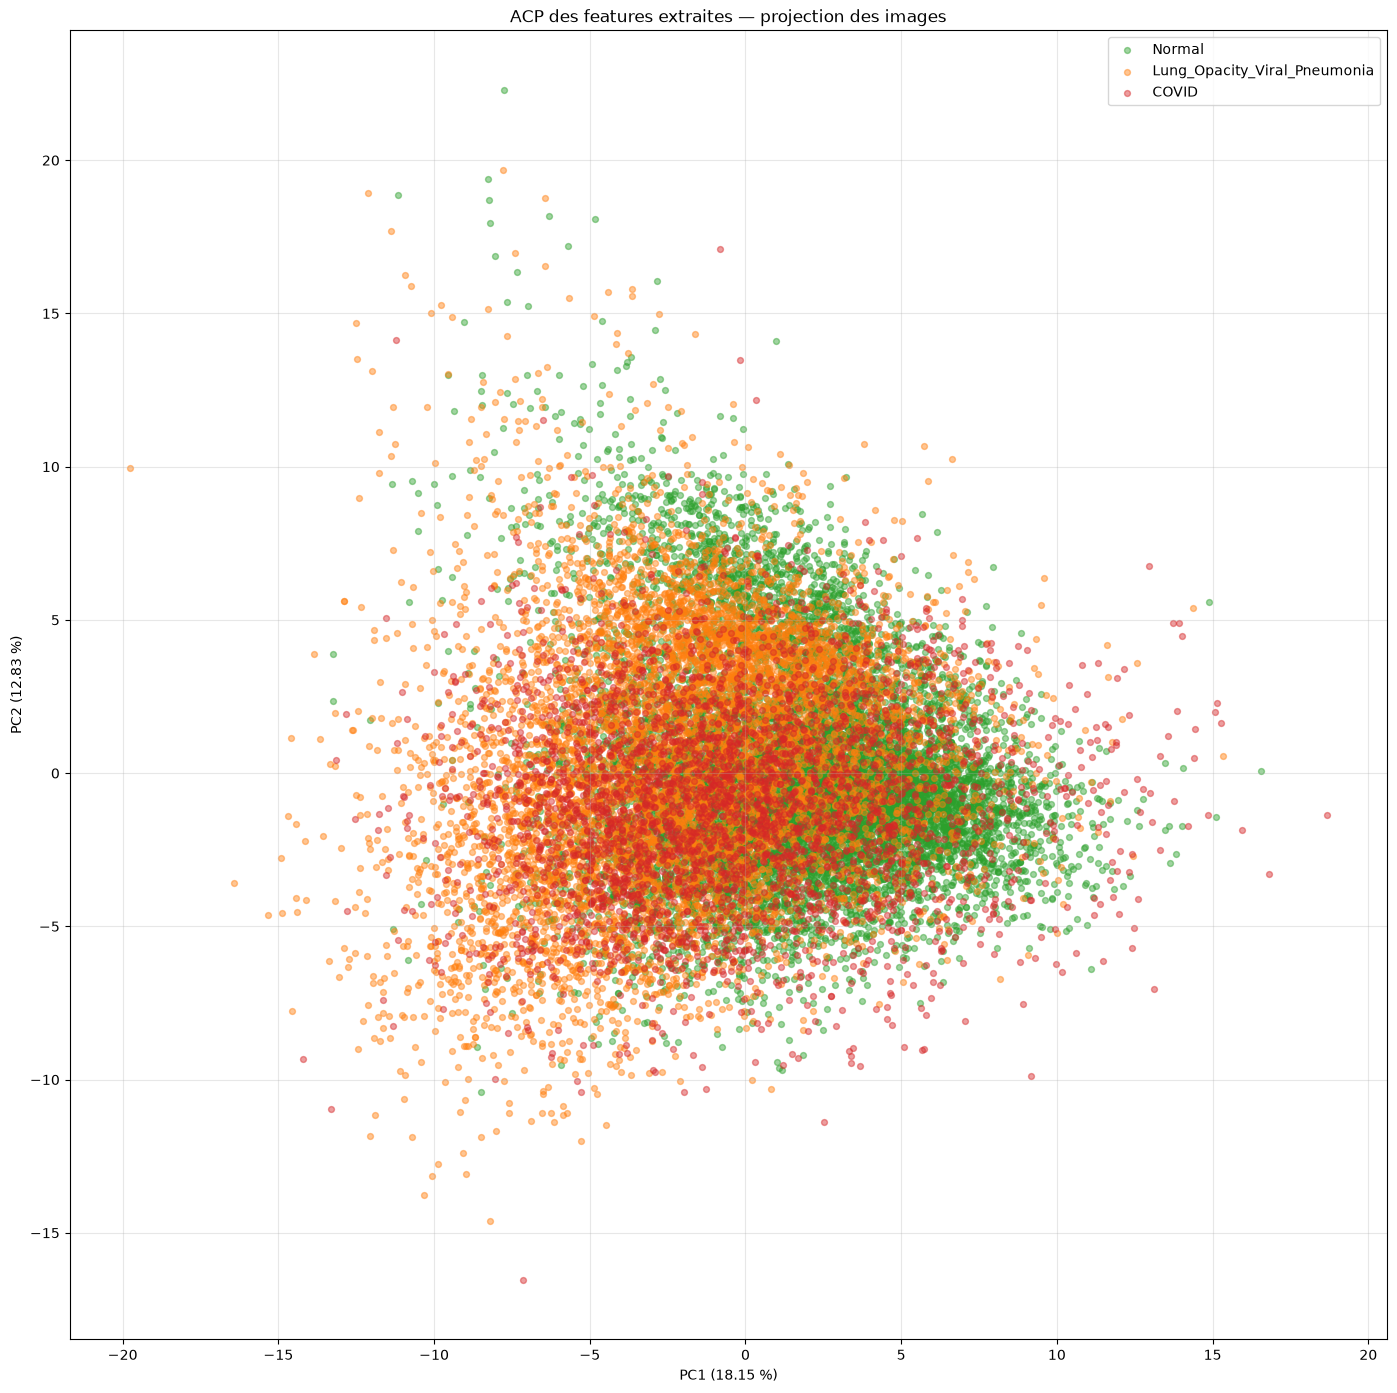

In [15]:
# ¨Projection des individus

colors = {
    "COVID": "#d62728",
    "Normal": "#2ca02c",
    "Lung_Opacity_Viral_Pneumonia": "#ff7f0e"
}

classes = ["Normal", "Lung_Opacity_Viral_Pneumonia", "COVID"]

plt.figure(figsize=(17, 17))

for class_name in classes:
    subset = df_pca[df_pca["classe"] == class_name]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=class_name,
        color=colors[class_name],
        alpha=0.45,
        s=18
    )

plt.title("ACP des features extraites — projection des images")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f} %)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f} %)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

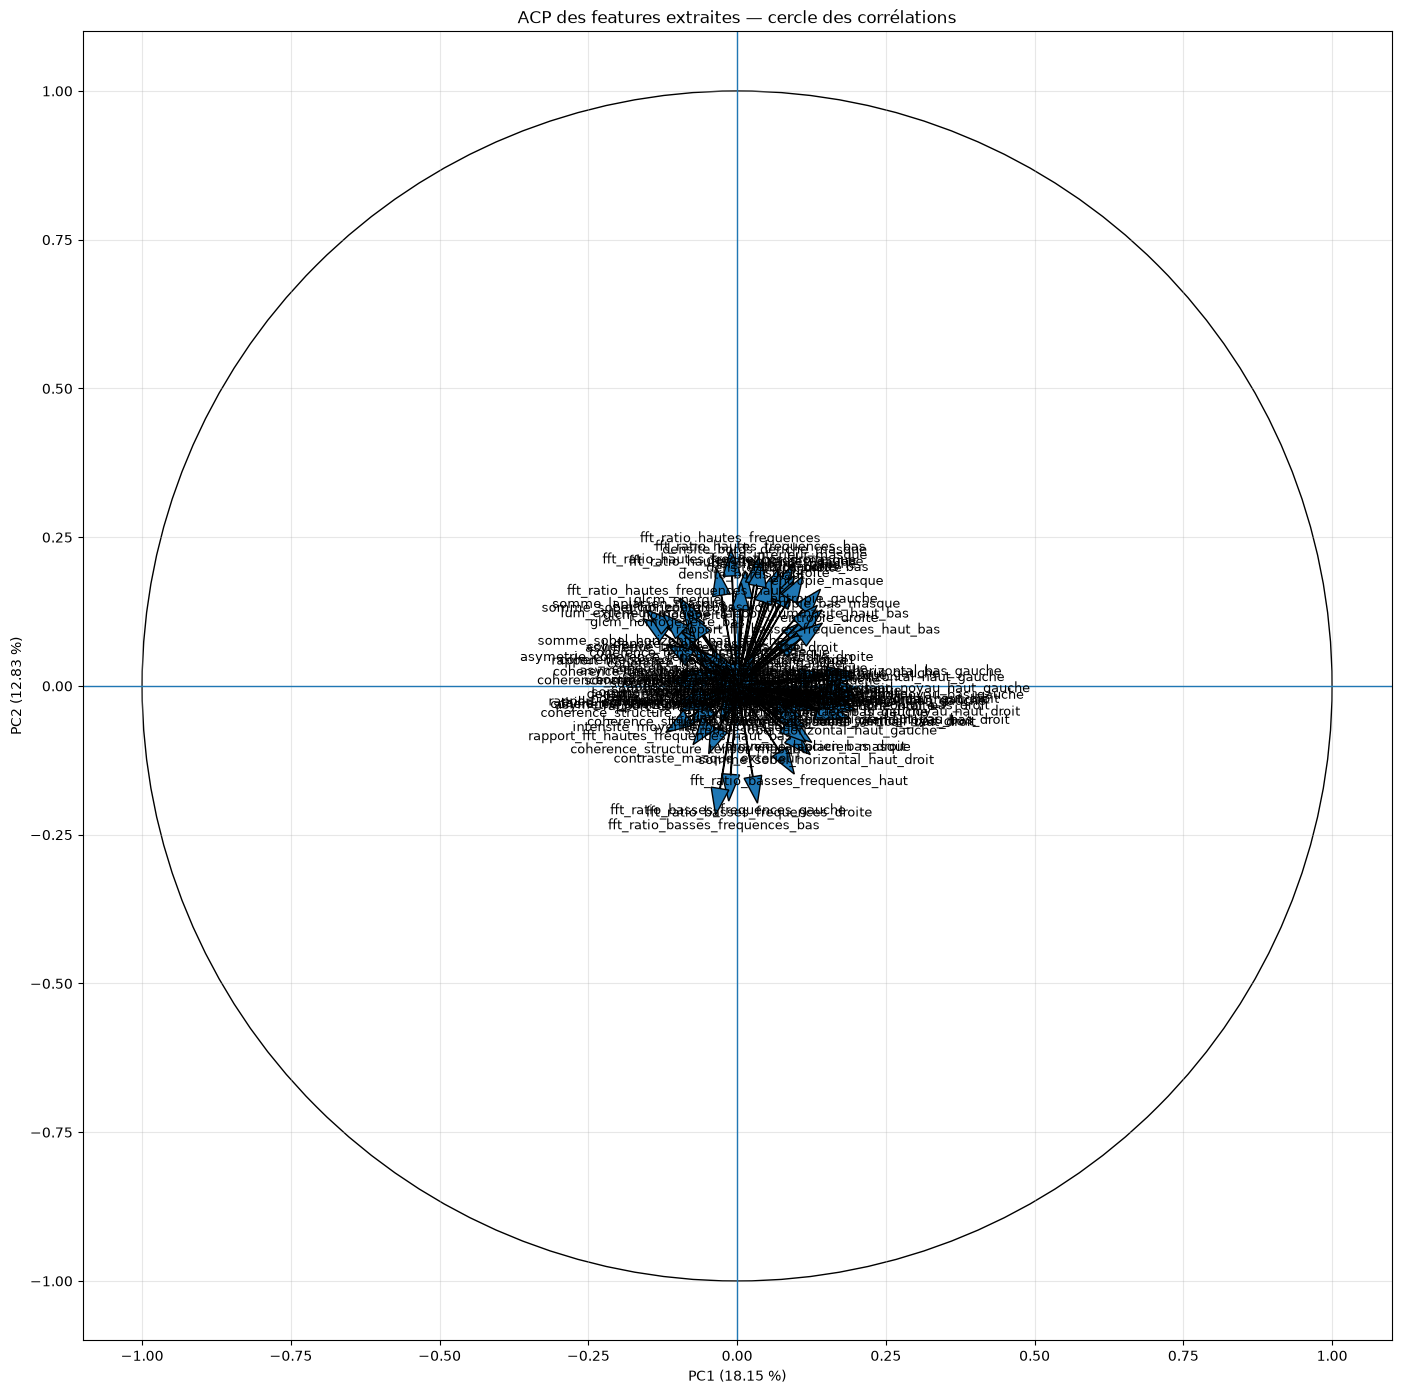

In [16]:
# vecteurs des variables

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features_cols
)

plt.figure(figsize=(17, 17))

# Cercle des corrélations
circle = plt.Circle((0, 0), 1, fill=False)
plt.gca().add_artist(circle)

for feature in features_cols:
    x = loadings.loc[feature, "PC1"]
    y_var = loadings.loc[feature, "PC2"]

    plt.arrow(
        0, 0,
        x, y_var,
        head_width=0.03,
        length_includes_head=True
    )

    plt.text(
        x * 1.08,
        y_var * 1.08,
        feature,
        ha="center",
        va="center",
        fontsize=9
    )

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f} %)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f} %)")

plt.title("ACP des features extraites — cercle des corrélations")
plt.grid(alpha=0.3)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

## Heatmap des corrélations

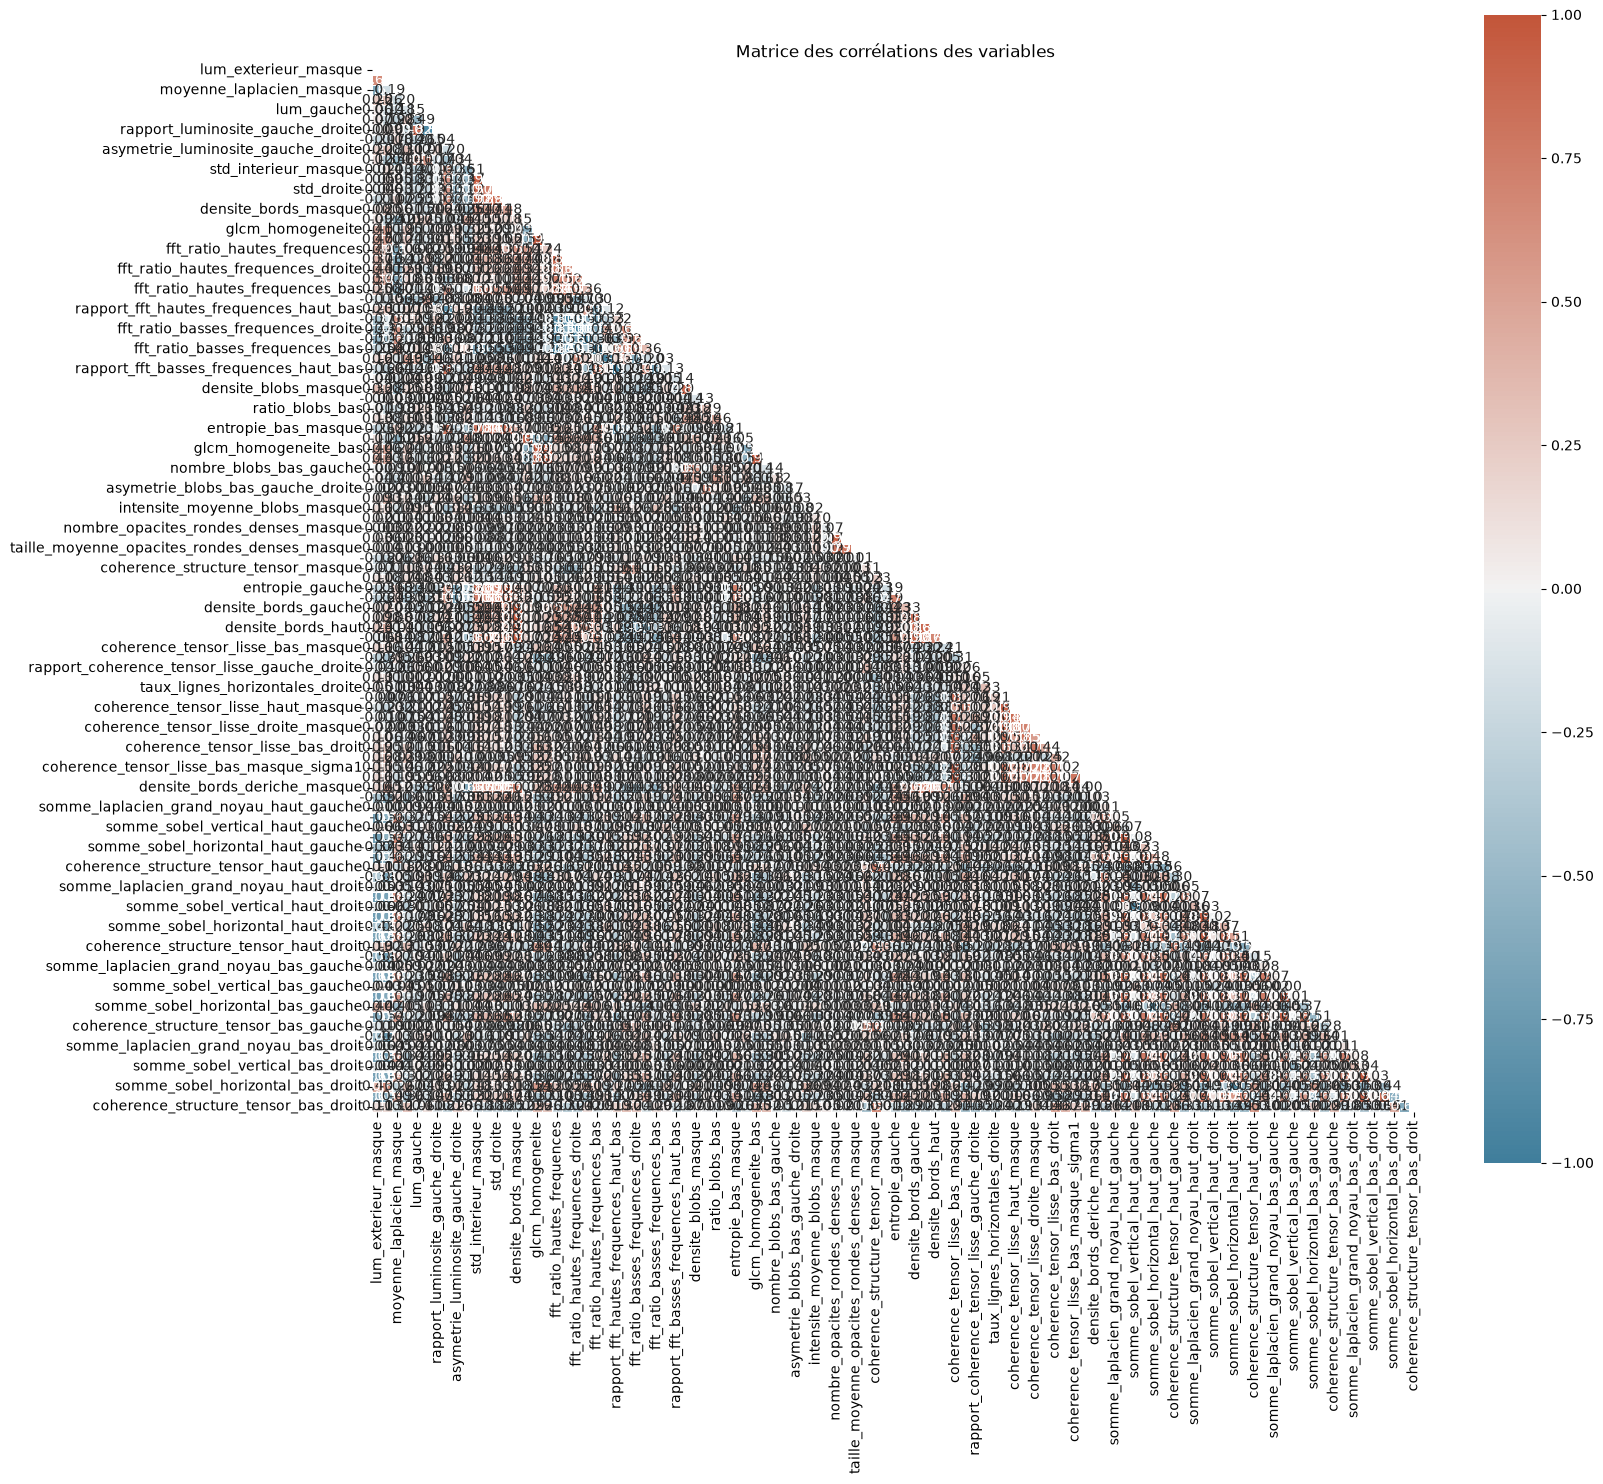

In [17]:
# Variables numériques
features_cols = [
    "lum_exterieur_masque",
    "somme_laplacien_masque",
    "moyenne_laplacien_masque",
    "asymetrie_flou_gauche_droite",
    "lum_gauche",
    "lum_droite",
    "rapport_luminosite_gauche_droite",
    "rapport_luminosite_haut_bas",
    "asymetrie_luminosite_gauche_droite",
    "contraste_masque_exterieur",
    "std_interieur_masque",
    "std_gauche",
    "std_droite",
    "entropie_masque",
    "densite_bords_masque",
    "glcm_contraste",
    "glcm_homogeneite",
    "glcm_energie",
    "fft_ratio_hautes_frequences",
    "fft_ratio_hautes_frequences_gauche",
    "fft_ratio_hautes_frequences_droite",
    "fft_ratio_hautes_frequences_haut",
    "fft_ratio_hautes_frequences_bas",
    "rapport_fft_hautes_frequences_gauche_droite",
    "rapport_fft_hautes_frequences_haut_bas",
    "fft_ratio_basses_frequences_gauche",
    "fft_ratio_basses_frequences_droite",
    "fft_ratio_basses_frequences_haut",
    "fft_ratio_basses_frequences_bas",
    "rapport_fft_basses_frequences_gauche_droite",
    "rapport_fft_basses_frequences_haut_bas",
    "nombre_blobs_masque",
    "densite_blobs_masque",
    "asymetrie_blobs_gauche_droite",
    "ratio_blobs_bas",
    "taille_moyenne_blobs_masque",
    "entropie_bas_masque",
    "glcm_contraste_bas",
    "glcm_homogeneite_bas",
    "glcm_energie_bas",
    "nombre_blobs_bas_gauche",
    "nombre_blobs_bas_droit",
    "asymetrie_blobs_bas_gauche_droite",
    "asymetrie_laplacien_bas_gauche_droit",
    "intensite_moyenne_blobs_masque",
    "contraste_contour_blobs_masque",
    "nombre_opacites_rondes_denses_masque",
    "densite_opacites_rondes_denses_masque",
    "taille_moyenne_opacites_rondes_denses_masque",
    "rapport_coherence_structure_tensor_gauche_droite",
    "coherence_structure_tensor_masque",
    "rapport_coherence_structure_tensor_haut_bas",
    "entropie_gauche",
    "entropie_droite",
    "densite_bords_gauche",
    "densite_bords_droite",
    "densite_bords_haut",
    "densite_bords_bas",
    "coherence_tensor_lisse_bas_masque",
    "rapport_coherence_tensor_lisse_haut_bas",
    "rapport_coherence_tensor_lisse_gauche_droite",
    "taux_lignes_horizontales_gauche",
    "taux_lignes_horizontales_droite",
    "coherence_tensor_lisse_masque",
    "coherence_tensor_lisse_haut_masque",
    "coherence_tensor_lisse_gauche_masque",
    "coherence_tensor_lisse_droite_masque",
    "coherence_tensor_lisse_bas_gauche",
    "coherence_tensor_lisse_bas_droit",
    "asymetrie_coherence_tensor_lisse_bas_gauche_droite",
    "coherence_tensor_lisse_bas_masque_sigma1",
    "coherence_tensor_lisse_bas_masque_sigma4",
    "densite_bords_deriche_masque",
    "variance_laplacien_haut_gauche",
    "somme_laplacien_grand_noyau_haut_gauche",
    "somme_abs_laplacien_grand_noyau_haut_gauche",
    "somme_sobel_vertical_haut_gauche",
    "somme_abs_sobel_vertical_haut_gauche",
    "somme_sobel_horizontal_haut_gauche",
    "somme_abs_sobel_horizontal_haut_gauche",
    "coherence_structure_tensor_haut_gauche",
    "variance_laplacien_haut_droit",
    "somme_laplacien_grand_noyau_haut_droit",
    "somme_abs_laplacien_grand_noyau_haut_droit",
    "somme_sobel_vertical_haut_droit",
    "somme_abs_sobel_vertical_haut_droit",
    "somme_sobel_horizontal_haut_droit",
    "somme_abs_sobel_horizontal_haut_droit",
    "coherence_structure_tensor_haut_droit",
    "variance_laplacien_bas_gauche",
    "somme_laplacien_grand_noyau_bas_gauche",
    "somme_abs_laplacien_grand_noyau_bas_gauche",
    "somme_sobel_vertical_bas_gauche",
    "somme_abs_sobel_vertical_bas_gauche",
    "somme_sobel_horizontal_bas_gauche",
    "somme_abs_sobel_horizontal_bas_gauche",
    "coherence_structure_tensor_bas_gauche",
    "variance_laplacien_bas_droit",
    "somme_laplacien_grand_noyau_bas_droit",
    "somme_abs_laplacien_grand_noyau_bas_droit",
    "somme_sobel_vertical_bas_droit",
    "somme_abs_sobel_vertical_bas_droit",
    "somme_sobel_horizontal_bas_droit",
    "somme_abs_sobel_horizontal_bas_droit",
    "coherence_structure_tensor_bas_droit",
]

# Matrice de corrélations
corr = df_all_features[features_cols].corr()

# Masque pour masquer la moitié supérieure
mask = np.triu(np.ones_like(corr, dtype=bool))

# Figure
plt.figure(figsize=(17, 17))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

plt.title("Matrice des corrélations des variables")
plt.tight_layout()
plt.show()

## Suppression des features trop corrélées (priorité au score ANOVA)

À partir de la matrice de corrélations ci-dessus, on repère les paires de variables fortement corrélées (seuil `threshold`). Contrairement à une suppression arbitraire (ordre des colonnes), le choix de la feature conservée dans chaque paire redondante est désormais **piloté par le score ANOVA (F-test)** de chaque feature pour distinguer COVID des autres classes, calculé sur le train uniquement.

Principe : les features sont traitées de la plus informative à la moins informative (score ANOVA décroissant). Une feature est retenue, sauf si elle est trop corrélée à une feature déjà retenue et plus informative qu'elle — dans ce cas, c'est elle qui est supprimée, jamais l'inverse. On garde donc systématiquement, dans chaque groupe de features redondantes, celle qui apporte le plus d'information pour la détection du COVID.

In [18]:
# Seuil de corrélation au-delà duquel deux features sont jugées redondantes
threshold = 0.90

# Features qu'on souhaite toujours conserver, même si elles dépassent le seuil de
# corrélation avec une autre feature (ex. ratios "basses fréquences", mathématiquement
# proches de leur équivalent "hautes fréquences" mais qu'on veut garder pour l'analyse)
features_a_conserver = [
    "rapport_fft_basses_frequences_gauche_droite",
    "rapport_fft_basses_frequences_haut_bas",
]

# --- Score ANOVA (F-test) de chaque feature pour distinguer COVID des autres classes ---
# Calculé sur le train uniquement, pour éviter toute fuite d'information vers
# validation/test. Ce score sert de critère de priorité : entre deux features trop
# corrélées, on garde celle qui apporte le plus d'information pour la détection du COVID.
df_train_anova = df_all_features[df_all_features["split"] == "train"]
y_train_anova = (df_train_anova["classe"] == "COVID").astype(int)

f_scores_toutes_features, _ = f_classif(df_train_anova[features_cols], y_train_anova)
anova_scores = pd.Series(f_scores_toutes_features, index=features_cols)

# On traite les features de la plus informative (score ANOVA) à la moins informative
ordre_priorite = anova_scores.sort_values(ascending=False).index.tolist()

corr_abs = df_all_features[features_cols].corr().abs()

# Sélection gloutonne : une feature est retenue, sauf si elle est trop corrélée
# (> threshold) avec une feature déjà retenue et plus informative qu'elle (score ANOVA
# plus élevé, donc traitée plus tôt dans ordre_priorite). Les features protégées sont
# toujours retenues, quel que soit leur score ANOVA.
features_cols_reduced = []
to_drop = []
raisons_suppression = {}

for col in ordre_priorite:
    if col in features_a_conserver:
        features_cols_reduced.append(col)
        continue

    feature_conflictuelle = None
    for deja_garde in features_cols_reduced:
        if corr_abs.loc[col, deja_garde] > threshold:
            feature_conflictuelle = deja_garde
            break

    if feature_conflictuelle is not None:
        to_drop.append(col)
        raisons_suppression[col] = feature_conflictuelle
    else:
        features_cols_reduced.append(col)

# Remis dans l'ordre d'origine de features_cols (plus pratique pour les heatmaps/graphiques suivants)
features_cols_reduced = [c for c in features_cols if c in features_cols_reduced]

print(f"{len(to_drop)} feature(s) supprimée(s) sur {len(features_cols)} (seuil = {threshold}) :")
for c in to_drop:
    mieux_classee = raisons_suppression[c]
    print(
        f"  - {c}  (ANOVA = {anova_scores[c]:.2f}) trop corrélée à {mieux_classee} "
        f"(ANOVA = {anova_scores[mieux_classee]:.2f}, mieux classée)"
    )

print(f"\n{len(features_cols_reduced)} feature(s) conservée(s), classées par score ANOVA décroissant :")
for c in ordre_priorite:
    if c in features_cols_reduced:
        print(f"  - {c}  (ANOVA = {anova_scores[c]:.2f})")

24 feature(s) supprimée(s) sur 105 (seuil = 0.9) :
  - coherence_tensor_lisse_masque  (ANOVA = 1451.66) trop corrélée à coherence_tensor_lisse_droite_masque (ANOVA = 1476.20, mieux classée)
  - coherence_tensor_lisse_bas_masque_sigma1  (ANOVA = 799.30) trop corrélée à coherence_tensor_lisse_bas_masque (ANOVA = 1034.71, mieux classée)
  - coherence_tensor_lisse_bas_masque_sigma4  (ANOVA = 719.60) trop corrélée à coherence_tensor_lisse_bas_masque (ANOVA = 1034.71, mieux classée)
  - densite_bords_bas  (ANOVA = 128.50) trop corrélée à densite_bords_masque (ANOVA = 131.36, mieux classée)
  - densite_bords_droite  (ANOVA = 125.11) trop corrélée à densite_bords_masque (ANOVA = 131.36, mieux classée)
  - densite_bords_gauche  (ANOVA = 113.85) trop corrélée à densite_bords_masque (ANOVA = 131.36, mieux classée)
  - densite_bords_haut  (ANOVA = 90.60) trop corrélée à densite_bords_masque (ANOVA = 131.36, mieux classée)
  - fft_ratio_hautes_frequences_bas  (ANOVA = 78.89) trop corrélée à fft_rat

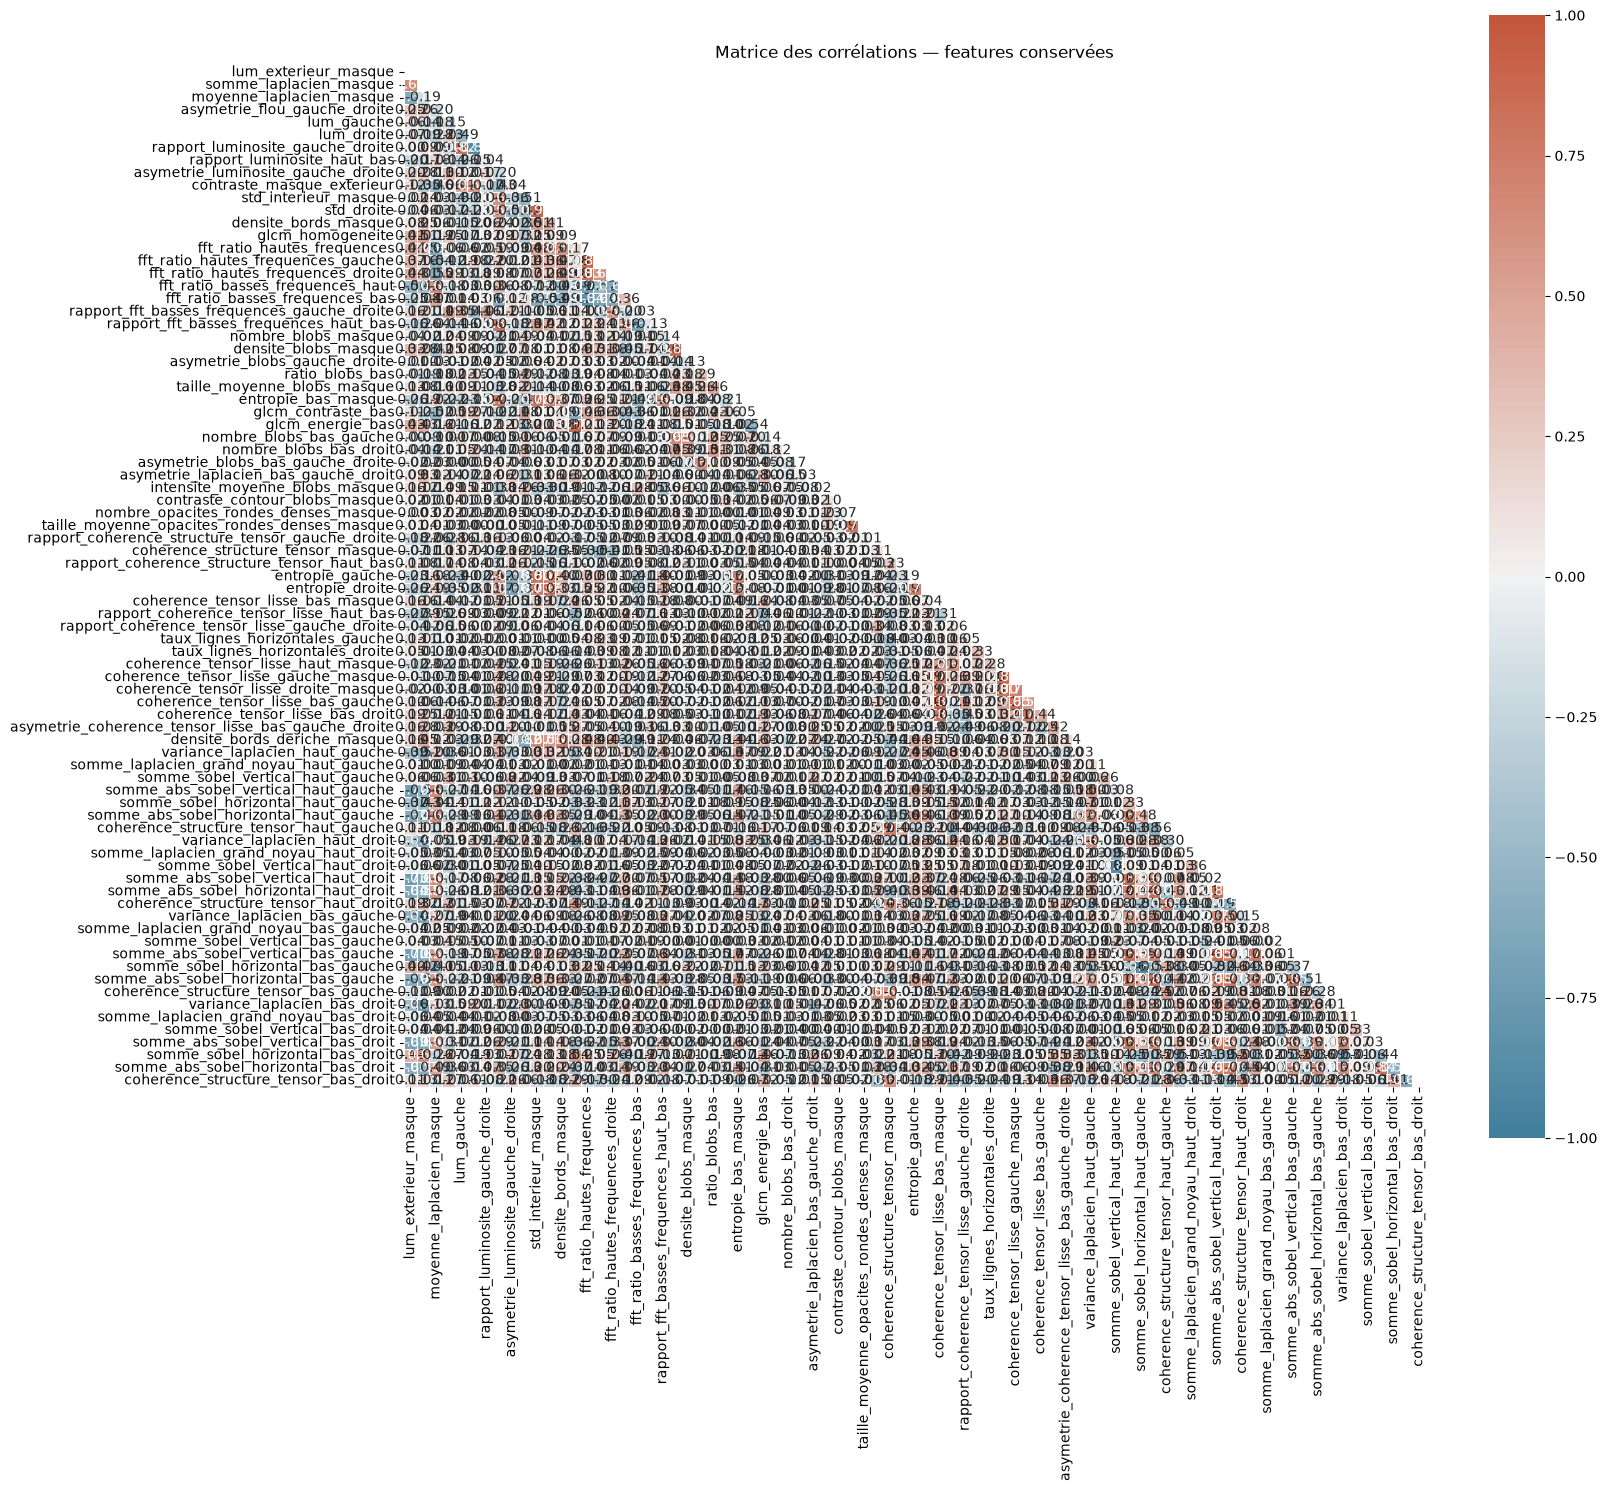

In [19]:
# Vérification : nouvelle matrice de corrélations sur les features conservées
corr_reduced = df_all_features[features_cols_reduced].corr()
mask_reduced = np.triu(np.ones_like(corr_reduced, dtype=bool))

plt.figure(figsize=(17, 17))
sns.heatmap(
    corr_reduced,
    mask=mask_reduced,
    cmap=sns.diverging_palette(230, 20, as_cmap=True),
    annot=True,
    fmt=".2f",
    vmin=-1, vmax=1, center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matrice des corrélations — features conservées")
plt.tight_layout()
plt.show()

## Essai : top 40 features par score ANOVA (COVID vs reste) + top 20 features par score ANOVA (Lung_Opacity_Viral_Pneumonia vs reste)

Sélection alternative, purement guidée par le score ANOVA calculé plus haut (`anova_scores`, sur `features_cols`, l'ensemble complet des features avant réduction par corrélation) : on garde les 40 features avec le score ANOVA le plus élevé pour distinguer COVID du reste, sans tenir compte de la redondance entre elles (contrairement à `features_cols_reduced`).

On y ajoute désormais les 20 features avec le score ANOVA le plus élevé pour distinguer la classe fusionnée **`Lung_Opacity_Viral_Pneumonia`** du reste (calculé de la même manière, sur `features_cols`, train uniquement). Les deux sélections sont fusionnées (union, sans doublons) : une feature déjà présente dans le top 40 COVID n'est pas comptée deux fois si elle apparaît aussi dans le top 20 Lung_Opacity_Viral_Pneumonia.

Objectif : comparer les performances d'un modèle entraîné sur ce sous-ensemble à celui entraîné sur `features_cols_reduced`.

Des CSV dédiés sont sauvegardés séparément (`*_features_top40_anova.csv`), sans écraser les CSV existants, pour pouvoir comparer les deux approches.

In [20]:
top_n_anova_covid = 40
features_cols_top40_anova = ordre_priorite[:top_n_anova_covid]

print(f"Top {top_n_anova_covid} features par score ANOVA (COVID vs reste) :")
for f in features_cols_top40_anova:
    print(f"  - {f}  (ANOVA COVID = {anova_scores[f]:.2f})")

# --- Score ANOVA (F-test) de chaque feature pour distinguer Lung_Opacity_Viral_Pneumonia des autres classes ---
# Même principe que pour COVID ci-dessus : calculé sur le train uniquement, sur
# features_cols (ensemble complet des features, avant réduction par corrélation).
# NOM_CLASSE_FUSIONNEE = classe issue de la fusion de Lung_Opacity et Viral Pneumonia
# (voir la cellule de fusion des classes plus haut).
y_train_anova_lung_opacity = (df_train_anova["classe"] == NOM_CLASSE_FUSIONNEE).astype(int)

f_scores_lung_opacity, _ = f_classif(df_train_anova[features_cols], y_train_anova_lung_opacity)
anova_scores_lung_opacity = pd.Series(f_scores_lung_opacity, index=features_cols)

ordre_priorite_lung_opacity = anova_scores_lung_opacity.sort_values(ascending=False).index.tolist()

top_n_anova_lung_opacity = 20
features_cols_top20_anova_lung_opacity = ordre_priorite_lung_opacity[:top_n_anova_lung_opacity]

print(f"\nTop {top_n_anova_lung_opacity} features par score ANOVA ({NOM_CLASSE_FUSIONNEE} vs reste) :")
for f in features_cols_top20_anova_lung_opacity:
    deja_dans_covid = " [déjà présente dans le top COVID]" if f in features_cols_top40_anova else ""
    print(f"  - {f}  (ANOVA {NOM_CLASSE_FUSIONNEE} = {anova_scores_lung_opacity[f]:.2f}){deja_dans_covid}")

# --- Fusion des deux sélections (union, sans doublons) ---
# On conserve l'ordre : d'abord le top 40 COVID, puis les features du top 20
# Lung_Opacity_Viral_Pneumonia qui n'y figurent pas déjà.
features_cols_top40_anova_plus_lung = features_cols_top40_anova + [
    f for f in features_cols_top20_anova_lung_opacity if f not in features_cols_top40_anova
]

print(
    f"\n{len(features_cols_top40_anova_plus_lung)} features conservées au total "
    f"(top {top_n_anova_covid} COVID + top {top_n_anova_lung_opacity} {NOM_CLASSE_FUSIONNEE}, "
    "après déduplication des features communes aux deux sélections)."
)

output_csv_top40_anova = {
    "train": output_dir / "train_features_top40_anova.csv",
    "validation": output_dir / "validation_features_top40_anova.csv",
    "test": output_dir / "test_features_top40_anova.csv",
}

cols_a_garder_top40 = ["filename", "classe"] + features_cols_top40_anova_plus_lung

for split_name, path_out in output_csv_top40_anova.items():
    df_split_top40 = df_all_features.loc[df_all_features["split"] == split_name, cols_a_garder_top40]
    df_split_top40.to_csv(path_out, index=False)
    print(f"CSV enregistré : {path_out}  ({df_split_top40.shape[0]} lignes, {df_split_top40.shape[1]} colonnes)")

Top 40 features par score ANOVA (COVID vs reste) :
  - coherence_tensor_lisse_droite_masque  (ANOVA COVID = 1476.20)
  - coherence_tensor_lisse_masque  (ANOVA COVID = 1451.66)
  - coherence_tensor_lisse_haut_masque  (ANOVA COVID = 1112.45)
  - coherence_tensor_lisse_gauche_masque  (ANOVA COVID = 1063.11)
  - coherence_tensor_lisse_bas_masque  (ANOVA COVID = 1034.71)
  - coherence_tensor_lisse_bas_droit  (ANOVA COVID = 887.60)
  - coherence_structure_tensor_haut_gauche  (ANOVA COVID = 854.90)
  - coherence_tensor_lisse_bas_masque_sigma1  (ANOVA COVID = 799.30)
  - coherence_tensor_lisse_bas_masque_sigma4  (ANOVA COVID = 719.60)
  - coherence_structure_tensor_masque  (ANOVA COVID = 653.81)
  - densite_bords_deriche_masque  (ANOVA COVID = 607.13)
  - coherence_tensor_lisse_bas_gauche  (ANOVA COVID = 589.03)
  - coherence_structure_tensor_haut_droit  (ANOVA COVID = 379.19)
  - somme_abs_sobel_horizontal_haut_gauche  (ANOVA COVID = 217.44)
  - coherence_structure_tensor_bas_gauche  (ANOVA C

## ACP et cercle des corrélations — features non redondantes

On refait l'ACP et le cercle des corrélations, cette fois uniquement sur `features_cols_reduced` (les features non éliminées par le seuil de corrélation), pour visualiser comment ces features restantes se répartissent dans le plan factoriel une fois la redondance retirée.

In [21]:
# ACP sur les features non redondantes
X_reduced = df_all_features[features_cols_reduced]

scaler_reduced = StandardScaler()
X_scaled_reduced = scaler_reduced.fit_transform(X_reduced)

pca_reduced = PCA(n_components=2)
X_pca_reduced = pca_reduced.fit_transform(X_scaled_reduced)

df_pca_reduced = pd.DataFrame({
    "PC1": X_pca_reduced[:, 0],
    "PC2": X_pca_reduced[:, 1],
    "classe": y,
    "split": df_all_features["split"]
})

print("Variance expliquée PC1 :", round(pca_reduced.explained_variance_ratio_[0] * 100, 2), "%")
print("Variance expliquée PC2 :", round(pca_reduced.explained_variance_ratio_[1] * 100, 2), "%")
print("Variance expliquée totale :", round(pca_reduced.explained_variance_ratio_[:2].sum() * 100, 2), "%")

Variance expliquée PC1 : 17.18 %
Variance expliquée PC2 : 10.39 %
Variance expliquée totale : 27.57 %


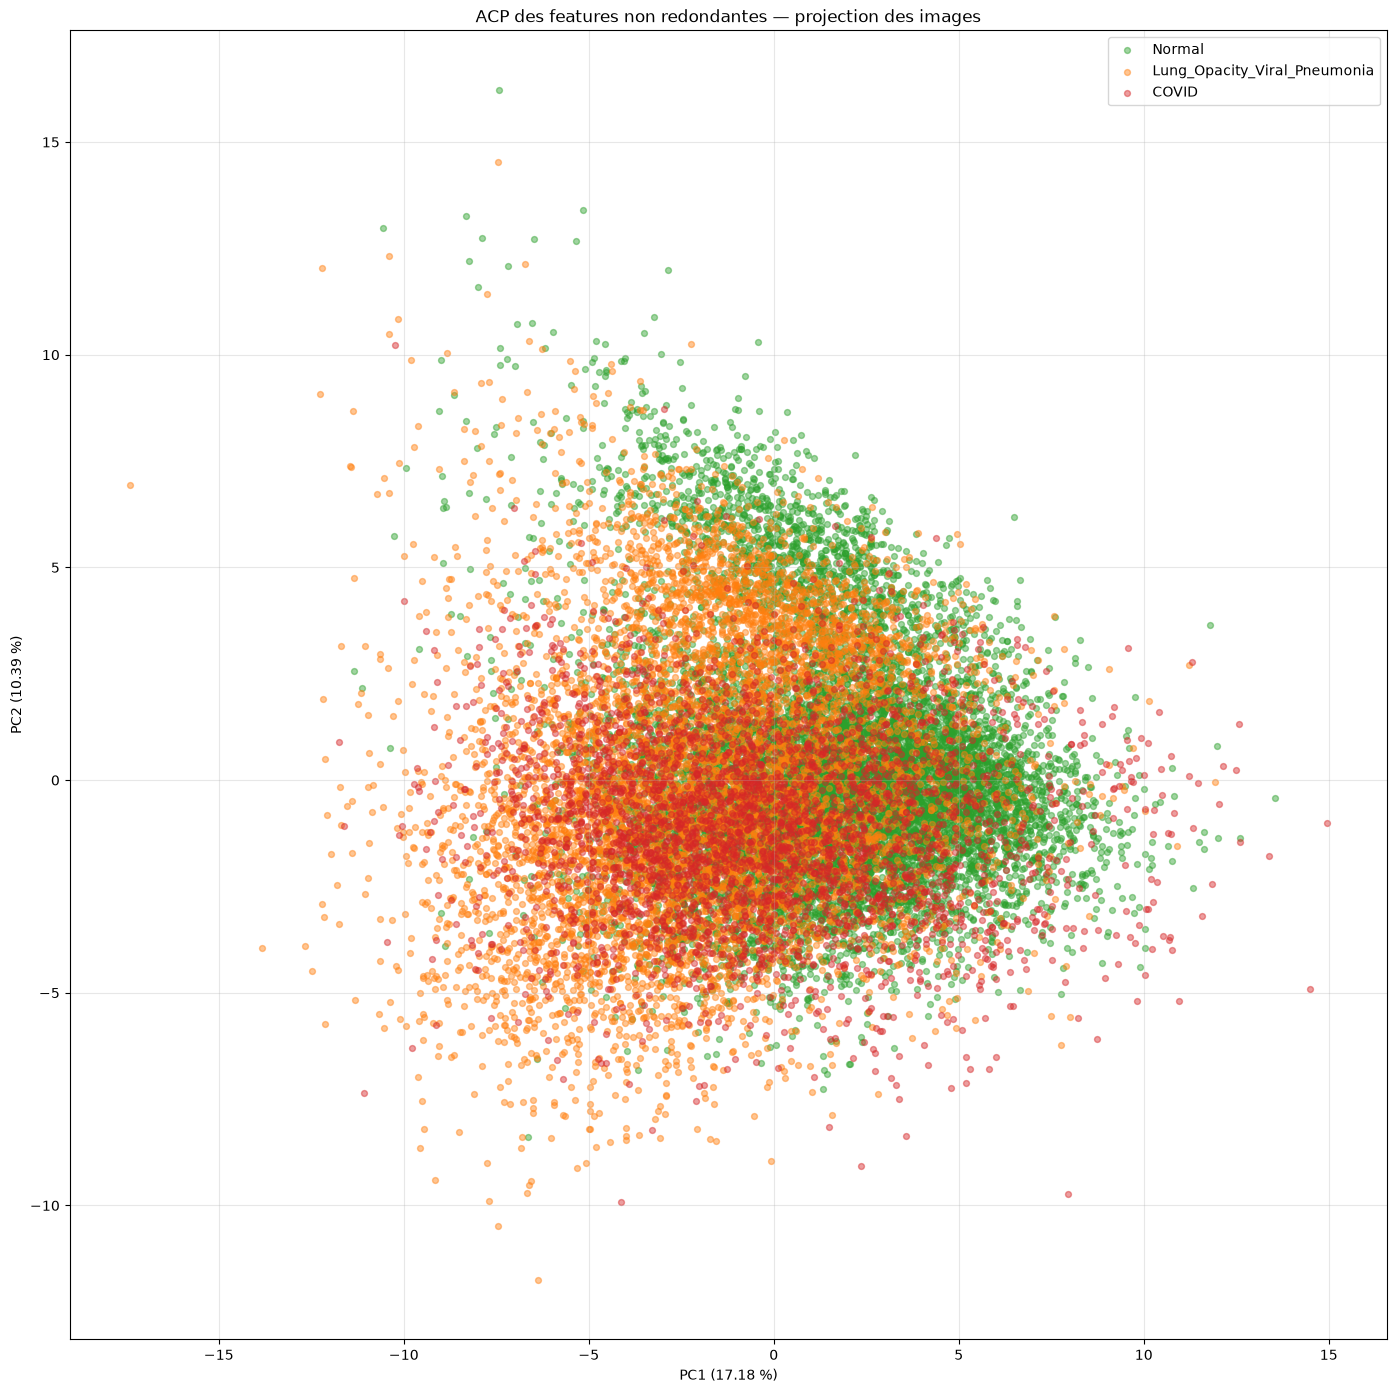

In [22]:
# Projection des individus (features non redondantes)

plt.figure(figsize=(17, 17))

for class_name in classes:
    subset = df_pca_reduced[df_pca_reduced["classe"] == class_name]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=class_name,
        color=colors[class_name],
        alpha=0.45,
        s=18
    )

plt.title("ACP des features non redondantes — projection des images")
plt.xlabel(f"PC1 ({pca_reduced.explained_variance_ratio_[0]*100:.2f} %)")
plt.ylabel(f"PC2 ({pca_reduced.explained_variance_ratio_[1]*100:.2f} %)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

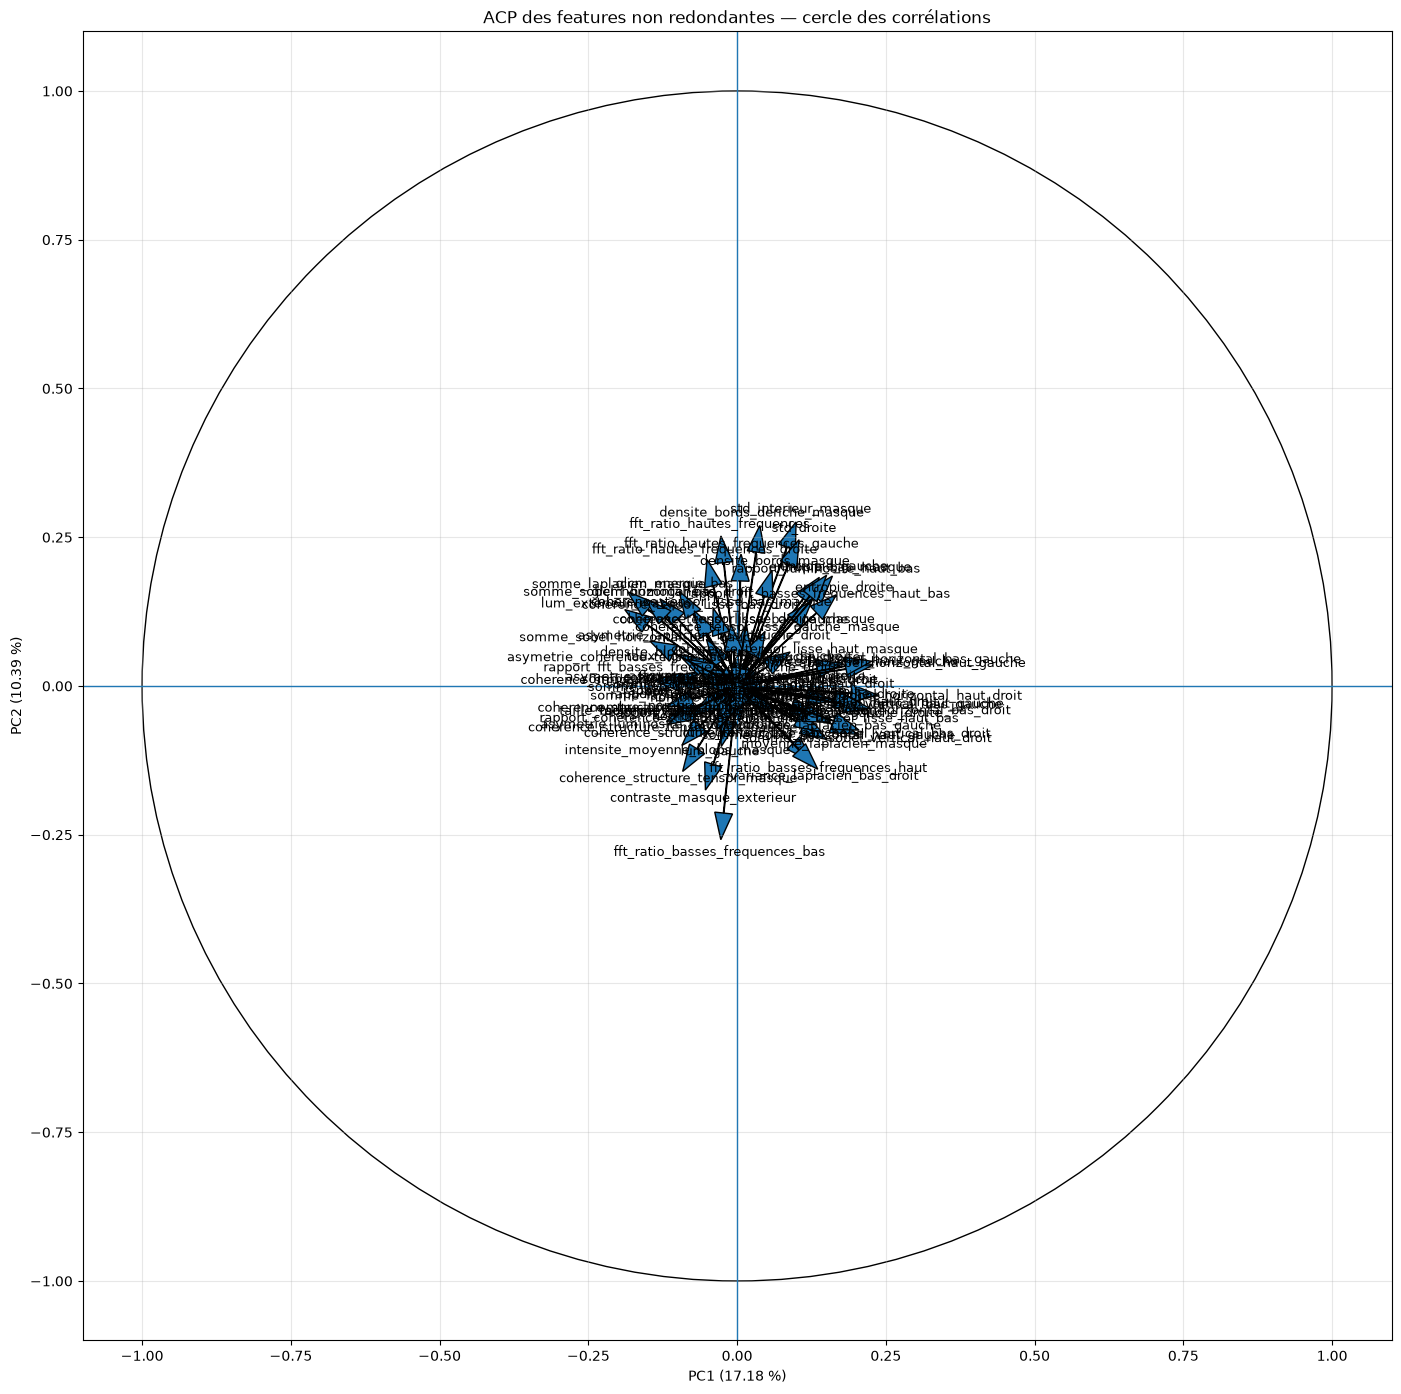

In [23]:
# Cercle des corrélations (features non redondantes)

loadings_reduced = pd.DataFrame(
    pca_reduced.components_.T,
    columns=["PC1", "PC2"],
    index=features_cols_reduced
)

plt.figure(figsize=(17, 17))

circle = plt.Circle((0, 0), 1, fill=False)
plt.gca().add_artist(circle)

for feature in features_cols_reduced:
    x = loadings_reduced.loc[feature, "PC1"]
    y_var = loadings_reduced.loc[feature, "PC2"]

    plt.arrow(
        0, 0,
        x, y_var,
        head_width=0.03,
        length_includes_head=True
    )

    plt.text(
        x * 1.08,
        y_var * 1.08,
        feature,
        ha="center",
        va="center",
        fontsize=9
    )

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

plt.xlabel(f"PC1 ({pca_reduced.explained_variance_ratio_[0]*100:.2f} %)")
plt.ylabel(f"PC2 ({pca_reduced.explained_variance_ratio_[1]*100:.2f} %)")

plt.title("ACP des features non redondantes — cercle des corrélations")
plt.grid(alpha=0.3)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

## Sélection de features orientée détection du COVID (affinage)

L'ANOVA a déjà servi de critère de priorité pour départager les features corrélées ci-dessus (`features_cols_reduced` favorise donc déjà les features utiles à la détection du COVID). On affine maintenant ce classement au sein de `features_cols_reduced`, en ajoutant deux critères complémentaires à l'ANOVA, **sur le train uniquement** (pour éviter toute fuite d'information vers validation/test) :
- **ANOVA F-score** (`f_classif`) : rappelé pour référence (déjà utilisé plus haut).
- **Information mutuelle** (`mutual_info_classif`) : capture aussi les relations non linéaires et non monotones, que l'ANOVA (test linéaire) peut manquer.
- **Importance Random Forest** : tient compte des interactions entre features, contrairement aux deux critères précédents qui évaluent chaque feature isolément.

Les trois critères sont combinés par un **rang moyen** (plutôt qu'une moyenne de scores bruts, aux échelles très différentes) : pour chaque critère, la feature la plus utile reçoit le rang 1, puis on moyenne les 3 rangs par feature.

In [24]:
# Cible binaire COVID vs autres classes, calculée sur le train uniquement
df_train = df_all_features[df_all_features["split"] == "train"]

X_train_covid = df_train[features_cols_reduced]
y_train_covid = (df_train["classe"] == "COVID").astype(int)

f_scores, _ = f_classif(X_train_covid, y_train_covid)
mi_scores = mutual_info_classif(X_train_covid, y_train_covid, random_state=42)

rf_covid = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
rf_covid.fit(X_train_covid, y_train_covid)
rf_importances = rf_covid.feature_importances_

df_scores_covid = pd.DataFrame({
    "feature": features_cols_reduced,
    "anova_f": f_scores,
    "information_mutuelle": mi_scores,
    "importance_random_forest": rf_importances,
})

# Rang par critère (1 = feature la plus utile), puis rang moyen
for col in ["anova_f", "information_mutuelle", "importance_random_forest"]:
    df_scores_covid[col + "_rang"] = df_scores_covid[col].rank(ascending=False)

df_scores_covid["rang_moyen"] = df_scores_covid[
    ["anova_f_rang", "information_mutuelle_rang", "importance_random_forest_rang"]
].mean(axis=1)

df_scores_covid = df_scores_covid.sort_values("rang_moyen").reset_index(drop=True)

df_scores_covid[["feature", "anova_f", "information_mutuelle", "importance_random_forest", "rang_moyen"]]

,feature,anova_f,information_mutuelle,importance_random_forest,rang_moyen
0,coherence_tensor_lisse_droite_masque,1476.201438,0.047232,0.048206,1.000000
1,coherence_tensor_lisse_haut_masque,1112.449496,0.030940,0.035123,3.333333
2,coherence_tensor_lisse_bas_masque,1034.708885,0.032407,0.029018,4.333333
3,coherence_tensor_lisse_gauche_masque,1063.107163,0.030009,0.030881,4.666667
4,coherence_structure_tensor_haut_gauche,854.904006,0.028568,0.036481,5.000000
...,...,...,...,...,...
76,nombre_opacites_rondes_denses_masque,8.614453,0.000000,0.000309,70.166667
77,asymetrie_blobs_gauche_droite,0.431012,0.000619,0.001363,72.333333
78,asymetrie_blobs_bas_gauche_droite,1.093337,0.000000,0.001482,73.833333
79,nombre_blobs_masque,0.075066,0.000000,0.002488,75.500000


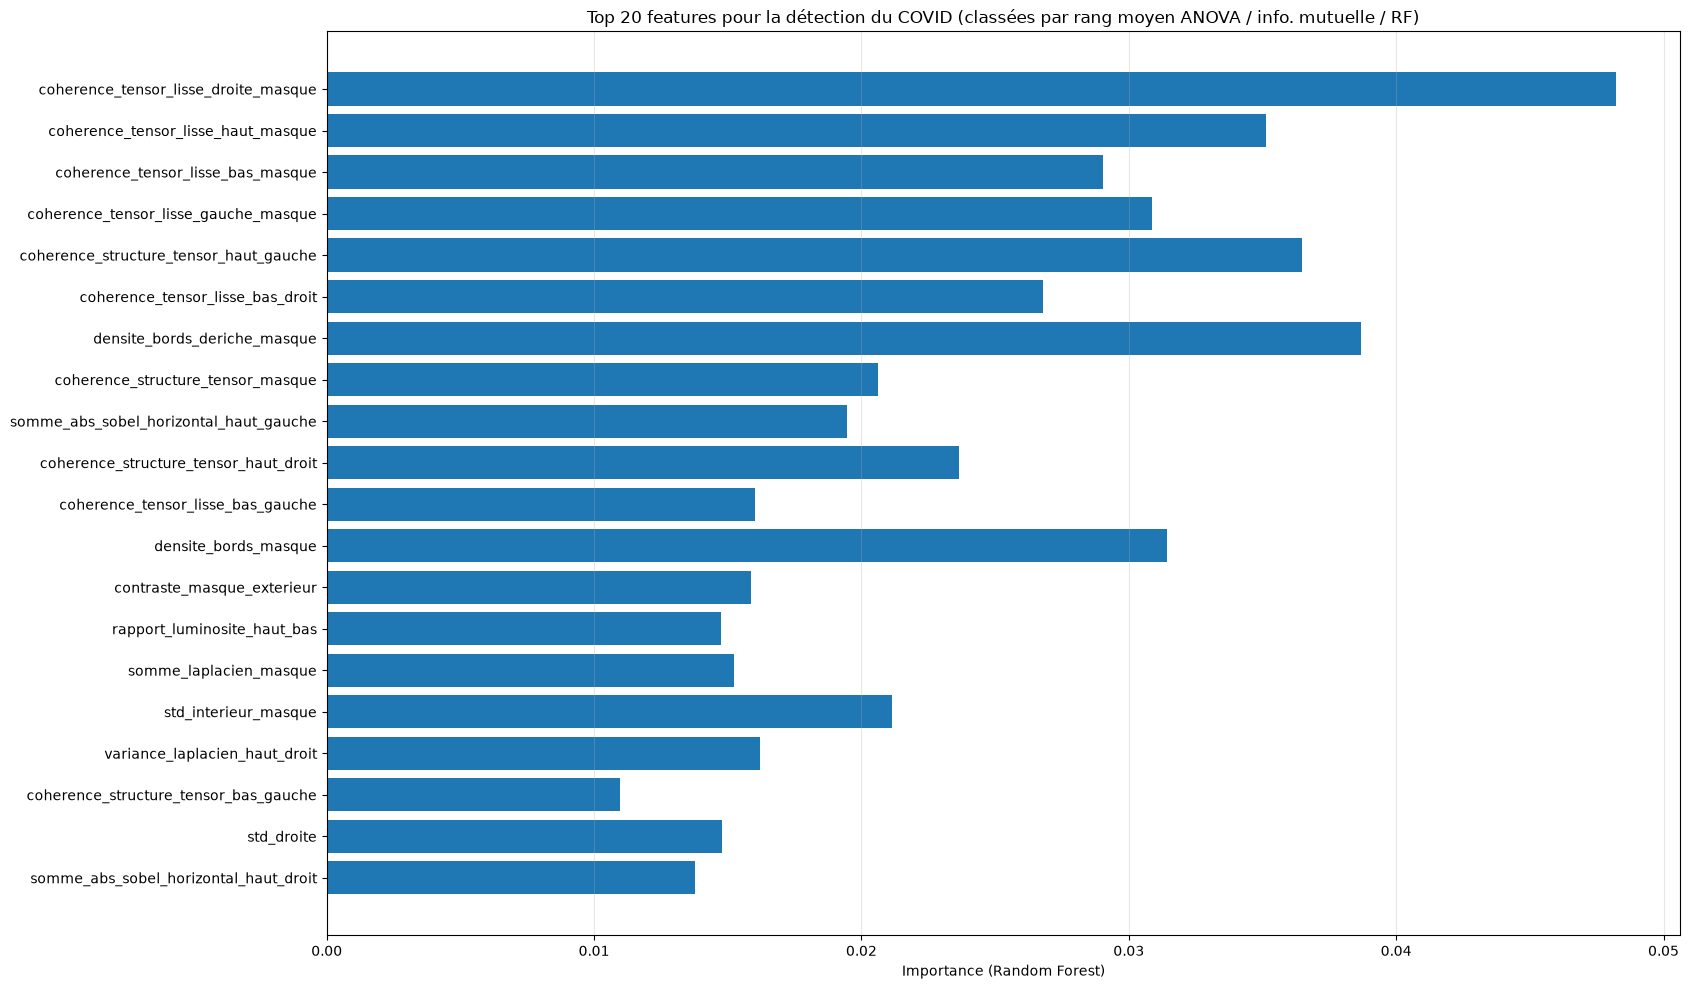

20 features retenues pour la détection du COVID :
 - coherence_tensor_lisse_droite_masque
 - coherence_tensor_lisse_haut_masque
 - coherence_tensor_lisse_bas_masque
 - coherence_tensor_lisse_gauche_masque
 - coherence_structure_tensor_haut_gauche
 - coherence_tensor_lisse_bas_droit
 - densite_bords_deriche_masque
 - coherence_structure_tensor_masque
 - somme_abs_sobel_horizontal_haut_gauche
 - coherence_structure_tensor_haut_droit
 - coherence_tensor_lisse_bas_gauche
 - densite_bords_masque
 - contraste_masque_exterieur
 - rapport_luminosite_haut_bas
 - somme_laplacien_masque
 - std_interieur_masque
 - variance_laplacien_haut_droit
 - coherence_structure_tensor_bas_gauche
 - std_droite
 - somme_abs_sobel_horizontal_haut_droit


In [25]:
# Top N features les plus utiles pour distinguer COVID des autres classes
top_n = 20
df_top_covid = df_scores_covid.head(top_n)

plt.figure(figsize=(17, 10))
plt.barh(df_top_covid["feature"][::-1], df_top_covid["importance_random_forest"][::-1])
plt.xlabel("Importance (Random Forest)")
plt.title(f"Top {top_n} features pour la détection du COVID (classées par rang moyen ANOVA / info. mutuelle / RF)")
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

# Liste des features retenues (à affiner selon vos besoins)
features_cols_covid = df_scores_covid["feature"].head(top_n).tolist()

print(f"{len(features_cols_covid)} features retenues pour la détection du COVID :")
for f in features_cols_covid:
    print(" -", f)

## Score ANOVA par classe (COVID, Normal, Lung_Opacity_Viral_Pneumonia)

Jusqu'ici, l'ANOVA n'a été calculée qu'en COVID vs reste. On la recalcule ici séparément pour **chacune des 3 classes** (one-vs-rest), sur `features_cols_reduced` et sur le train uniquement, pour voir si les features qui aident à détecter COVID sont aussi utiles pour les autres classes, ou si certaines features sont spécifiques à une seule pathologie.

In [26]:
df_train_multiclasse = df_all_features[df_all_features["split"] == "train"]

anova_multiclasse = pd.DataFrame(index=features_cols_reduced)

for classe_cible in classes:
    y_classe = (df_train_multiclasse["classe"] == classe_cible).astype(int)
    f_scores_classe, _ = f_classif(df_train_multiclasse[features_cols_reduced], y_classe)
    anova_multiclasse[classe_cible] = f_scores_classe

anova_multiclasse["score_moyen"] = anova_multiclasse[classes].mean(axis=1)
anova_multiclasse = anova_multiclasse.sort_values("score_moyen", ascending=False)

anova_multiclasse

,Normal,Lung_Opacity_Viral_Pneumonia,COVID,score_moyen
coherence_tensor_lisse_haut_masque,6245.869947,2381.240089,1112.449496,3246.519844
somme_laplacien_masque,3299.847863,5168.047501,104.717901,2857.537755
coherence_tensor_lisse_gauche_masque,4764.776710,1705.470687,1063.107163,2511.118187
variance_laplacien_haut_droit,2266.827948,3636.513904,104.916667,2002.752839
asymetrie_luminosite_gauche_droite,2649.532431,2991.508971,0.162862,1880.401421
...,...,...,...,...
lum_gauche,0.283348,8.864994,21.012403,10.053582
contraste_contour_blobs_masque,1.920085,0.053299,4.751623,2.241669
asymetrie_blobs_gauche_droite,0.600774,1.736707,0.431012,0.922831
asymetrie_blobs_bas_gauche_droite,0.242452,0.084767,1.093337,0.473519


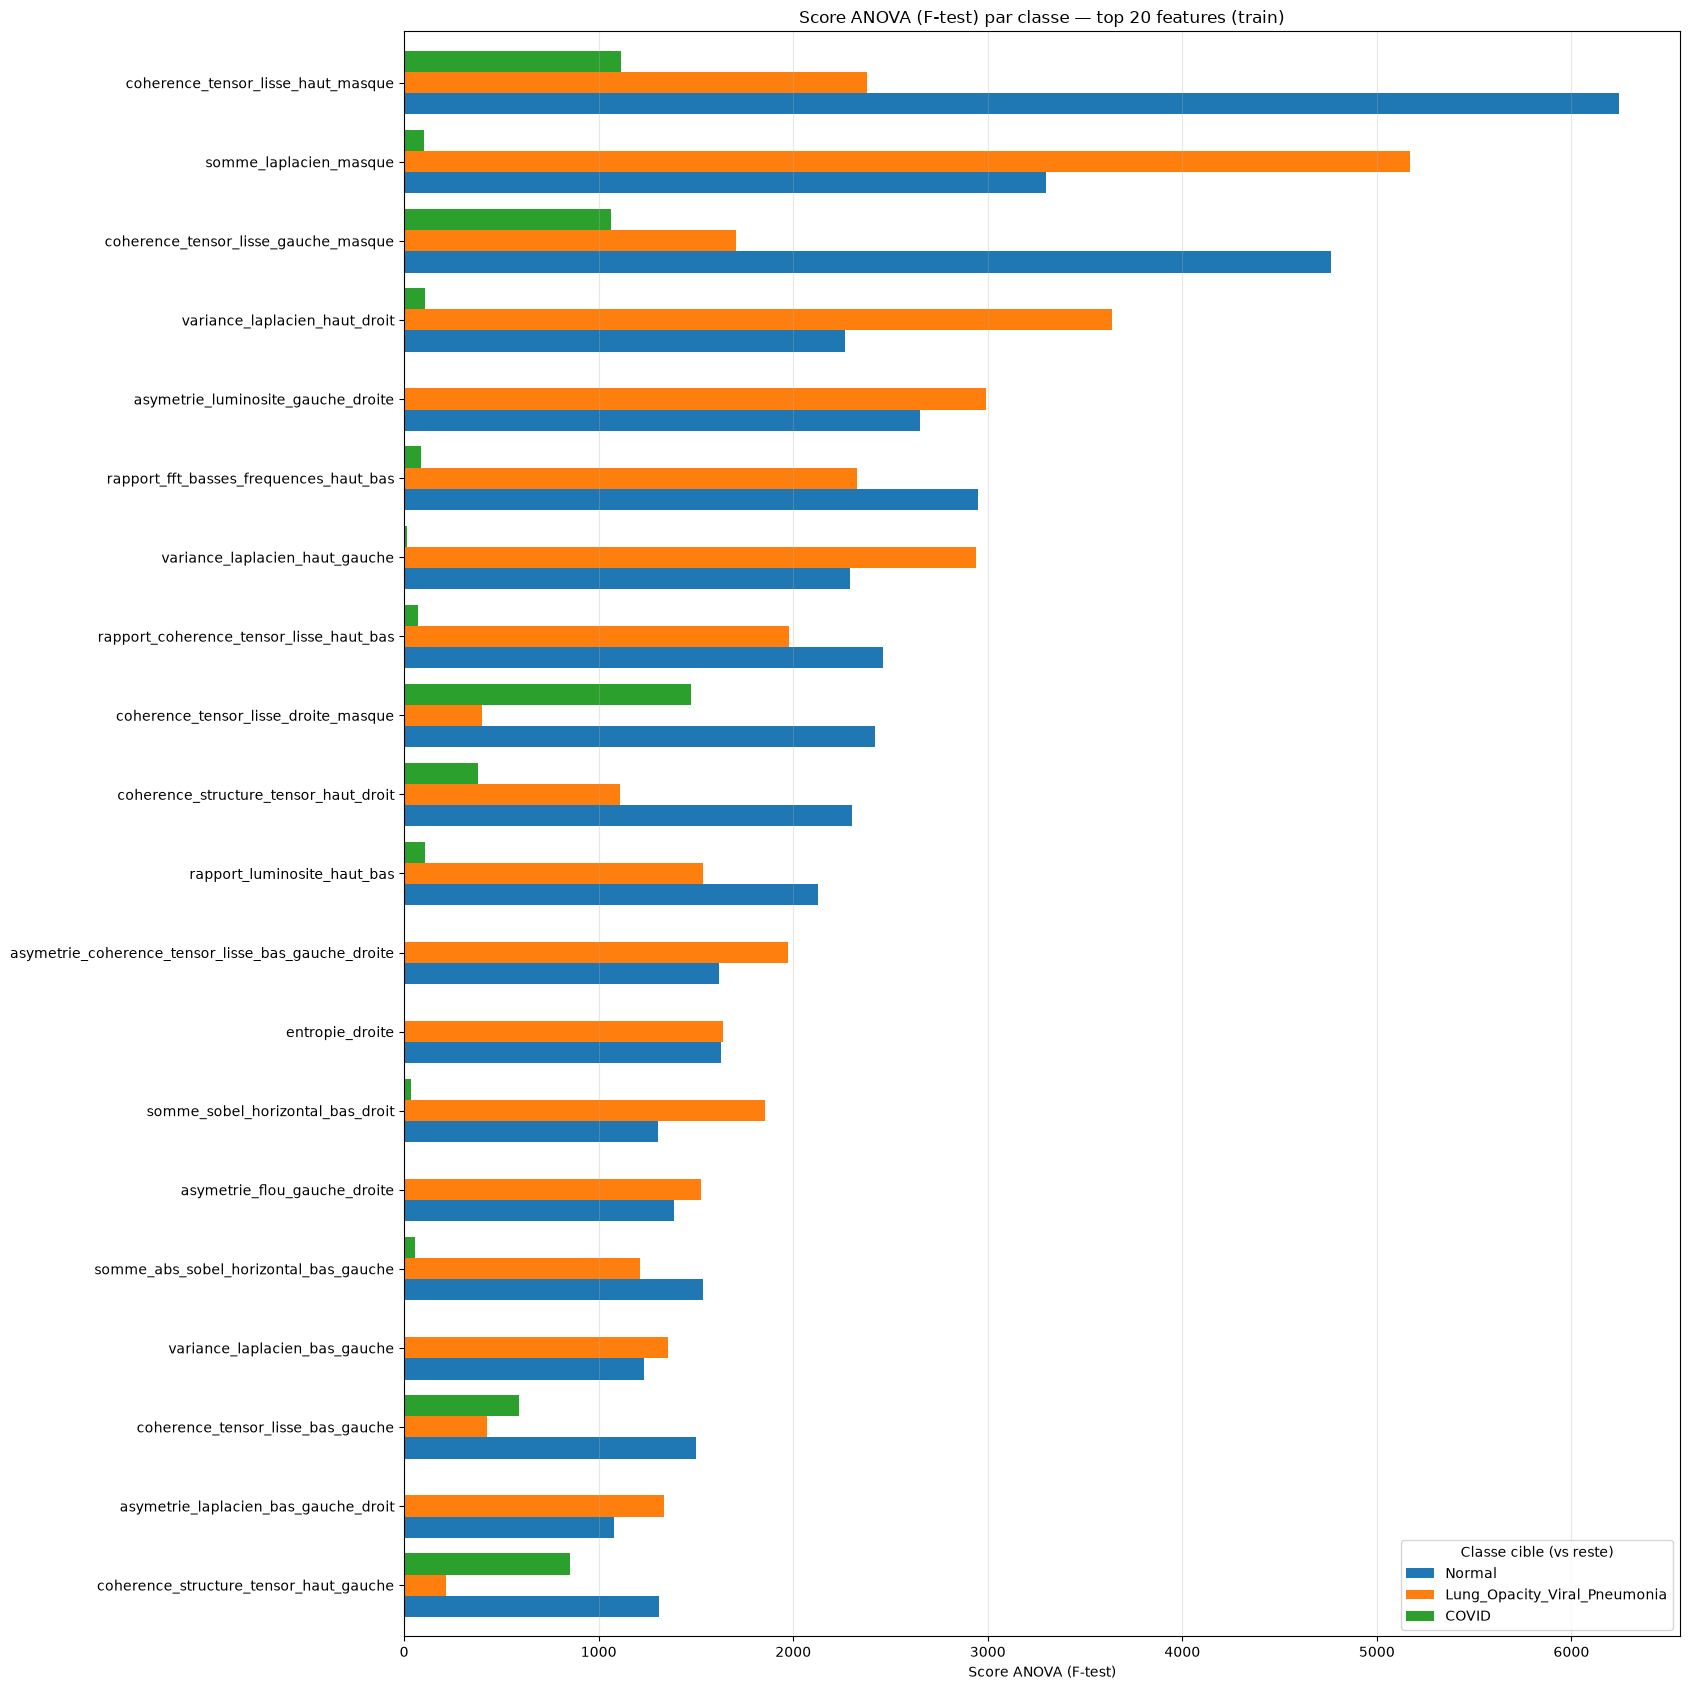

In [27]:
top_n_multiclasse = 20
anova_top_multiclasse = anova_multiclasse[classes].head(top_n_multiclasse)

anova_top_multiclasse.iloc[::-1].plot(kind="barh", figsize=(17, 17), width=0.8)
plt.xlabel("Score ANOVA (F-test)")
plt.title(f"Score ANOVA (F-test) par classe — top {top_n_multiclasse} features (train)")
plt.legend(title="Classe cible (vs reste)")
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## Sauvegarde des CSV avec les features non redondantes

On réécrit ici `train_features.csv`, `validation_features.csv` et `test_features.csv` (mêmes chemins que `output_csv`), en ne conservant que `filename`, `classe` et les colonnes de `features_cols_reduced` (features non redondantes selon le seuil de corrélation défini plus haut). Les fichiers d'origine (avec toutes les features) sont donc écrasés.

In [28]:
# Écrase les CSV d'origine : on ne garde que les features non corrélées (features_cols_reduced)
cols_to_keep = ["filename", "classe"] + features_cols_reduced

for split_name, path_out in output_csv.items():
    df_split_reduced = df_all_features.loc[df_all_features["split"] == split_name, cols_to_keep]
    df_split_reduced.to_csv(path_out, index=False)
    print(f"CSV écrasé : {path_out}  ({df_split_reduced.shape[0]} lignes, {df_split_reduced.shape[1]} colonnes)")

CSV écrasé : ../../../enhanced40_plusOpacity_features_3_classes/train_features.csv  (16668 lignes, 83 colonnes)
CSV écrasé : ../../../enhanced40_plusOpacity_features_3_classes/validation_features.csv  (2083 lignes, 83 colonnes)
CSV écrasé : ../../../enhanced40_plusOpacity_features_3_classes/test_features.csv  (2084 lignes, 83 colonnes)
